**LIESSE Nathan & SALIOU Yves-Marie**

**Github** : https://github.com/yvesmarix/PROJET-QRT-ELEC/tree/main

# Table des matières


# 1) Sujet

Le sujet provient de QRT et se nomme : "Comment expliquer le prix de l'électricité ? "

## 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

## 1.2) Description des données

**Variables explicatives**:
Les données d'entrée possèdent 35 colonnes :

- ID : Identifiant d'indexe unique, associé à un jour (DAY_ID) et un pays (COUNTRY),
- DAY_ID : Identifiant du jour - les dates ont été annonymisées en préservant la structure des données,
- COUNTRY : Identifiant du pays - DE = Allemagne, FR = France,

et composées ensuite de variations journalières du prix de matières premières,
- GAS_RET : Gaz en Europe,
- COAL_RET : Charbon en Europe,
- CARBON_RET : Futures sur les emissions carbone,

de mesures météorologiques (journalières, dans le pays x),
- x_TEMP : Temperature,
- x_RAIN : Pluie,
- x_WIND : Vent,

de mesures de productions d'energie (journalière, dans le pays x),
- x_GAS : Gaz naturel,
- x_COAL : Charbon,
- x_HYDRO : Hydrolique,
- x_NUCLEAR : Nucléaire,
- x_SOLAR : Photovoltaïque,
- x_WINDPOW : Eolienne,
- x_LIGNITE : Lignite (que pour l'Allemagne),

et de mesures d'utilisation électrique (journalières, dans le pays x),
- x_CONSUMPTON : Electricité totale consommée,
- x_RESIDUAL_LOAD : Electricité consommée après utilisation des énergies renouvelables,
- x_NET_IMPORT: Electricité importée depuis l'Europe,
- x_NET_EXPORT: Electricité exportée vers l'Europe,
- DE_FR_EXCHANGE: Electricité échangée entre Allemagne et France,
- FR_DE_EXCHANGE: Electricité échangée entre France et Allemagne.

**Variable cible**
Les données en sortie se composent de deux colonnes :
- ID : Identifiant unique - le même que celui des données d'entrée,
- TARGET : Variation journalière du prix de futures d'électricité (maturité 24h).


## 1.3) Description du benchmark

# 2) Problématique

# 3) Préparation des données

## 3.1) Import des bibliothèques

In [1]:
#!pip install -r requirements.txt

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.cluster import KMeans
import sklearn as sk
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.model_selection import GroupKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.mixture import GaussianMixture

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna



## 3.2) Import des données

In [2]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

### Vérification des tailles des fichiers

In [20]:
display(x_train.shape)

(1494, 35)

### Vérification des types des données

In [21]:
display(x_train.dtypes)


ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

## 3.3) Exploration des données

### Informations sur notre dataset

In [22]:
#Chevauchement temporel entre le train et le test
print("Train DAY_ID :", x_train['DAY_ID'].min(), "→", x_train['DAY_ID'].max())
print("Test  DAY_ID :", x_test['DAY_ID'].min(), "→", x_test['DAY_ID'].max())
print("Jours communs :", set(x_train['DAY_ID']) & set(x_test['DAY_ID']))

# Répartition des pays
print("\nTrain countries :", x_train['COUNTRY'].value_counts().to_dict())
print("Test  countries :", x_test['COUNTRY'].value_counts().to_dict())

print("\nPourcentage France (train):", round((x_train['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_train['COUNTRY'] == "DE").mean(),2))

print("Pourcentage France (test):", round((x_test['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_test['COUNTRY'] == "DE").mean(), 2))
      
# Combien d'observations par (DAY_ID, COUNTRY) ?
print("\nDoublons (DAY_ID, COUNTRY) train :", 
      x_train.duplicated(subset=['DAY_ID', 'COUNTRY']).sum())

Train DAY_ID : 0 → 1215
Test  DAY_ID : 4 → 1214
Jours communs : set()

Train countries : {'FR': 851, 'DE': 643}
Test  countries : {'FR': 365, 'DE': 289}

Pourcentage France (train): 0.57 vs Allemagne 0.43
Pourcentage France (test): 0.56 vs Allemagne 0.44

Doublons (DAY_ID, COUNTRY) train : 0


Nous remarquons qu'il n'y a aucun jour en commun entre le x_train et le x_test. Cependant, nous remarquons que le x_test est constitué en piochant et retirant des jours de la série du x_train.

De plus, nous remarquons que le pays France est sureprésenté dans l'échantillon de train (851 contre 643). Cela correspond à 57% pour la France et 43% pour l'Allemagne. Cette proportion est respectée pour le x_test.

Les jours sont donc disjoints mais entrelacés : ce n'est pas un split temporel pur mais un split aléatoire. Les jours ont été tirés au hasard et répartis entre train et test, sur la même période globale.

### Informations sur nos features

In [10]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


In [24]:
print(x_train.iloc[:, 3:].min().min())
print(x_train.iloc[:, 3:].max().max())

-5.7870971504133175
9.473200582383296


Nos features correspondent à des variations journalières. Les plus basses variations vont jusque -5.8 et les plus hautes jusque 9.5.

### Variable TARGET Visualisation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

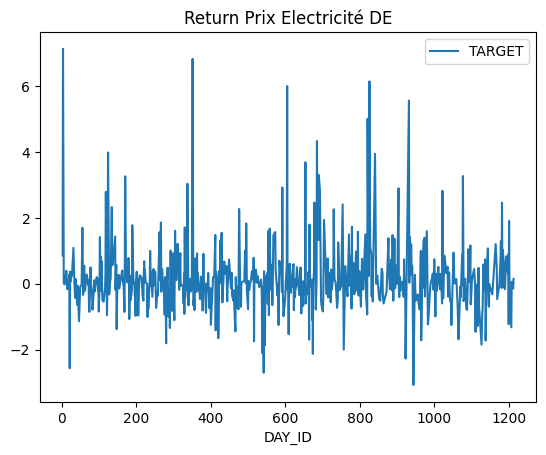

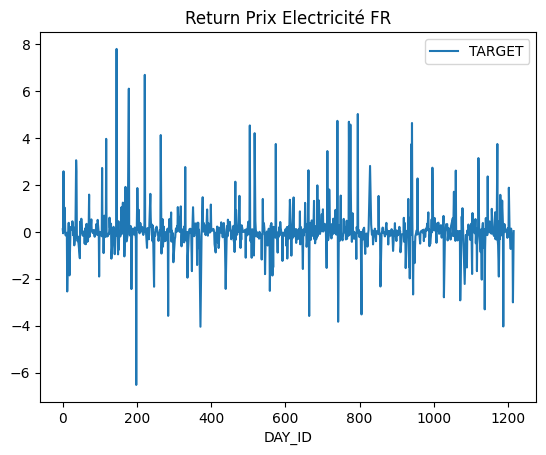

In [3]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

# 4) Traitement et création de nouvelles features

## 4.1) Gestion des valeurs manquantes

In [26]:
display(x_train.isna().sum().sort_values(ascending=False))

DE_NET_IMPORT       124
DE_NET_EXPORT       124
FR_RAIN              94
FR_TEMP              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
DE_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
COUNTRY               0
ID                    0
DAY_ID                0
DE_GAS                0
FR_GAS                0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
FR_NUCLEAR            0
DE_NUCLEAR            0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
DE_WINDPOW            0
DE_SOLAR              0
FR_RESIDUAL_LOAD      0
DE_RESIDUAL_LOAD      0
DE_LIGNITE            0
FR_WINDPOW            0
FR_SOLAR              0
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

### 4.1.1) Gestion flux

Logiquement on a :
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [3]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
680,3,DE,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


### 4.1.2) Gestion NaN Value

#### Median

In [4]:
def apply_median_completion(df, medians, columns):
    df_filled = df.copy()

    for col in columns:
        df_filled[col] = df_filled[col].fillna(
            df_filled["COUNTRY"].map(medians[col])
        )
    return df_filled

# columns with NaN in train
columns_to_fill = x_train.columns[x_train.isna().any()]

# compute medians ONLY from train
train_medians = x_train.groupby("COUNTRY")[columns_to_fill].median()

# fill both datasets using train medians
x_train_median = apply_median_completion(x_train, train_medians, columns_to_fill)
x_test_median = apply_median_completion(x_test, train_medians, columns_to_fill)

In [5]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET'],
      dtype='object')

## 4.2) Ajout de nouvelles features

Le prix de l'électricité spot (et donc sa variation journalière, qui est ta cible) est déterminé par le coût marginal de production : à chaque instant, on empile les centrales par ordre de coût croissant, et le prix est fixé par la dernière centrale appelée pour satisfaire la demande. Cette logique s'appelle le merit order.

Conséquences directes :

* Plus la demande résiduelle (consommation moins renouvelables, qui sont quasi-gratuites) est élevée, * plus on appelle des centrales chères → prix élevé.
* Plus le coût des combustibles fossiles (gaz, charbon) et du carbone est élevé, plus les centrales marginales coûtent cher → prix élevé.
* Les échanges transfrontaliers redistribuent ces effets entre marchés couplés.

In [5]:
# cible alignée sur ID
x_train_median.sort_values(["COUNTRY", "DAY_ID"], inplace=True)
y_train_clean = y_train.set_index("ID").loc[x_train_median["ID"], "TARGET"]


#### Clippage des rendements aux quantiles

In [6]:
# Clipping des rendements aux quantiles 1% / 99% (calcul sur train, appliqué aux deux)
ret_cols = ['GAS_RET', 'COAL_RET', 'CARBON_RET']
lower = x_train_median[ret_cols].quantile(0.01)
upper = x_train_median[ret_cols].quantile(0.99)

x_train_median[ret_cols] = x_train_median[ret_cols].clip(lower=lower, upper=upper, axis=1)
x_test_median[ret_cols]  = x_test_median[ret_cols].clip(lower=lower, upper=upper, axis=1)

### Ajout des features linéaires

In [7]:
def add_cross_border_flows(df):
    """Échanges transfrontaliers nets entre DE et FR."""
    # Flux net DE→FR (positif = DE exporte vers FR)
    df['NET_FLOW_DE_TO_FR'] = df['DE_FR_EXCHANGE'] - df['FR_DE_EXCHANGE']
    df['DE_NET_BALANCE']    = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_NET_BALANCE']    = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    df['DE_TRADE_BALANCE']  = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_TRADE_BALANCE']  = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    return df


def add_marginal_cost_features(df):
    """Coût marginal de production (Merit Order)."""
    # Coût effectif des centrales gaz (coût gaz + taxe carbone)
    df['GAS_CARBON_COST']  = df['GAS_RET']  + df['CARBON_RET']
    # Coût effectif des centrales charbon
    df["COAL_CARBON_COST"] = df['COAL_RET'] + df['CARBON_RET']
    # Index composite du coût fossile (proxy du prix marginal)
    df["FOSSIL_COST_INDEX"] = 0.5 * df["GAS_CARBON_COST"] + 0.5 * df["COAL_CARBON_COST"]
    # Interaction gaz × carbone : signal fort (corr=+0.10 avec TARGET)
    df["GAS_x_CARBON"] = df["GAS_RET"] * df["CARBON_RET"]
    return df


def add_residual_demand_features(df):
    """Demande résiduelle + interactions météo × production par pays."""
    for country in ["DE", "FR"]:
        renewable   = df[f"{country}_SOLAR"] + df[f"{country}_WINDPOW"] + df[f"{country}_HYDRO"]
        consumption = df[f"{country}_CONSUMPTION"]

        # Production totale ENR
        df[f"{country}_RENEWABLE_PROD"]        = renewable
        # Taux de pénétration ENR
        df[f"{country}_RENEWABLE_PENETRATION"] = renewable / consumption
        # Ratio demande résiduelle / consommation totale
        df[f"{country}_RESIDUAL_LOAD_RATIO"]   = df[f"{country}_RESIDUAL_LOAD"] / consumption
        # Prod ENR variable (vent + soleil)
        df[f"{country}_WIND_SOLAR_PROD"]        = df[f"{country}_WINDPOW"] + df[f"{country}_SOLAR"]
        # Température × demande résiduelle (effet froid sur la demande)
        df[f"{country}_TEMP_x_RESIDUAL"]        = df[f"{country}_TEMP"]  * df[f"{country}_RESIDUAL_LOAD"]
        # Vent × production éolienne
        df[f"{country}_WIND_x_WINDPOW"]         = df[f"{country}_WIND"]  * df[f"{country}_WINDPOW"]
        # Pluie × hydraulique
        df[f"{country}_RAIN_x_HYDRO"]           = df[f"{country}_RAIN"]  * df[f"{country}_HYDRO"]
        # Coût gaz pondéré par la production gaz du pays
        df[f"{country}_GAS_COST_x_PROD"]        = df["GAS_RET"]  * df[f"{country}_GAS"]
        # Coût charbon pondéré par la production charbon du pays
        df[f"{country}_COAL_COST_x_PROD"]       = df["COAL_RET"] * df[f"{country}_COAL"]

    return df


def add_thermal_need_features(df):
    """Besoin thermique par pays (ce qui doit être couvert par les fossiles)."""
    # DE : on soustrait nucléaire ET lignite
    df["DE_THERMAL_NEED"] = df["DE_RESIDUAL_LOAD"] - df["DE_NUCLEAR"] - df["DE_LIGNITE"]
    # FR : pas de colonne LIGNITE pour la France
    df["FR_THERMAL_NEED"] = df["FR_RESIDUAL_LOAD"] - df["FR_NUCLEAR"]
    return df


def add_cross_country_features(df):
    """Features cross-pays (signal d'arbitrage DE ↔ FR)."""
    df["RESIDUAL_LOAD_DIFF"]         = df["DE_RESIDUAL_LOAD"]         - df["FR_RESIDUAL_LOAD"]
    df["RENEWABLE_DIFF"]             = df["DE_RENEWABLE_PROD"]        - df["FR_RENEWABLE_PROD"]
    df["TEMP_DIFF"]                  = df["DE_TEMP"]                  - df["FR_TEMP"]
    df["NUCLEAR_DIFF"]               = df["DE_NUCLEAR"]               - df["FR_NUCLEAR"]
    df["RENEWABLE_PENETRATION_DIFF"] = df["DE_RENEWABLE_PENETRATION"] - df["FR_RENEWABLE_PENETRATION"]
    # Écart de consommation brute DE vs FR (corr=-0.06 avec TARGET)
    df["CONSUMPTION_DIFF"]           = df["DE_CONSUMPTION"]           - df["FR_CONSUMPTION"]
    return df


def add_country_encoding(df):
    """One-hot encoding de la variable COUNTRY."""
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    
    return df


def add_physical_features(df):
    """
    Pipeline complet de feature engineering physique.
    Appelle toutes les sous-fonctions dans l'ordre.
    """
    df = df.copy()
    df = add_cross_border_flows(df)
    df = add_marginal_cost_features(df)
    df = add_residual_demand_features(df)
    df = add_thermal_need_features(df)
    df = add_cross_country_features(df)
    df = add_country_encoding(df)
    return df

x_train_median = add_physical_features(x_train_median)
x_test_median  = add_physical_features(x_test_median)

### Features inter-pays

In [8]:
# features inter-pays (très important dans le mix energetique des pays frontaliers)

def add_perspective_features(df):
    df = df.copy()
    is_de = (df['COUNTRY'] == 'DE')

    # Features brutes disponibles pour les deux pays
    shared_feats = [
        'TEMP', 'RAIN', 'WIND',
        'GAS', 'COAL', 'HYDRO', 'NUCLEAR', 'SOLAR', 'WINDPOW',
        'CONSUMPTION', 'RESIDUAL_LOAD', 'NET_IMPORT', 'NET_EXPORT',
        # Features dérivées déjà créées
        'RENEWABLE_PROD', 'RENEWABLE_PENETRATION', 'RESIDUAL_LOAD_RATIO',
        'WIND_SOLAR_PROD', 'THERMAL_NEED', 'NET_BALANCE', 'TRADE_BALANCE',
        'GAS_COST_x_PROD', 'COAL_COST_x_PROD',
        'WIND_x_WINDPOW', 'RAIN_x_HYDRO', 'TEMP_x_RESIDUAL',
    ]

    for feat in shared_feats:
        de_col = f'DE_{feat}'
        fr_col = f'FR_{feat}'
        if de_col not in df.columns or fr_col not in df.columns:
            continue
        # OWN = valeur du pays prédit, OTHER = valeur de l'autre pays
        df[f'OWN_{feat}']   = np.where(is_de, df[de_col], df[fr_col])
        df[f'OTHER_{feat}']  = np.where(is_de, df[fr_col], df[de_col])
        # Ratio OWN / (OWN + OTHER) — part relative du pays prédit
        denom = df[f'OWN_{feat}'] + df[f'OTHER_{feat}']
        df[f'SHARE_{feat}'] = np.where(denom != 0, df[f'OWN_{feat}'] / denom, 0.5)

    # Spécifique DE : lignite n'existe pas en FR
    if 'DE_LIGNITE' in df.columns:
        df['OWN_LIGNITE']  = np.where(is_de, df['DE_LIGNITE'], 0.0)
        df['OTHER_LIGNITE'] = np.where(is_de, 0.0, df['DE_LIGNITE'])

    return df

x_train_v2 = add_perspective_features(x_train_median)
x_test_v2  = add_perspective_features(x_test_median)

print(f"Nouvelles colonnes ajoutées : {len(x_train_v2.columns) - len(x_train_median.columns)}")
print([c for c in x_train_v2.columns if c.startswith('OWN_') or c.startswith('SHARE_')][:10])


Nouvelles colonnes ajoutées : 77
['OWN_TEMP', 'SHARE_TEMP', 'OWN_RAIN', 'SHARE_RAIN', 'OWN_WIND', 'SHARE_WIND', 'OWN_GAS', 'SHARE_GAS', 'OWN_COAL', 'SHARE_COAL']


### Features de lags (matières premières principalement)

Les lags sont calculés sur la séquence des DAY_IDs triés. Ils sont valides car ils capturent la persistance des chocs de prix (momentum).
On remplace les Nan par la médian pour les premières lignes.

In [9]:
def add_lag_features(df_train, df_test, lag_cols, lags=[1, 2, 7]):
    """
    Ajoute des lags sur les colonnes spécifiées.
    Les lags sont calculés par jour (pas par ligne) car DE et FR
    partagent les mêmes valeurs pour ces colonnes le même jour.
    """
    df_train = df_train.copy().sort_values('DAY_ID')
    df_test  = df_test.copy().sort_values('DAY_ID')

    for df_name, df in [('train', df_train), ('test', df_test)]:
        # Une seule valeur par DAY_ID (identique pour DE et FR)
        daily = (
            df[['DAY_ID'] + [c for c in lag_cols if c in df.columns]]
            .drop_duplicates('DAY_ID')
            .sort_values('DAY_ID')
            .set_index('DAY_ID')
        )
        for col in lag_cols:
            if col not in daily.columns:
                continue
            for lag in lags:
                daily[f'{col}_lag{lag}'] = daily[col].shift(lag)

        # Récupère les noms des nouvelles colonnes
        new_cols = [f'{col}_lag{lag}' for col in lag_cols for lag in lags
                    if col in daily.columns]
        daily_new = daily[new_cols].reset_index()

        if df_name == 'train':
            df_train = df_train.merge(daily_new, on='DAY_ID', how='left')
        else:
            df_test = df_test.merge(daily_new, on='DAY_ID', how='left')

    # Remplissage des NaN par la médiane train (premières lignes sans historique)
    lag_col_names = [f'{col}_lag{lag}' for col in lag_cols for lag in lags
                     if col in df_train.columns]
    for col in lag_col_names:
        if col in df_train.columns:
            median_val = df_train[col].median()
            df_train[col] = df_train[col].fillna(median_val)
            df_test[col]  = df_test[col].fillna(median_val)

    return df_train, df_test


# Colonnes à lagger : uniquement les prix de marché (mêmes pour DE et FR)
# + éventuellement les grands agrégats par pays
lag_targets = ['GAS_RET', 'COAL_RET', 'CARBON_RET']

x_train_v2, x_test_v2 = add_lag_features(x_train_v2, x_test_v2,
                                           lag_cols=lag_targets,
                                           lags=[1, 2, 7])

print("Lags ajoutés :", [c for c in x_train_v2.columns if '_lag' in c])
print(f"Shape train : {x_train_v2.shape}")


Lags ajoutés : ['GAS_RET_lag1', 'GAS_RET_lag2', 'GAS_RET_lag7', 'COAL_RET_lag1', 'COAL_RET_lag2', 'COAL_RET_lag7', 'CARBON_RET_lag1', 'CARBON_RET_lag2', 'CARBON_RET_lag7']
Shape train : (1494, 158)


### Features merit order



In [10]:
def add_merit_order_enriched(df):
    df = df.copy()

    # ── Interaction COAL × CARBON (manquante, symétrique de GAS_x_CARBON) ──
    df['COAL_x_CARBON'] = df['COAL_RET'] * df['CARBON_RET']

    # ── Coût fossile au carré (sensibilité non-linéaire aux prix) ─────────
    df['GAS_CARBON_COST_SQ']  = df['GAS_CARBON_COST'] ** 2
    df['COAL_CARBON_COST_SQ'] = df['COAL_CARBON_COST'] ** 2

    for country in ['DE', 'FR']:
        prod_cols = [f'{country}_GAS', f'{country}_COAL', f'{country}_HYDRO',
                     f'{country}_NUCLEAR', f'{country}_SOLAR', f'{country}_WINDPOW']
        if country == 'DE':
            prod_cols.append('DE_LIGNITE')

        prod_available = [c for c in prod_cols if c in df.columns]
        total_prod = df[prod_available].sum(axis=1)

        # ── Surplus / déficit : production totale vs consommation ─────────
        df[f'{country}_SURPLUS'] = total_prod - df[f'{country}_CONSUMPTION']

        # ── Part du fossile dans la production totale ─────────────────────
        fossils = [f'{country}_GAS', f'{country}_COAL']
        if country == 'DE':
            fossils.append('DE_LIGNITE')
        fossil_prod = df[[c for c in fossils if c in df.columns]].sum(axis=1)
        df[f'{country}_FOSSIL_SHARE'] = fossil_prod / total_prod.replace(0, np.nan)

        # ── Tension prix-fossile : besoin thermique × coût fossile ────────
        # (proxy du coût marginal réel du jour)
        if f'{country}_THERMAL_NEED' in df.columns:
            df[f'{country}_MARGINAL_PRESSURE'] = (
                df[f'{country}_THERMAL_NEED'] * df['FOSSIL_COST_INDEX']
            )

        # ── Renouvelable × (-GAS_RET) : substitution solaire/éolien au gaz
        if f'{country}_WIND_SOLAR_PROD' in df.columns:
            df[f'{country}_RENEW_GAS_SUBST'] = (
                df[f'{country}_WIND_SOLAR_PROD'] * (-df['GAS_RET'])
            )

    # ── Différentiel de pression marginale entre pays ─────────────────────
    if 'DE_MARGINAL_PRESSURE' in df.columns and 'FR_MARGINAL_PRESSURE' in df.columns:
        df['MARGINAL_PRESSURE_DIFF'] = (
            df['DE_MARGINAL_PRESSURE'] - df['FR_MARGINAL_PRESSURE']
        )

    return df

x_train_v2 = add_merit_order_enriched(x_train_v2)
x_test_v2  = add_merit_order_enriched(x_test_v2)
print("Merit order enrichi — nouvelles colonnes :", 
      [c for c in x_train_v2.columns if any(k in c for k in ['SURPLUS','FOSSIL_SHARE','PRESSURE','SUBST','SQ','COAL_x'])])


Merit order enrichi — nouvelles colonnes : ['COAL_x_CARBON', 'GAS_CARBON_COST_SQ', 'COAL_CARBON_COST_SQ', 'DE_SURPLUS', 'DE_FOSSIL_SHARE', 'DE_MARGINAL_PRESSURE', 'DE_RENEW_GAS_SUBST', 'FR_SURPLUS', 'FR_FOSSIL_SHARE', 'FR_MARGINAL_PRESSURE', 'FR_RENEW_GAS_SUBST', 'MARGINAL_PRESSURE_DIFF']


In [8]:
### Features saisonnières (position dans l'année)

def add_seasonal_features_full(df_to_enrich, df_train_ref,
                                add_annual=True,
                                add_weekly_sincos=True,
                                add_weekly_onehot=False,
                                day_zero_offset=0):
    """
    Ajoute des features de position dans l'année et dans la semaine.
    df_train_ref est TOUJOURS x_train_v2 (même pour le test) pour éviter le leakage.

    Features créées :
        SIN_YEAR, COS_YEAR     : cycle annuel (365j)
        SIN_YEAR_2, COS_YEAR_2 : cycle semestriel (182j)
        SIN_WEEK, COS_WEEK     : cycle hebdomadaire (7j)
    """
    df = df_to_enrich.copy()

    # Référentiel temporel depuis le TRAIN uniquement
    all_days      = sorted(set(df_train_ref['DAY_ID'].unique()) | set(df['DAY_ID'].unique()))
    day_order_map = {day: i for i, day in enumerate(all_days)}
    df['DAY_ORDER'] = df['DAY_ID'].map(day_order_map)

    day_order_shifted = df['DAY_ORDER'] + day_zero_offset

    if add_annual:
        df['SIN_YEAR']   = np.sin(2 * np.pi * day_order_shifted / 365)
        df['COS_YEAR']   = np.cos(2 * np.pi * day_order_shifted / 365)
        df['SIN_YEAR_2'] = np.sin(4 * np.pi * day_order_shifted / 365)
        df['COS_YEAR_2'] = np.cos(4 * np.pi * day_order_shifted / 365)

    if add_weekly_sincos:
        df['SIN_WEEK'] = np.sin(2 * np.pi * df['DAY_ORDER'] / 7)
        df['COS_WEEK'] = np.cos(2 * np.pi * df['DAY_ORDER'] / 7)

    if add_weekly_onehot:
        df['DAY_MOD7'] = df['DAY_ORDER'] % 7
        for i in range(7):
            df[f'DAY_MOD_{i}'] = (df['DAY_MOD7'] == i).astype(int)
        df.drop(columns='DAY_MOD7', inplace=True)

    return df


In [9]:
# Bloc 4 — Saisonnalité annuelle (meilleure config d'après VARIANTE B)
x_train_v2 = add_seasonal_features_full(x_train_v2, x_train_v2,
                                         add_annual=True,
                                         add_weekly_sincos=False)
x_test_v2  = add_seasonal_features_full(x_test_v2,  x_train_v2,
                                         add_annual=True,
                                         add_weekly_sincos=False)



NameError: name 'x_train_v2' is not defined

### Sélection des features (multi methodes)

In [10]:
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance

spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)


In [21]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import ElasticNetCV

index_cols_v2 = ["ID", "DAY_ID"]
exclude_cols  = index_cols_v2 + ["COUNTRY", "COUNTRY_DE", "COUNTRY_FR"]

feature_cols_v2 = [c for c in x_train_v2.columns if c not in exclude_cols]

# ── Normalisation du nouveau dataset ──────────────────────────────────────
from sklearn.preprocessing import QuantileTransformer

qt2 = QuantileTransformer(output_distribution='normal', random_state=42)
cols_to_norm = [c for c in feature_cols_v2]  # toutes les features continues

X_raw = x_train_v2.set_index("ID")[feature_cols_v2].copy()
X_raw_test = x_test_v2.set_index("ID")[feature_cols_v2].copy()

X_norm = pd.DataFrame(
    qt2.fit_transform(X_raw),
    columns=feature_cols_v2,
    index=X_raw.index
)
X_norm_test = pd.DataFrame(
    qt2.transform(X_raw_test),
    columns=feature_cols_v2,
    index=X_raw_test.index
)

# Aligner y_cv sur le nouvel index
y_cv_v2 = y_train.set_index("ID").loc[x_train_v2["ID"], "TARGET"]
groups_v2 = x_train_v2.set_index("ID").loc[X_norm.index, "DAY_ID"].values

# ── Méthode 1 : Spearman univarié ─────────────────────────────────────────
spearman_scores = {}
for col in feature_cols_v2:
    rho, _ = spearmanr(X_norm[col].fillna(0), y_cv_v2)
    spearman_scores[col] = abs(rho)

selected_spearman = {k for k, v in spearman_scores.items() if v > 0.05}
print(f"Méthode 1 (Spearman > 0.05) : {len(selected_spearman)} features")

# ── Méthode 2 : Permutation importance RF ────────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

rf_sel = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_sel.fit(X_norm, y_cv_v2)

perm = permutation_importance(rf_sel, X_norm, y_cv_v2,
                               scoring=spearman_scorer,
                               n_repeats=5, random_state=42, n_jobs=-1)
selected_perm = {feature_cols_v2[i] for i, m in enumerate(perm.importances_mean) if m > 0}
print(f"Méthode 2 (Perm. importance > 0) : {len(selected_perm)} features")

# ── Méthode 3 : ElasticNet ────────────────────────────────────────────────
en = ElasticNetCV(
    alphas=np.logspace(-3, 2, 40),
    l1_ratio=[0.3, 0.5, 0.7, 0.9, 0.95],
    cv=list(GroupKFold(5).split(X_norm, y_cv_v2, groups=groups_v2)),
    max_iter=50000, n_jobs=-1
)
en.fit(X_norm, y_cv_v2)
selected_en = {col for col, coef in zip(feature_cols_v2, en.coef_) if coef != 0}
print(f"Méthode 3 (ElasticNet ≠ 0) : {len(selected_en)} features")

# ── Vote : garder les features validées par ≥ 2 méthodes ─────────────────
from collections import Counter
votes = Counter()
for s in [selected_spearman, selected_perm, selected_en]:
    for f in s:
        votes[f] += 1

# Seuil ≥ 2 votes sur 3
selected_final = [f for f, v in votes.items() if v >= 2]
print(f"\nFeatures finales (≥ 2 votes) : {len(selected_final)}")
print(sorted(selected_final))

# Baseline avec ces features
baseline_v2 = cross_val_score(
    RidgeCV(alphas=np.logspace(-4, 4, 100), cv=10),
    X_norm[selected_final], y_cv_v2,
    cv=list(GroupKFold(5).split(X_norm[selected_final], y_cv_v2, groups=groups_v2)),
    scoring=spearman_scorer, n_jobs=-1
)
print(f"\nRidge (features sélectionnées) → Spearman CV : {np.mean(baseline_v2):.4f} ± {np.std(baseline_v2):.4f}")


Méthode 1 (Spearman > 0.05) : 60 features
Méthode 2 (Perm. importance > 0) : 169 features
Méthode 3 (ElasticNet ≠ 0) : 20 features

Features finales (≥ 2 votes) : 66
['CARBON_RET', 'COAL_CARBON_COST', 'COAL_RET_lag2', 'DE_COAL', 'DE_CONSUMPTION', 'DE_FOSSIL_SHARE', 'DE_FR_EXCHANGE', 'DE_GAS', 'DE_HYDRO', 'DE_MARGINAL_PRESSURE', 'DE_NET_BALANCE', 'DE_NET_EXPORT', 'DE_NET_IMPORT', 'DE_RENEWABLE_PENETRATION', 'DE_RESIDUAL_LOAD', 'DE_RESIDUAL_LOAD_RATIO', 'DE_SURPLUS', 'DE_THERMAL_NEED', 'DE_TRADE_BALANCE', 'DE_WIND', 'DE_WINDPOW', 'DE_WIND_SOLAR_PROD', 'FOSSIL_COST_INDEX', 'FR_DE_EXCHANGE', 'FR_HYDRO', 'FR_RAIN', 'FR_RENEWABLE_PROD', 'FR_RENEW_GAS_SUBST', 'FR_WIND', 'FR_WINDPOW', 'FR_WIND_SOLAR_PROD', 'GAS_CARBON_COST', 'GAS_CARBON_COST_SQ', 'GAS_RET', 'GAS_x_CARBON', 'NET_FLOW_DE_TO_FR', 'OTHER_CONSUMPTION', 'OTHER_GAS_COST_x_PROD', 'OTHER_HYDRO', 'OTHER_RAIN', 'OTHER_WIND', 'OTHER_WINDPOW', 'OTHER_WIND_SOLAR_PROD', 'OWN_COAL', 'OWN_GAS', 'OWN_HYDRO', 'OWN_NET_BALANCE', 'OWN_NET_EXPORT',

In [ ]:
# Alias depuis le Bloc 4 (nommés y_cv_v2 / groups_v2 dans la sélection)
y_krr      = y_cv_v2
groups_krr = groups_v2


In [12]:
# ── Définitions communes aux variantes A et B ────────────────────────────


def cv_score_par_pays(model_factory, X, y, groups, country_flag):
    """Evalue un modele KernelRidge entraine separement sur DE et FR."""
    scores = []
    gkf_local = GroupKFold(n_splits=5)
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        pred_va = np.zeros(len(va_idx))
        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val
            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue
            m = model_factory()
            m.fit(X_tr[mask_tr], y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(X_va[mask_va])
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores), np.std(scores)



---
## VARIANTE A — KernelRidge sans lags

**Meilleur CV : 0.2846** | Score public : 0.1910

Pipeline : features physiques + inter-pays (Bloc 1) + merit order (Bloc 3) → sélection 64 features → KernelRidge RBF séparé DE/FR

> **Prérequis** : avoir lancé toutes les cellules du pipeline commun (imports → Bloc 3 → sélection features Bloc 4)

### Sélection des features (sans lags) + KernelRidge Optuna

In [23]:
# Features sans aucun lag (suppositions temporelles)
selected_no_lag = [f for f in selected_final if '_lag' not in f]
print(f"Features sans lag : {len(selected_no_lag)}")

X_krr_nlag = X_norm[selected_no_lag].copy()
X_krr_nlag['COUNTRY_DE'] = x_train_v2.set_index('ID').loc[X_krr_nlag.index, 'COUNTRY_DE'].values

def objective_krr_nlag(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-5, 1.0, log=True)
    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='normal', n_quantiles=500, random_state=42
        )
    )
    mean_score, _ = cv_score_par_pays(factory, X_krr_nlag, y_krr, groups_krr, 'COUNTRY_DE')
    return mean_score

study_krr_nlag = optuna.create_study(direction='maximize')
study_krr_nlag.optimize(objective_krr_nlag, n_trials=80, show_progress_bar=True)

print(f"Meilleurs params : {study_krr_nlag.best_params}")
print(f"KernelRidge sans lags → CV : {study_krr_nlag.best_value:.4f}")
print(f"KernelRidge avec lags → CV : 0.2843")


[I 2026-04-20 11:49:26,624] A new study created in memory with name: no-name-ce056993-8977-484e-a2d3-260638229688


Features sans lag : 65


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-04-20 11:49:26,892] Trial 0 finished with value: 0.038615994842293944 and parameters: {'alpha': 24.01093396159391, 'gamma': 0.27412988756880935}. Best is trial 0 with value: 0.038615994842293944.
[I 2026-04-20 11:49:27,233] Trial 1 finished with value: 0.26550884452409224 and parameters: {'alpha': 0.008981365691309785, 'gamma': 7.987675622806391e-05}. Best is trial 1 with value: 0.26550884452409224.
[I 2026-04-20 11:49:27,510] Trial 2 finished with value: 0.25848816339172204 and parameters: {'alpha': 0.03275394834371414, 'gamma': 0.00038400488984774455}. Best is trial 1 with value: 0.26550884452409224.
[I 2026-04-20 11:49:27,778] Trial 3 finished with value: 0.03368236170059312 and parameters: {'alpha': 0.9867489986325085, 'gamma': 0.7899436984617131}. Best is trial 1 with value: 0.26550884452409224.
[I 2026-04-20 11:49:28,030] Trial 4 finished with value: 0.2749890049397578 and parameters: {'alpha': 5.102091572310236, 'gamma': 0.0002884902909184275}. Best is trial 4 with value

In [30]:
# === Soumission corrigée — vérification des index ===
best_alpha_seas = study_krr_nlag.best_params['alpha']
best_gamma_seas = study_krr_nlag.best_params['gamma']

# X_train_sub et X_test_sub : index = ID, ordre = DAY_ID trié
X_train_sub = X_norm[selected_no_lag]
X_test_sub  = X_norm_test[selected_no_lag]

# Masques : positionnels, dans l'ordre de x_train_v2/x_test_v2 (DAY_ID trié)
mask_de_train = (x_train_v2['COUNTRY'] == 'DE').values
mask_fr_train = (x_train_v2['COUNTRY'] == 'FR').values
mask_de_test  = (x_test_v2['COUNTRY'] == 'DE').values
mask_fr_test  = (x_test_v2['COUNTRY'] == 'FR').values

# preds_test : tableau positionnel, même ordre que x_test_v2 (DAY_ID trié)
preds_test = np.zeros(len(x_test_v2))

for mask_tr, mask_te in [(mask_de_train, mask_de_test), (mask_fr_train, mask_fr_test)]:
    m = TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha_seas, kernel='rbf', gamma=best_gamma_seas),
        transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
    )
    m.fit(X_train_sub[mask_tr], y_krr[mask_tr])
    preds_test[mask_te] = m.predict(X_test_sub.values[mask_te])

# Créer une Series indexée par ID (ordre DAY_ID trié de x_test_v2)
preds_by_id = pd.Series(preds_test, index=x_test_v2['ID'].values)

# Alignement par ID → corrige le désordre entre x_test_v2 et x_test.csv
sub = pd.read_csv('x_test_final.csv')[['ID']]
sub['TARGET'] = sub['ID'].map(preds_by_id)

# Vérifications
assert sub['TARGET'].isna().sum() == 0, "NaN détectés — problème d'alignement ID"
assert len(sub) == len(x_test_v2), "Taille incorrecte"
print(f"Shape : {sub.shape}")
print(sub['TARGET'].describe().round(4))

sub.to_csv('submission_krr_seasonal_v2.csv', index=False)
print("Fichier sauvegardé : submission_krr_seasonal_v2.csv")


Shape : (654, 2)
count    654.0000
mean       0.0139
std        0.1407
min       -0.5506
25%       -0.0326
50%        0.0000
75%        0.0504
max        1.0432
Name: TARGET, dtype: float64
Fichier sauvegardé : submission_krr_seasonal_v2.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(


In [27]:
# === RidgeCV avec cross-validation (séparé DE/FR) ===

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score

# Matrice X : mêmes features que VARIANTE A (avec saisonnalité si intégrée)
X_ridge = X_norm[selected_no_lag].copy()
X_ridge['COUNTRY_DE'] = (x_train_v2.set_index('ID').loc[X_ridge.index, 'COUNTRY'] == 'DE').astype(int).values

# Évaluation avec cv_score_par_pays (séparé DE/FR, même protocole que KernelRidge)
factory_ridge = lambda: RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

mean_r, std_r = cv_score_par_pays(factory_ridge, X_ridge, y_krr, groups_krr, 'COUNTRY_DE')

print(f"RidgeCV séparé DE/FR  → Spearman CV : {mean_r:.4f} ± {std_r:.4f}")
print(f"KernelRidge (ref)     → Spearman CV : 0.2868")
print(f"Gain KernelRidge      : {0.2868 - mean_r:+.4f}")


RidgeCV séparé DE/FR  → Spearman CV : 0.2727 ± 0.0412
KernelRidge (ref)     → Spearman CV : 0.2868
Gain KernelRidge      : +0.0141


In [28]:
# === Comparaison : avec vs sans séparation des pays ===

from sklearn.model_selection import cross_val_score

X_eval = X_norm[selected_no_lag].copy()
X_eval['COUNTRY_DE'] = (x_train_v2.set_index('ID').loc[X_eval.index, 'COUNTRY'] == 'DE').astype(int).values

gkf = GroupKFold(n_splits=5)
cv_split = list(gkf.split(X_eval, y_krr, groups=groups_krr))

modeles = {
    'RidgeCV'      : lambda: RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5),
    'KernelRidge'  : lambda: TransformedTargetRegressor(
                        regressor=KernelRidge(alpha=best_alpha_nlag, kernel='rbf', gamma=best_gamma_nlag),
                        transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
                     ),
    'SVR RBF'      : lambda: TransformedTargetRegressor(
                        regressor=SVR(kernel='rbf', C=10, epsilon=0.1),
                        transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
                     ),
}

print(f"{'Modèle':<16} {'Sans séparation':>17} {'Avec séparation':>17} {'Gain':>8}")
print("=" * 62)

for nom, factory in modeles.items():
    # Sans séparation : un seul modèle sur DE + FR
    scores_global = cross_val_score(
        factory(), X_eval, y_krr,
        cv=cv_split, scoring=spearman_scorer, n_jobs=-1
    )
    mean_global = np.mean(scores_global)

    # Avec séparation : modèles distincts DE / FR
    mean_sep, _ = cv_score_par_pays(factory, X_eval, y_krr, groups_krr, 'COUNTRY_DE')

    gain = mean_sep - mean_global
    print(f"  {nom:<14} {mean_global:>14.4f}    {mean_sep:>14.4f}   {gain:>+7.4f}")

print("=" * 62)


Modèle             Sans séparation   Avec séparation     Gain
  RidgeCV                0.2502            0.2729   +0.0227
  KernelRidge            0.2616            0.2854   +0.0238
  SVR RBF                0.1719            0.1684   -0.0035


---
## VARIANTE B — Avec saisonnalité

**Meilleur public connu : 0.21** (Ridge + saisonnalité dans main_bis.ipynb)

Teste 6 configurations de features temporelles (cycle annuel 365j, semestriel, hebdomadaire) sur KernelRidge.

> **Prérequis** : avoir lancé la VARIANTE A (nécessite , , , )

In [18]:
# ── Configs à tester ───────────────────────────────────────────────────────
configs_krr = {
    'annuel_only'    : dict(add_annual=True,  add_weekly_sincos=False, day_zero_offset=0),
    'annuel_off_90'  : dict(add_annual=True,  add_weekly_sincos=False, day_zero_offset=90),
    'annuel_off_180' : dict(add_annual=True,  add_weekly_sincos=False, day_zero_offset=180),
    'annuel_off_270' : dict(add_annual=True,  add_weekly_sincos=False, day_zero_offset=270),
    'annuel+hebdo'   : dict(add_annual=True,  add_weekly_sincos=True,  day_zero_offset=0),
    'hebdo_only'     : dict(add_annual=False, add_weekly_sincos=True,  day_zero_offset=0),
}

results_seas = {}

for nom, config in configs_krr.items():

    x_tr_s = add_seasonal_features_full(x_train_v2, x_train_v2, **config)

    new_seas = [c for c in x_tr_s.columns
                if c not in x_train_v2.columns and c != 'DAY_ORDER']

    # Garder l'index ID de X_norm pour rester aligné avec y_krr
    X_tr_eval = X_norm[selected_no_lag].copy()

    # Aligner les features saisonnières sur l'index ID
    x_tr_s_idx = x_tr_s.set_index('ID')
    for col in new_seas:
        X_tr_eval[col] = x_tr_s_idx.loc[X_tr_eval.index, col].values

    X_tr_eval['COUNTRY_DE'] = (
        x_train_v2.set_index('ID').loc[X_tr_eval.index, 'COUNTRY'] == 'DE'
    ).astype(int).values

    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha_nlag, kernel='rbf', gamma=best_gamma_nlag),
        transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
    )
    mean_s, std_s = cv_score_par_pays(factory, X_tr_eval, y_krr, groups_krr, 'COUNTRY_DE')

    results_seas[nom] = {'cv_mean': mean_s, 'cv_std': std_s, 'cols': new_seas}
    print(f"  {nom:<20} -> {mean_s:.4f} +/- {std_s:.4f}  |  {new_seas}")

print(f"\n{'='*60}")
print(f"{'Config':<20} {'CV Spearman':>12} {'Std':>8}")
print(f"{'='*60}")
for nom, res in sorted(results_seas.items(), key=lambda x: -x[1]['cv_mean']):
    print(f"  {nom:<18} {res['cv_mean']:>12.4f} {res['cv_std']:>8.4f}")
print(f"{'='*60}")
print(f"\nReference sans saisonnalite : 0.2846")


  annuel_only          -> 0.2879 +/- 0.0295  |  ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2']
  annuel_off_90        -> 0.2879 +/- 0.0295  |  ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2']
  annuel_off_180       -> 0.2879 +/- 0.0295  |  ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2']
  annuel_off_270       -> 0.2879 +/- 0.0295  |  ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2']
  annuel+hebdo         -> 0.2855 +/- 0.0302  |  ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2', 'SIN_WEEK', 'COS_WEEK']
  hebdo_only           -> 0.2825 +/- 0.0296  |  ['SIN_WEEK', 'COS_WEEK']

Config                CV Spearman      Std
  annuel_only              0.2879   0.0295
  annuel_off_90            0.2879   0.0295
  annuel_off_180           0.2879   0.0295
  annuel_off_270           0.2879   0.0295
  annuel+hebdo             0.2855   0.0302
  hebdo_only               0.2825   0.0296

Reference sans saisonnalite : 0.2846


### VARIANTE C

In [14]:
# ============================================================
# VARIANTE C — KernelRidge sur features physiques + saisonnalité
# (sans OWN/OTHER, sans merit order enrichi, sans lags)
# Objectif : battre le score public 0.211 (Ridge + saisonnalité)
# Prérequis : avoir lancé jusqu'à add_physical_features (cell 37)
#             + add_seasonal_features_full définie (cell 44)
#             + cv_score_par_pays définie (cell 48)
# ============================================================

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Étape 1 : Ajouter les features saisonnières sur données physiques ────
x_train_c = add_seasonal_features_full(x_train_median, x_train_median,
                                        add_annual=True,
                                        add_weekly_sincos=False)
x_test_c  = add_seasonal_features_full(x_test_median,  x_train_median,
                                        add_annual=True,
                                        add_weekly_sincos=False)

print("Features saisonnières ajoutées :", ['SIN_YEAR','COS_YEAR','SIN_YEAR_2','COS_YEAR_2'])

# ── Étape 2 : Normalisation ──────────────────────────────────────────────
exclude_c = ['ID', 'DAY_ID', 'COUNTRY', 'COUNTRY_DE', 'COUNTRY_FR']
feature_cols_c = [c for c in x_train_c.columns if c not in exclude_c]

qt_c = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
X_norm_c      = pd.DataFrame(qt_c.fit_transform(x_train_c[feature_cols_c]),
                              columns=feature_cols_c, index=x_train_c['ID'].values)
X_norm_c_test = pd.DataFrame(qt_c.transform(x_test_c[feature_cols_c]),
                              columns=feature_cols_c, index=x_test_c['ID'].values)

y_c      = y_train.set_index('ID').loc[x_train_c['ID'], 'TARGET']
groups_c = x_train_c['DAY_ID'].values

# Ajout du flag pays
X_norm_c['COUNTRY_DE']      = (x_train_c['COUNTRY'] == 'DE').astype(int).values
X_norm_c_test['COUNTRY_DE'] = (x_test_c['COUNTRY'] == 'DE').astype(int).values

print(f"X train : {X_norm_c.shape}, X test : {X_norm_c_test.shape}")

# ── Étape 3 : Optuna KernelRidge ────────────────────────────────────────
def objective_krr_c(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-5, 1.0,   log=True)
    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(output_distribution='normal',
                                        n_quantiles=500, random_state=42)
    )
    mean_s, _ = cv_score_par_pays(factory, X_norm_c, y_c, groups_c, 'COUNTRY_DE')
    return mean_s

study_krr_c = optuna.create_study(direction='maximize')
study_krr_c.optimize(objective_krr_c, n_trials=80, show_progress_bar=True)

best_alpha_c = study_krr_c.best_params['alpha']
best_gamma_c = study_krr_c.best_params['gamma']
print(f"\nMeilleur CV    : {study_krr_c.best_value:.4f}")
print(f"Meilleurs params : alpha={best_alpha_c:.5f}, gamma={best_gamma_c:.2e}")
print(f"Référence Ridge + saisonnalité (public) : 0.211")

# ── Étape 4 : Soumission ────────────────────────────────────────────────
mask_de_tr = (x_train_c['COUNTRY'] == 'DE').values
mask_fr_tr = (x_train_c['COUNTRY'] == 'FR').values
mask_de_te = (x_test_c['COUNTRY'] == 'DE').values
mask_fr_te = (x_test_c['COUNTRY'] == 'FR').values

preds_test_c = np.zeros(len(x_test_c))

for mask_tr, mask_te in [(mask_de_tr, mask_de_te), (mask_fr_tr, mask_fr_te)]:
    m = TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha_c, kernel='rbf', gamma=best_gamma_c),
        transformer=QuantileTransformer(output_distribution='normal',
                                        n_quantiles=500, random_state=42)
    )
    m.fit(X_norm_c[mask_tr], y_c[mask_tr])
    preds_test_c[mask_te] = m.predict(X_norm_c_test.values[mask_te])

# Alignement par ID (x_test_c peut être dans un ordre différent de x_test.csv)
preds_by_id_c = pd.Series(preds_test_c, index=x_test_c['ID'].values)
sub_c = pd.read_csv('x_test_final.csv')[['ID']]
sub_c['TARGET'] = sub_c['ID'].map(preds_by_id_c)

assert sub_c['TARGET'].isna().sum() == 0, "Erreur alignement ID"
print(f"\nShape soumission : {sub_c.shape}")
print(sub_c['TARGET'].describe().round(4))
sub_c.to_csv('submission_krr_physique_seasonal.csv', index=False)
print("Fichier sauvegardé : submission_krr_physique_seasonal.csv")


Features saisonnières ajoutées : ['SIN_YEAR', 'COS_YEAR', 'SIN_YEAR_2', 'COS_YEAR_2']
X train : (1494, 73), X test : (654, 73)


  0%|          | 0/80 [00:00<?, ?it/s]


Meilleur CV    : 0.2772
Meilleurs params : alpha=0.29243, gamma=1.10e-04
Référence Ridge + saisonnalité (public) : 0.211

Shape soumission : (654, 2)
count    654.0000
mean       0.0103
std        0.1160
min       -0.5135
25%       -0.0321
50%       -0.0033
75%        0.0401
max        0.6883
Name: TARGET, dtype: float64
Fichier sauvegardé : submission_krr_physique_seasonal.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(


## 4.3) Normalisation des données

Les données, étant dans des unités différentes et de variations différentes, il convient de les normaliser afin de pouvoir les comparer par la suite.

In [16]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET',
       'NET_FLOW_DE_TO_FR', 'DE_NET_BALANCE', 'FR_NET_BALANCE',
       'DE_TRADE_BALANCE', 'FR_TRADE_BALANCE', 'GAS_CARBON_COST',
       'COAL_CARBON_COST', 'FOSSIL_COST_INDEX', 'GAS_x_CARBON',
       'DE_RENEWABLE_PROD', 'DE_RENEWABLE_PENETRATION',
       'DE_RESIDUAL_LOAD_RATIO', 'DE_WIND_SOLAR_PROD', 'DE_TEMP_x_RESIDUAL',
       'DE_WIND_x_WINDPOW', 'DE_RAIN_x_HYDRO', 'DE_GAS_COST_x_PROD',
       'DE_COAL_COST_x_PROD', 'FR_RENEWABLE_PROD', 'FR_RENEWABLE_PENETRATION',
      

In [24]:
index_cols = ["ID", "DAY_ID"]
do_not_normalize= index_cols + ["COUNTRY", "COUNTRY_DE","COUNTRY_FR"]
cols_to_normalize = [c for c in x_train_median.columns if c not in do_not_normalize]


In [9]:

qt = QuantileTransformer(output_distribution='normal', random_state=42)

# On applique la transfo sur les colonnes continues uniquement
x_train_median[cols_to_normalize] = qt.fit_transform(x_train_median[cols_to_normalize])
x_test_median[cols_to_normalize]  = qt.transform(x_test_median[cols_to_normalize])

In [18]:
def objective_c_full(trial):
    # Kernel + paramètres associés
    kernel = trial.suggest_categorical('kernel', ['rbf', 'laplacian', 'polynomial', 'cosine'])
    alpha  = trial.suggest_float('alpha', 1e-3, 10.0, log=True)

    kernel_params = {}
    if kernel in ['rbf', 'laplacian']:
        kernel_params['gamma'] = trial.suggest_float('gamma', 1e-6, 5e-4, log=True)
    elif kernel == 'polynomial':
        kernel_params['gamma']  = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
        kernel_params['degree'] = trial.suggest_int('degree', 2, 4)
        kernel_params['coef0']  = trial.suggest_float('coef0', 0.0, 5.0)
    # cosine : pas de gamma

    # Transformation de la target
    target_dist = trial.suggest_categorical('target_dist', ['normal', 'uniform'])
    n_quantiles  = trial.suggest_categorical('n_quantiles', [200, 500, 1000])

    model_factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(kernel=kernel, alpha=alpha, **kernel_params),
        transformer=QuantileTransformer(
            output_distribution=target_dist,
            n_quantiles=n_quantiles,
            random_state=42
        )
    )

    score, _ = cv_score_par_pays(model_factory, X_norm_c, y_c, groups_c, 'COUNTRY_DE')
    return score

study_c_full = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=20)
)

# Warm-start avec nos meilleurs points connus
study_c_full.enqueue_trial({'kernel': 'rbf',       'alpha': 0.0833, 'gamma': 4e-5,  'target_dist': 'normal', 'n_quantiles': 500})
study_c_full.enqueue_trial({'kernel': 'rbf',       'alpha': 0.039,  'gamma': 1.85e-5,'target_dist': 'normal', 'n_quantiles': 500})
study_c_full.enqueue_trial({'kernel': 'laplacian', 'alpha': 0.05,   'gamma': 1e-4,  'target_dist': 'normal', 'n_quantiles': 500})
study_c_full.enqueue_trial({'kernel': 'cosine',    'alpha': 0.1,    'target_dist': 'normal', 'n_quantiles': 500})

study_c_full.optimize(objective_c_full, n_trials=150, show_progress_bar=True)

print(f"Best CV : {study_c_full.best_value:.4f}")
print(f"Params  : {study_c_full.best_params}")


  0%|          | 0/150 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (681). n_quantiles is set to n_samples.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (514). n_quantiles is set to n_samples.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (681). n_quantiles is set to n_samples.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (514). n_quantiles is set to n_samples.
  warnings.warn(


Best CV : 0.2776
Params  : {'kernel': 'rbf', 'alpha': 0.10437898869885706, 'gamma': 7.429687761853626e-05, 'target_dist': 'uniform', 'n_quantiles': 200}


In [19]:
import pandas as pd

df_trials = study_c_full.trials_dataframe()
df_trials = df_trials[df_trials['state'] == 'COMPLETE'].sort_values('value', ascending=False)

# Top 3 par kernel
for k in ['rbf', 'laplacian', 'polynomial', 'cosine']:
    sub = df_trials[df_trials['params_kernel'] == k].head(3)
    if len(sub):
        print(f"\n--- {k} ---")
        print(sub[['value', 'params_alpha', 'params_gamma', 'params_target_dist', 'params_n_quantiles']].to_string(index=False))



--- rbf ---
   value  params_alpha  params_gamma params_target_dist  params_n_quantiles
0.277616      0.104379      0.000074            uniform                 200
0.277383      0.083522      0.000058            uniform                 200
0.277353      0.108665      0.000073            uniform                 200

--- laplacian ---
   value  params_alpha  params_gamma params_target_dist  params_n_quantiles
0.269480      0.015452      0.000018            uniform                 200
0.268991      0.053455      0.000091            uniform                 200
0.267322      0.029589      0.000051             normal                 500

--- polynomial ---
   value  params_alpha  params_gamma params_target_dist  params_n_quantiles
0.268757      0.202085      0.000204            uniform                 200
0.267580      1.798678      0.000258            uniform                 200
0.260449      0.091788      0.000922             normal                 500

--- cosine ---
   value  params_alp

In [20]:
def objective_c_refine(trial):
    alpha  = trial.suggest_float('alpha', 0.05, 0.30, log=True)
    gamma  = trial.suggest_float('gamma', 3e-5, 2e-4, log=True)
    n_q    = trial.suggest_categorical('n_quantiles', [100, 150, 200, 300])

    model_factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='uniform',   # fixé
            n_quantiles=n_q,
            random_state=42
        )
    )
    score, _ = cv_score_par_pays(model_factory, X_norm_c, y_c, groups_c, 'COUNTRY_DE')
    return score

study_refine = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10)
)
study_refine.enqueue_trial({'alpha': 0.104379, 'gamma': 0.000074, 'n_quantiles': 200})
study_refine.enqueue_trial({'alpha': 0.083522, 'gamma': 0.000058, 'n_quantiles': 200})
study_refine.enqueue_trial({'alpha': 0.108665, 'gamma': 0.000073, 'n_quantiles': 200})

study_refine.optimize(objective_c_refine, n_trials=80, show_progress_bar=True)

print(f"Best CV : {study_refine.best_value:.4f}")
print(f"Params  : {study_refine.best_params}")


  0%|          | 0/80 [00:00<?, ?it/s]

Best CV : 0.2778
Params  : {'alpha': 0.10050714681428591, 'gamma': 7.08915926762733e-05, 'n_quantiles': 200}


In [21]:
bp = study_refine.best_params

final_model = lambda: TransformedTargetRegressor(
    regressor=KernelRidge(kernel='rbf', alpha=bp['alpha'], gamma=bp['gamma']),
    transformer=QuantileTransformer(output_distribution='uniform',
                                    n_quantiles=bp['n_quantiles'], random_state=42)
)

preds_test_c = np.zeros(len(X_norm_c_test))
for flag_val in [0, 1]:
    mask_tr = X_norm_c['COUNTRY_DE'] == flag_val
    mask_te = X_norm_c_test['COUNTRY_DE'] == flag_val
    m = final_model()
    m.fit(X_norm_c[mask_tr], y_c[mask_tr])
    preds_test_c[mask_te.values] = m.predict(X_norm_c_test[mask_te])

preds_by_id_c = pd.Series(preds_test_c, index=x_test_c['ID'].values)
sub = pd.read_csv('x_test.csv')[['ID']]
sub['TARGET'] = sub['ID'].map(preds_by_id_c)
assert sub['TARGET'].isna().sum() == 0
sub.to_csv('submission_krr_seasonal_v3.csv', index=False)
print("Soumission prête")


FileNotFoundError: [Errno 2] No such file or directory: 'x_test.csv'

## 4.4) Sélection de variable : Spearman corrélation + Permutation Importance

In [25]:
# Scorer Spearman pour la cross validation
spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)


# GroupKFold sur DAY_ID : DE et FR d'un même jour restent dans le même fold
groups = x_train_median['DAY_ID'].values
gkf = GroupKFold(n_splits=5)

feature_cols = [c for c in x_train_median.columns if c not in index_cols + ["COUNTRY"]]
X_cv = x_train_median.set_index("ID")[feature_cols]
y_cv = y_train_clean

# Baseline : score avec toutes les features
baseline = cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    X_cv, y_cv,
    cv=list(gkf.split(X_cv, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)

print(f"Toutes features --> Spearman CV : {np.mean(baseline):.4f} ± {np.std(baseline):.4f}")


# Sélection des variables par permutation importance
# On entraine le modele sur tout le train, puis on mesure la perte de score
# quand on melange aleatoirement chaque feature une par une
# les 300 arbres c'est un peu arbitraire mais c'est juste pour prendre large
selector_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
selector_model.fit(X_cv, y_cv)

perm_imp = permutation_importance(
    selector_model, X_cv, y_cv,
    scoring=spearman_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

print(imp_df.to_string(index=False))

# On garde les features qui contribuent positivement au score
selected_features_perm = imp_df[imp_df['importance_mean'] > 0]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols)}")

Toutes features --> Spearman CV : 0.1831 ± 0.0440
                   feature  importance_mean  importance_std
                COUNTRY_FR         0.103209        0.004757
                DE_WINDPOW         0.091006        0.007380
                COUNTRY_DE         0.084222        0.004327
        FR_WIND_SOLAR_PROD         0.034835        0.002769
        RESIDUAL_LOAD_DIFF         0.030894        0.002410
          DE_RESIDUAL_LOAD         0.030459        0.002974
                DE_LIGNITE         0.024740        0.003636
        DE_WIND_SOLAR_PROD         0.024637        0.003039
         FR_WIND_x_WINDPOW         0.023270        0.003574
        FR_GAS_COST_x_PROD         0.022724        0.002179
                FR_WINDPOW         0.019279        0.002867
                    FR_GAS         0.018090        0.003340
                   DE_WIND         0.017304        0.001868
                   DE_RAIN         0.016342        0.001780
                  DE_SOLAR         0.015874       

Utilisation de GroupKFold:
Sklearn découpe les 1494 lignes en 5 paquets (folds) en respectant une règle : toutes les lignes partageant le même DAY_ID restent dans le même fold. Comme on a deux lignes par jour (une DE, une FR), ça garantit que la ligne FR du jour 42 n'est jamais en train pendant que la ligne DE du jour 42 est en validation. Sinon le modèle verrait l'info météo/énergétique du jour en train (via l'autre pays) et tricherait.

# 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximiser la corrélation de Spearman. Nous allons nous concentrer sur les modèles de régression.

In [26]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(random_state=42),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# modèle de boosting sans paramétrage
models['LightGBM'] = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
)
models['XGBoost'] = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

models['KernelRidge'] = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', QuantileTransformer(output_distribution='normal', n_quantiles=200, random_state=42)),
        ('kr',     KernelRidge(kernel='rbf', alpha=0.1005, gamma=7.09e-5))
    ]),
    transformer=QuantileTransformer(output_distribution='uniform', n_quantiles=200, random_state=42)
)


# mode series
y_test_clean = y_test.set_index("ID")["TARGET"]

# Comparer les modèles sur ces features
X_train_linear = x_train_median.set_index("ID")[selected_features_perm]

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_train_linear, y_cv,
        cv=list(gkf.split(X_train_linear, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

Linear Regression
Ridge Regression
Lasso Regression
ElasticNet


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.237e-01, tolerance: 1.157e-01
  model = cd_fast.enet_coordinate_descent_gram(


Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression
LightGBM
CatBoost
XGBoost
KernelRidge


,model,spearman_mean,spearman_std
2,Lasso Regression,0.226567,0.046886
3,ElasticNet,0.225571,0.045871
12,KernelRidge,0.225062,0.037152
10,CatBoost,0.221361,0.039075
1,Ridge Regression,0.220947,0.046601
4,Support Vector Regression,0.195399,0.042257
11,XGBoost,0.190950,0.047456
0,Linear Regression,0.182598,0.045695
6,Random Forest Regression,0.179408,0.048131
7,Gradient Boosting Regression,0.176942,0.044877


Utilisation du cross val score:
Sklearn boucle sur les 5 splits, et pour chacun :

- Clone le modèle (pour repartir vierge, sans fuite entre folds).
- Appelle model.fit(X_sel.iloc[train_idx], y_cv.iloc[train_idx]) → entraîne sur 4 folds.
- Appelle model.predict(X_sel.iloc[val_idx]) → prédit sur le fold restant.
- Applique le scorer : spearmanr(y_cv.iloc[val_idx], predictions).correlation → un nombre.

Nous remarquons que Catboost, Ridge Regression ou Lasso et ElasticNet affichent un score au dessus de 21%. Nous allons donc dans un premier temps nous concentrer sur ces modèles.

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.compose import TransformedTargetRegressor

# Dictionnaire de factories (lambda pour créer une nouvelle instance à chaque fold)
model_factories = {
    'Linear Regression': lambda: LinearRegression(),
    'Ridge':             lambda: Ridge(alpha=1.0),
    'Lasso':             lambda: Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet':        lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'SVR':               lambda: SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree':     lambda: DecisionTreeRegressor(random_state=42),
    'Random Forest':     lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': lambda: GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'K-Neighbors':       lambda: KNeighborsRegressor(n_neighbors=10),
    'LightGBM':          lambda: LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31,
                                                min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                                                random_state=42, verbose=-1),
    'CatBoost':          lambda: CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6,
                                                    random_state=42, verbose=0),
    'XGBoost':           lambda: XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5,
                                               subsample=0.8, colsample_bytree=0.8,
                                               random_state=42, verbosity=0),
    'KernelRidge':       lambda: TransformedTargetRegressor(
                             regressor=KernelRidge(kernel='rbf', alpha=0.1005, gamma=7.09e-5),
                             transformer=QuantileTransformer(output_distribution='uniform',
                                                             n_quantiles=200, random_state=42)
                         ),
}

# X_norm_c est déjà normalisé (QuantileTransformer) + contient COUNTRY_DE
res = []
for name, factory in model_factories.items():
    print(f"{name}...", end=' ', flush=True)
    score_mean, score_std = cv_score_par_pays(
        factory, X_norm_c, y_c, groups_c, 'COUNTRY_DE'
    )
    res.append({'model': name, 'spearman_mean': score_mean, 'spearman_std': score_std})
    print(f"{score_mean:.4f} ± {score_std:.4f}")

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]


Linear Regression... 0.1822 ± 0.0489
Ridge... 0.1896 ± 0.0459
Lasso... 0.2166 ± 0.0440
ElasticNet... 0.2114 ± 0.0434
SVR... 0.1884 ± 0.0373
Decision Tree... 0.1015 ± 0.0534
Random Forest... 0.1653 ± 0.0241
Gradient Boosting... 0.1786 ± 0.0211
K-Neighbors... 0.1143 ± 0.0774
LightGBM... 0.1265 ± 0.0558
CatBoost... 0.2093 ± 0.0261
XGBoost... 0.1823 ± 0.0165
KernelRidge... 0.2778 ± 0.0198


,model,spearman_mean,spearman_std
12,KernelRidge,0.277753,0.019781
2,Lasso,0.216572,0.044048
3,ElasticNet,0.211390,0.043402
10,CatBoost,0.209315,0.026143
1,Ridge,0.189581,0.045916
4,SVR,0.188354,0.037250
11,XGBoost,0.182276,0.016545
0,Linear Regression,0.182238,0.048852
7,Gradient Boosting,0.178566,0.021117
6,Random Forest,0.165329,0.024100


# TEST modele different par pays

In [28]:
# Séparer les données
mask_de = X_norm_c['COUNTRY_DE'] == 1
mask_fr = X_norm_c['COUNTRY_DE'] == 0

X_de, y_de = X_norm_c[mask_de], y_c[mask_de]
X_fr, y_fr = X_norm_c[mask_fr], y_c[mask_fr]
groups_de  = groups_c[mask_de]
groups_fr  = groups_c[mask_fr]

def cv_score_single(model_factory, X, y, groups, n_splits=5):
    gkf_local = GroupKFold(n_splits=n_splits)
    scores = []
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        m = model_factory()
        m.fit(X_tr, y_tr)
        scores.append(spearmanr(y_va, m.predict(X_va)).correlation)
    return np.mean(scores), np.std(scores)

# --- Optuna DE ---
def objective_de(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-6, 5e-4, log=True)
    n_q   = trial.suggest_categorical('n_quantiles', [100, 200, 300])
    td    = trial.suggest_categorical('target_dist', ['uniform', 'normal'])
    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma),
        transformer=QuantileTransformer(output_distribution=td, n_quantiles=n_q, random_state=42)
    )
    score, _ = cv_score_single(factory, X_de, y_de, groups_de)
    return score

study_de = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=15))
study_de.enqueue_trial({'alpha': 0.1005, 'gamma': 7.09e-5, 'n_quantiles': 200, 'target_dist': 'uniform'})
study_de.optimize(objective_de, n_trials=80, show_progress_bar=True)

# --- Optuna FR ---
def objective_fr(trial):
    alpha = trial.suggest_float('alpha', 0.01, 1.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-6, 5e-4, log=True)
    n_q   = trial.suggest_categorical('n_quantiles', [100, 200, 300])
    td    = trial.suggest_categorical('target_dist', ['uniform', 'normal'])
    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma),
        transformer=QuantileTransformer(output_distribution=td, n_quantiles=n_q, random_state=42)
    )
    score, _ = cv_score_single(factory, X_fr, y_fr, groups_fr)
    return score

study_fr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=15))
study_fr.enqueue_trial({'alpha': 0.1005, 'gamma': 7.09e-5, 'n_quantiles': 200, 'target_dist': 'uniform'})
study_fr.optimize(objective_fr, n_trials=80, show_progress_bar=True)

print(f"DE best CV : {study_de.best_value:.4f}  params : {study_de.best_params}")
print(f"FR best CV : {study_fr.best_value:.4f}  params : {study_fr.best_params}")


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

DE best CV : 0.3354  params : {'alpha': 0.23860873222193324, 'gamma': 5.428376066078411e-05, 'n_quantiles': 300, 'target_dist': 'uniform'}
FR best CV : 0.2041  params : {'alpha': 0.06809342993594672, 'gamma': 1.541481714698707e-05, 'n_quantiles': 100, 'target_dist': 'uniform'}


In [30]:
def objective_shared_gamma(trial):
    # gamma partagé (structure du noyau)
    gamma = trial.suggest_float('gamma', 3e-5, 2e-4, log=True)
    # alpha séparé (régularisation peut légitimement différer)
    alpha_de = trial.suggest_float('alpha_de', 0.05, 0.5, log=True)
    alpha_fr = trial.suggest_float('alpha_fr', 0.05, 0.5, log=True)

    gkf_local = GroupKFold(n_splits=5)
    scores = []
    for tr_idx, va_idx in gkf_local.split(X_norm_c, y_c, groups=groups_c):
        X_tr, X_va = X_norm_c.iloc[tr_idx], X_norm_c.iloc[va_idx]
        y_tr, y_va = y_c.iloc[tr_idx], y_c.iloc[va_idx]
        pred_va = np.zeros(len(va_idx))
        for flag_val, alpha in [(1, alpha_de), (0, alpha_fr)]:
            mask_tr = X_tr['COUNTRY_DE'] == flag_val
            mask_va = X_va['COUNTRY_DE'] == flag_val
            m = TransformedTargetRegressor(
                regressor=KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma),
                transformer=QuantileTransformer(output_distribution='uniform',
                                                n_quantiles=200, random_state=42)
            )
            m.fit(X_tr[mask_tr], y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(X_va[mask_va])
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores)

study_shared = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=15)
)
# Warm-start : params du modèle partagé actuel
study_shared.enqueue_trial({'gamma': 7.09e-5, 'alpha_de': 0.1005, 'alpha_fr': 0.1005})

study_shared.optimize(objective_shared_gamma, n_trials=100, show_progress_bar=True)
print(f"Best CV : {study_shared.best_value:.4f}")
print(f"Params  : {study_shared.best_params}")


  0%|          | 0/100 [00:00<?, ?it/s]

Best CV : 0.2778
Params  : {'gamma': 7.09e-05, 'alpha_de': 0.1005, 'alpha_fr': 0.1005}


# FEATURES SIMPLES

In [7]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET'],
      dtype='object')

In [14]:
x_train_feature1 = x_train_median.copy()

def add_features_v2(df):
    """
    Feature engineering basé sur la logique du Merit Order.
    
    RAPPEL : toutes les variables sont des VARIATIONS journalières
    → on ne peut pas faire de lags (jours mélangés aléatoirement)
    → on ne peut pas déduire la saison réelle (températures = variations)
    
    Organisation :
    1. Merit Order — sources de production agrégées
    2. Balance offre/demande par pays
    3. Coût marginal de production
    4. Signaux d'arbitrage cross-pays
    5. Interactions météo × production
    6. Interactions prix matières premières × production
    7. Cycle hebdomadaire
    """
    df = df.copy()

    # =========================================================================
    # 1. MERIT ORDER — Agrégation des sources de production
    # =========================================================================
    # Le prix spot est déterminé par la dernière centrale appelée (merit order)
    # On empile les centrales par ordre de coût croissant :
    # ENR (≈0€) → Nucléaire (faible) → Gaz (moyen) → Charbon (élevé) → Lignite (élevé)
    #
    # On agrège les sources par catégorie pour capturer leur effet global

    for country in ["DE", "FR"]:
        # Plus les ENR produisent, plus le prix baisse
        # car elles remplacent des centrales fossiles chères
        df[f"{country}_RENEWABLE"] = (df[f"{country}_SOLAR"] +df[f"{country}_WINDPOW"] +df[f"{country}_HYDRO"])

        # ── Fossiles (coût marginal élevé) ───────────────────────────────
        # Plus les fossiles produisent, plus le prix monte
        # car ils sont appelés en dernier (les plus chers)
        if country == "DE":
            df[f"{country}_FOSSIL"] = (df[f"{country}_GAS"] +df[f"{country}_COAL"] +df[f"{country}_LIGNITE"])
        else:
            # FR n'a pas de LIGNITE
            df[f"{country}_FOSSIL"] = (df[f"{country}_GAS"] +df[f"{country}_COAL"])

        # ── Nucléaire (coût fixe faible, base de l'empilement FR) ────────
        # En France, le nucléaire est la base du mix énergétique
        # Une baisse de production nucléaire → appel de centrales plus chères
        # Déjà disponible en colonne mais on le garde en référence

        # ── Part des ENR dans la production totale ────────────────────────
        # Ratio ENR / (ENR + Fossile + Nucléaire)
        # Plus ce ratio est élevé, plus le prix est bas
        total_prod = (df[f"{country}_RENEWABLE"] +  df[f"{country}_FOSSIL"] + df[f"{country}_NUCLEAR"])
        df[f"{country}_ENR_SHARE"] = df[f"{country}_RENEWABLE"] / (total_prod + 1e-8)

        # ── Part du fossile dans la production totale ─────────────────────
        df[f"{country}_FOSSIL_SHARE"] = df[f"{country}_FOSSIL"] / (total_prod + 1e-8)

    # =========================================================================
    # 2. BALANCE OFFRE / DEMANDE PAR PAYS
    # =========================================================================
    # Prix élevé si demande > offre locale (il faut importer = payer plus cher)
    # Prix bas si offre > demande locale (excédent = on exporte = prix bas)

    for country in ["DE", "FR"]:

        # ── Production totale estimée ─────────────────────────────────────
        # Somme de toutes les sources disponibles
        if country == "DE":
            df[f"{country}_TOTAL_PROD"] = ( df[f"{country}_RENEWABLE"] +  df[f"{country}_FOSSIL"] + df[f"{country}_NUCLEAR"])
        else:
            df[f"{country}_TOTAL_PROD"] = (  df[f"{country}_RENEWABLE"] +  df[f"{country}_FOSSIL"] + df[f"{country}_NUCLEAR"])

        # ── Balance production - consommation ─────────────────────────────
        # Positif = surplus de production → prix bas
        # Négatif = déficit → besoin d'importer → prix élevé
        df[f"{country}_PROD_BALANCE"] = (
            df[f"{country}_TOTAL_PROD"] - df[f"{country}_CONSUMPTION"]
        )

        # ── Demande résiduelle ────────────────────────────────────────────
        # = consommation après soustraction des ENR (gratuites)
        # C'est la demande que les centrales fossiles/nucléaires doivent couvrir
        # Plus elle est élevée → plus on appelle des centrales chères → prix élevé
        df[f"{country}_RESIDUAL_DEMAND"] = (
            df[f"{country}_CONSUMPTION"] - df[f"{country}_RENEWABLE"]
        )

        # ── Ratio demande résiduelle / consommation ───────────────────────
        # Part de la conso non couverte par les ENR
        df[f"{country}_RESIDUAL_RATIO"] = (
            df[f"{country}_RESIDUAL_DEMAND"] /
            (df[f"{country}_CONSUMPTION"] + 1e-8)
        )

        # ── Balance imports / exports ─────────────────────────────────────
        # Positif = exportateur net → pays en surplus → prix bas
        # Négatif = importateur net → pays en déficit → prix élevé
        df[f"{country}_NET_BALANCE"] = (
            df[f"{country}_NET_EXPORT"] - df[f"{country}_NET_IMPORT"]
        )

    # =========================================================================
    # 3. COÛT MARGINAL DE PRODUCTION (Merit Order)
    # =========================================================================
    # Le prix spot = coût de la dernière centrale appelée
    # Les centrales gaz et charbon sont souvent marginales
    # → leur coût = prix combustible + coût carbone (CO2)

    # Coût effectif du gaz (coût gaz + taxe CO2)
    df["GAS_EFFECTIVE_COST"]  = df["GAS_RET"]  + df["CARBON_RET"]

    # Coût effectif du charbon
    df["COAL_EFFECTIVE_COST"] = df["COAL_RET"] + df["CARBON_RET"]

    # Coût fossile composite (proxy du prix marginal)
    # Pondéré 50/50 entre gaz et charbon
    df["FOSSIL_COST_INDEX"] = (
        0.5 * df["GAS_EFFECTIVE_COST"] +
        0.5 * df["COAL_EFFECTIVE_COST"]
    )

    # Interaction gaz × carbone
    # Quand les deux montent ensemble → effet multiplicatif sur le prix
    df["GAS_x_CARBON"] = df["GAS_RET"] * df["CARBON_RET"]

    # Interaction charbon × carbone
    df["COAL_x_CARBON"] = df["COAL_RET"] * df["CARBON_RET"]

    # =========================================================================
    # 4. SIGNAUX D'ARBITRAGE CROSS-PAYS (DE ↔ FR)
    # =========================================================================
    # L'électricité s'échange entre DE et FR selon les prix relatifs
    # Si prix_DE > prix_FR → FR exporte vers DE → pression haussière sur FR
    # Ces différentiels capturent les tensions d'arbitrage entre marchés

    # Différentiel de demande résiduelle
    # Signal fort : si DE est sous tension et FR en surplus → arbitrage
    df["RESIDUAL_LOAD_DIFF"]  = df["DE_RESIDUAL_LOAD"] - df["FR_RESIDUAL_LOAD"]
    df["RESIDUAL_DEMAND_DIFF"]= df["DE_RESIDUAL_DEMAND"] - df["FR_RESIDUAL_DEMAND"]

    # Différentiel ENR
    # Si DE a beaucoup d'ENR et FR peu → DE est moins cher → FR importe
    df["RENEWABLE_DIFF"]      = df["DE_RENEWABLE"] - df["FR_RENEWABLE"]

    # Différentiel de production fossile
    df["FOSSIL_DIFF"]         = df["DE_FOSSIL"] - df["FR_FOSSIL"]

    # Différentiel température
    # Effet sur la demande de chauffage/climatisation
    df["TEMP_DIFF"]           = df["DE_TEMP"] - df["FR_TEMP"]

    # Différentiel nucléaire
    # FR très nucléarisée → si nucléaire FR baisse → prix FR monte
    df["NUCLEAR_DIFF"]        = df["DE_NUCLEAR"] - df["FR_NUCLEAR"]

    # Différentiel de consommation
    df["CONSUMPTION_DIFF"]    = df["DE_CONSUMPTION"] - df["FR_CONSUMPTION"]

    # Flux net DE→FR (positif = DE exporte vers FR)
    df["NET_FLOW_DE_FR"]      = df["DE_FR_EXCHANGE"] - df["FR_DE_EXCHANGE"]

    # Balance commerciale électrique par pays
    df["DE_TRADE_BALANCE"]    = df["DE_NET_EXPORT"] - df["DE_NET_IMPORT"]
    df["FR_TRADE_BALANCE"]    = df["FR_NET_EXPORT"] - df["FR_NET_IMPORT"]

    # =========================================================================
    # 5. INTERACTIONS MÉTÉO × PRODUCTION
    # =========================================================================
    # La météo influence directement la production ENR
    # Ces interactions capturent la cohérence entre signal météo et production

    for country in ["DE", "FR"]:

        # Vent × production éolienne
        # Quand vent fort ET éolien monte → signal cohérent ENR ↑ → prix ↓
        df[f"{country}_WIND_x_WINDPOW"] = (
            df[f"{country}_WIND"] * df[f"{country}_WINDPOW"]
        )

        # Pluie × hydraulique
        # Pluie → remplissage des barrages → hydro ↑ → prix ↓
        df[f"{country}_RAIN_x_HYDRO"] = (
            df[f"{country}_RAIN"] * df[f"{country}_HYDRO"]
        )

        # Température × demande résiduelle
        # Froid → chauffage ↑ → consommation ↑ → demande résiduelle ↑ → prix ↑
        df[f"{country}_TEMP_x_RESIDUAL"] = (
            df[f"{country}_TEMP"] * df[f"{country}_RESIDUAL_LOAD"]
        )

        # Vent × production ENR totale
        # Signal météo global vs production ENR globale
        df[f"{country}_WIND_x_RENEWABLE"] = (
            df[f"{country}_WIND"] * df[f"{country}_RENEWABLE"]
        )

    # =========================================================================
    # 6. INTERACTIONS PRIX MATIÈRES PREMIÈRES × PRODUCTION
    # =========================================================================
    # L'impact du prix du gaz dépend de combien de gaz est utilisé
    # Si le gaz est cher ET qu'on en produit beaucoup → fort impact prix

    for country in ["DE", "FR"]:

        # Coût gaz × production gaz du pays
        # Si le pays produit peu de gaz, le prix du gaz importe moins
        df[f"{country}_GAS_COST_x_PROD"] = (
            df["GAS_RET"] * df[f"{country}_GAS"]
        )

        # Coût charbon × production charbon
        df[f"{country}_COAL_COST_x_PROD"] = (
            df["COAL_RET"] * df[f"{country}_COAL"]
        )

        # Coût fossile × demande résiduelle
        # Quand la demande résiduelle est élevée ET les fossiles sont chers
        # → double effet haussier sur le prix
        df[f"{country}_FOSSIL_COST_x_RESIDUAL"] = (
            df["FOSSIL_COST_INDEX"] * df[f"{country}_RESIDUAL_LOAD"]
        )

    # =========================================================================
    # 7. CYCLE HEBDOMADAIRE
    # =========================================================================
    # Prix semaine (lundi-vendredi) > prix weekend (samedi-dimanche)
    # car l'activité industrielle est plus forte en semaine
    #
    # POURQUOI PAS DE LAGS ?
    # Les jours sont mélangés aléatoirement → un lag J-1 tomberait
    # sur un jour sans lien temporel réel avec J
    #
    # POURQUOI PAS DE CYCLE ANNUEL ?
    # Les variables sont des VARIATIONS de température (pas des niveaux)
    # → impossible de déduire la saison réelle
    # → le cycle annuel serait du bruit

    # Ordre temporel global (train + test)
    # Note : df_train_ref doit être passé séparément → voir l'application
    # On utilise DAY_ID directement comme proxy de l'ordre

    cols_to_drop = [
        "DE_NET_EXPORT", "DE_NET_IMPORT",    # → remplacés par DE_NET_BALANCE
        "FR_NET_EXPORT", "FR_NET_IMPORT",    # → remplacés par FR_NET_BALANCE
        "DE_FR_EXCHANGE", "FR_DE_EXCHANGE",  # → remplacés par NET_FLOW_DE_FR
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

    return df


def add_weekly_cycle(df_to_enrich, df_train_ref):
    """
    Ajoute les features de cycle hebdomadaire.
    Séparée de add_features_v2 car nécessite df_train_ref.
    
    Args:
        df_to_enrich : DataFrame à enrichir
        df_train_ref : toujours x_train pour construire le mapping DAY_ID → DAY_ORDER
    """
    df = df_to_enrich.copy()

    # Reconstruction de l'ordre temporel global
    all_days      = sorted(
        set(df_train_ref['DAY_ID'].unique()) | set(df['DAY_ID'].unique())
    )
    day_order_map = {day: i for i, day in enumerate(all_days)}
    df['DAY_ORDER'] = df['DAY_ID'].map(day_order_map)

    # Cycle hebdomadaire continu (sin + cos)
    # → localise précisément le jour dans la semaine
    df['SIN_WEEK'] = np.sin(2 * np.pi * df['DAY_ORDER'] / 7)
    df['COS_WEEK'] = np.cos(2 * np.pi * df['DAY_ORDER'] / 7)

    # Cycle hebdomadaire discret (one-hot)
    # → capture les effets non linéaires par type de jour
    df['DAY_MOD7'] = df['DAY_ORDER'] % 7
    for i in range(7):
        df[f'DAY_MOD_{i}'] = (df['DAY_MOD7'] == i).astype(int)
    df.drop(columns='DAY_MOD7', inplace=True)

    return df


def add_country_encoding(df):
    """One-hot encoding de la variable COUNTRY."""
    df = df.copy()
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    df.drop(columns="COUNTRY", inplace=True)
    return df


In [15]:
# Relancer avec la fonction corrigée
x_train_feature1 = add_features_v2(x_train_median)
x_test_feature1  = add_features_v2(x_test_median)
x_train_feature1 = add_weekly_cycle(x_train_feature1, x_train_median)
x_test_feature1  = add_weekly_cycle(x_test_feature1,  x_train_median)
x_train_feature1 = add_country_encoding(x_train_feature1)
x_test_feature1  = add_country_encoding(x_test_feature1)

# Vérification — les colonnes redondantes ne doivent plus apparaître
assert "DE_NET_EXPORT"   not in x_train_feature1.columns
assert "DE_FR_EXCHANGE"  not in x_train_feature1.columns
print("✓ Colonnes redondantes bien supprimées")
print(f"Shape : {x_train_feature1.shape}")

✓ Colonnes redondantes bien supprimées
Shape : (1494, 87)


In [19]:
# =========================================================================
# SÉLECTION DE FEATURES — sur x_train_feature1
# =========================================================================

from sklearn.linear_model import RidgeCV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)

# ── Préparation ───────────────────────────────────────────────────────────
index_cols   = ["ID", "DAY_ID"]
feature_cols = [c for c in x_train_feature1.columns if c not in index_cols]

X_cv_f1 = x_train_feature1.set_index("ID")[feature_cols]
y_cv_f1 = y_train_clean.loc[X_cv_f1.index]  # alignement sur l'index ID

groups_f1 = x_train_feature1['DAY_ID'].values
gkf_f1    = GroupKFold(n_splits=5)

print(f"Shape X_cv_f1 : {X_cv_f1.shape}")
print(f"Shape y_cv_f1 : {y_cv_f1.shape}")

# ── Baseline : score avec toutes les features ─────────────────────────────
baseline_f1 = cross_val_score(
    RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    X_cv_f1, y_cv_f1,
    cv=list(gkf_f1.split(X_cv_f1, y_cv_f1, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nToutes features --> Spearman CV : {np.mean(baseline_f1):.4f} ± {np.std(baseline_f1):.4f}")

# ── Sélection par permutation importance ─────────────────────────────────
selector_f1 = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
selector_f1.fit(X_cv_f1, y_cv_f1)

perm_imp_f1 = permutation_importance(
    selector_f1, X_cv_f1, y_cv_f1,
    scoring=spearman_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_df_f1 = pd.DataFrame({
    'feature':         X_cv_f1.columns.tolist(),
    'importance_mean': perm_imp_f1.importances_mean,
    'importance_std':  perm_imp_f1.importances_std,
}).sort_values('importance_mean', ascending=False)

display(imp_df_f1)
print(f"\nNb features : {len(feature_cols)} | Nb importances : {len(perm_imp_f1.importances_mean)}")

# ── Sélection finale ──────────────────────────────────────────────────────
selected_features_f1 = imp_df_f1[
    imp_df_f1['importance_mean'] > imp_df_f1['importance_std'] * 0.1
]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_f1)}/{len(feature_cols)}")
print(selected_features_f1)

# ── Score Ridge avec features sélectionnées ───────────────────────────────
scores_f1 = cross_val_score(
    RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    X_cv_f1[selected_features_f1], y_cv_f1,
    cv=list(gkf_f1.split(X_cv_f1[selected_features_f1], y_cv_f1, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge features sélectionnées --> Spearman CV : {np.mean(scores_f1):.4f} ± {np.std(scores_f1):.4f}")

Shape X_cv_f1 : (1494, 69)
Shape y_cv_f1 : (1494,)

Toutes features --> Spearman CV : 0.2047 ± 0.0404


,feature,importance_mean,importance_std
6,DE_NET_IMPORT,0.022433,0.007755
4,DE_NET_EXPORT,0.022433,0.007755
51,GAS_x_CARBON,0.017971,0.008511
12,DE_HYDRO,0.013793,0.004077
19,FR_WINDPOW,0.008870,0.005564
...,...,...,...
8,DE_GAS,-0.000777,0.001093
7,FR_NET_IMPORT,-0.000981,0.001645
5,FR_NET_EXPORT,-0.000981,0.001645
30,COAL_RET,-0.001046,0.001219



Nb features : 69 | Nb importances : 69

Features retenues : 45/69
['DE_NET_IMPORT', 'DE_NET_EXPORT', 'GAS_x_CARBON', 'DE_HYDRO', 'FR_WINDPOW', 'GAS_EFFECTIVE_COST', 'FR_HYDRO', 'RESIDUAL_DEMAND_DIFF', 'DE_WIND_x_WINDPOW', 'DE_WINDPOW', 'DE_LIGNITE', 'FR_TEMP_x_RESIDUAL', 'DE_ENR_SHARE', 'COUNTRY_DE', 'COUNTRY_FR', 'FR_WIND_x_WINDPOW', 'FOSSIL_COST_INDEX', 'FR_WIND', 'FR_RAIN_x_HYDRO', 'FR_ENR_SHARE', 'DE_SOLAR', 'FR_NUCLEAR', 'COS_WEEK', 'DE_COAL_COST_x_PROD', 'FR_RESIDUAL_DEMAND', 'CARBON_RET', 'GAS_RET', 'DE_RESIDUAL_LOAD', 'DE_GAS_COST_x_PROD', 'DAY_MOD_5', 'NUCLEAR_DIFF', 'FR_DE_EXCHANGE', 'DE_FR_EXCHANGE', 'DAY_MOD_4', 'FR_RAIN', 'DE_CONSUMPTION', 'CONSUMPTION_DIFF', 'TEMP_DIFF', 'FR_SOLAR', 'DAY_MOD_0', 'FR_COAL', 'FR_RENEWABLE', 'DE_COAL', 'DAY_MOD_2', 'DE_RESIDUAL_DEMAND']

Ridge features sélectionnées --> Spearman CV : 0.2308 ± 0.0361


In [17]:
x_train_feature1 = x_train_median.copy()

In [ ]:
x_train_feature1

In [18]:
def add_features_v3(df):
    """
    Version épurée — uniquement les features qui apportent
    une information nouvelle par rapport aux colonnes originales.
    On ne supprime RIEN des colonnes originales.
    """
    df = df.copy()

    for country in ["DE", "FR"]:

        # ── ENR agrégées ──────────────────────────────────────────────
        # Pas dans les données originales → vraiment nouveau
        df[f"{country}_RENEWABLE"] = (
            df[f"{country}_SOLAR"] +
            df[f"{country}_WINDPOW"] +
            df[f"{country}_HYDRO"]
        )

        # ── Part ENR dans la production totale ────────────────────────
        # Signal normalisé → nouveau par rapport aux valeurs brutes
        if country == "DE":
            total = (df[f"{country}_RENEWABLE"] +
                     df[f"{country}_GAS"] +
                     df[f"{country}_COAL"] +
                     df[f"{country}_LIGNITE"] +
                     df[f"{country}_NUCLEAR"])
        else:
            total = (df[f"{country}_RENEWABLE"] +
                     df[f"{country}_GAS"] +
                     df[f"{country}_COAL"] +
                     df[f"{country}_NUCLEAR"])

        df[f"{country}_ENR_SHARE"] = df[f"{country}_RENEWABLE"] / (total + 1e-8)

        # ── Demande résiduelle propre ──────────────────────────────────
        # = conso - ENR → différent de RESIDUAL_LOAD fourni
        df[f"{country}_RESIDUAL_DEMAND"] = (
            df[f"{country}_CONSUMPTION"] - df[f"{country}_RENEWABLE"]
        )

        # ── Interactions météo × production (signal cohérent) ─────────
        df[f"{country}_WIND_x_WINDPOW"] = (
            df[f"{country}_WIND"] * df[f"{country}_WINDPOW"]
        )
        df[f"{country}_RAIN_x_HYDRO"] = (
            df[f"{country}_RAIN"] * df[f"{country}_HYDRO"]
        )
        df[f"{country}_TEMP_x_RESIDUAL"] = (
            df[f"{country}_TEMP"] * df[f"{country}_RESIDUAL_LOAD"]
        )

        # ── Interactions coût × production ────────────────────────────
        df[f"{country}_GAS_COST_x_PROD"]  = df["GAS_RET"]  * df[f"{country}_GAS"]
        df[f"{country}_COAL_COST_x_PROD"] = df["COAL_RET"] * df[f"{country}_COAL"]

    # ── Coût marginal ─────────────────────────────────────────────────
    df["GAS_EFFECTIVE_COST"]  = df["GAS_RET"]  + df["CARBON_RET"]
    df["COAL_EFFECTIVE_COST"] = df["COAL_RET"] + df["CARBON_RET"]
    df["FOSSIL_COST_INDEX"]   = 0.5 * df["GAS_EFFECTIVE_COST"] + 0.5 * df["COAL_EFFECTIVE_COST"]
    df["GAS_x_CARBON"]        = df["GAS_RET"]  * df["CARBON_RET"]

    # ── Différentiels cross-pays ──────────────────────────────────────
    df["RENEWABLE_DIFF"]       = df["DE_RENEWABLE"]       - df["FR_RENEWABLE"]
    df["RESIDUAL_DEMAND_DIFF"] = df["DE_RESIDUAL_DEMAND"] - df["FR_RESIDUAL_DEMAND"]
    df["TEMP_DIFF"]            = df["DE_TEMP"]            - df["FR_TEMP"]
    df["NUCLEAR_DIFF"]         = df["DE_NUCLEAR"]         - df["FR_NUCLEAR"]
    df["CONSUMPTION_DIFF"]     = df["DE_CONSUMPTION"]     - df["FR_CONSUMPTION"]

    # ── One-hot country ───────────────────────────────────────────────
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    df.drop(columns="COUNTRY", inplace=True)

    return df


# ── Application ───────────────────────────────────────────────────────────
x_train_feature1 = add_features_v3(x_train_median)
x_test_feature1  = add_features_v3(x_test_median)

x_train_feature1 = add_weekly_cycle(x_train_feature1, x_train_median)
x_test_feature1  = add_weekly_cycle(x_test_feature1,  x_train_median)

new_cols = [c for c in x_train_feature1.columns if c not in x_train_median.columns]
print(f"Nouvelles features créées : {len(new_cols)}")
print(f"Shape train : {x_train_feature1.shape}")
print(f"NaN train   : {x_train_feature1[new_cols].isna().sum().sum()}")

Nouvelles features créées : 37
Shape train : (1494, 71)
NaN train   : 0


In [20]:
# ── Entraînement final sur tout le train ──────────────────────────────────
ridge_f1 = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_f1.fit(X_cv_f1[selected_features_f1], y_cv_f1)
print(f"Alpha sélectionné : {ridge_f1.alpha_:.4f}")

# ── Prédiction sur le test ────────────────────────────────────────────────
X_test_f1 = x_test_feature1.set_index("ID")[selected_features_f1]

# Vérification alignement colonnes
assert list(X_cv_f1[selected_features_f1].columns) == list(X_test_f1.columns), \
    "Colonnes train/test non alignées !"

y_pred_f1 = ridge_f1.predict(X_test_f1)

# ── Fichier de soumission ─────────────────────────────────────────────────
submission_f1 = pd.DataFrame({
    "ID":     x_test_feature1["ID"].values,
    "TARGET": y_pred_f1
})

assert submission_f1.shape == (654, 2)
assert submission_f1["TARGET"].isna().sum() == 0

print(f"Shape : {submission_f1.shape}")
print(submission_f1.head(10))

submission_f1.to_csv("submission_ridge_v3.csv", index=False)
print("\n✓ Fichier 'submission_ridge_v3.csv' sauvegardé !")

Alpha sélectionné : 3612.3427
Shape : (654, 2)
     ID    TARGET
0  1115  0.131226
1  1202  0.143883
2  1194 -0.113680
3  1084  0.158734
4  1135  0.134354
5   960  0.216393
6  1131  0.170435
7   996  0.113764
8  1085  0.133301
9  1063  0.166884

✓ Fichier 'submission_ridge_v3.csv' sauvegardé !


0,21 de soumission

In [ ]:
# =========================================================================
# SOUMISSION OPTIMALE — Ensemble Ridge + MLP rangs sur features v3
# =========================================================================
from scipy.stats import rankdata
from sklearn.model_selection import cross_val_predict

# ── Données ───────────────────────────────────────────────────────────────
X_f1      = x_train_feature1.set_index("ID")[selected_features_f1].to_numpy(dtype="float32")
y_f1      = y_cv_f1.to_numpy(dtype="float32")
y_ranked_f1 = rankdata(y_f1).astype("float32")
y_ranked_f1 = (y_ranked_f1 - y_ranked_f1.min()) / (y_ranked_f1.max() - y_ranked_f1.min())

cv_splits_f1 = list(gkf_f1.split(X_f1, y_f1, groups=groups_f1))

# ── OOF Ridge ─────────────────────────────────────────────────────────────
preds_ridge_f1 = cross_val_predict(
    RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    X_cv_f1[selected_features_f1], y_cv_f1,
    cv=list(gkf_f1.split(X_cv_f1[selected_features_f1], y_cv_f1, groups=groups_f1))
)
rho_ridge_f1 = spearmanr(y_f1, preds_ridge_f1).correlation
print(f"Ridge OOF : {rho_ridge_f1:.4f}")

# ── OOF MLP sur rangs ─────────────────────────────────────────────────────
oof_mlp_f1 = np.zeros(len(y_f1))

for fold, (tr_idx, val_idx) in enumerate(cv_splits_f1):
    X_tr, X_val     = X_f1[tr_idx], X_f1[val_idx]
    y_tr_r, y_val_r = y_ranked_f1[tr_idx], y_ranked_f1[val_idx]

    m = build_model_tunable(X_f1.shape[1], [256, 128, 64, 32], dropout=0.3, l2=0.001)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X_tr, y_tr_r,
        epochs=200,
        batch_size=32,
        validation_data=(X_val, y_val_r),
        callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                 restore_best_weights=True, verbose=0)],
        verbose=0
    )
    oof_mlp_f1[val_idx] = m.predict(X_val, verbose=0).flatten()
    rho = spearmanr(y_f1[val_idx], oof_mlp_f1[val_idx]).correlation
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_mlp_f1 = spearmanr(y_f1, oof_mlp_f1).correlation
print(f"\nMLP rangs OOF : {rho_mlp_f1:.4f}")

# ── Recherche meilleur alpha ──────────────────────────────────────────────
best_rho, best_alpha = -1, None
for alpha in np.arange(0.01, 1.0, 0.01):
    preds = alpha * preds_ridge_f1 + (1 - alpha) * oof_mlp_f1
    rho   = spearmanr(y_f1, preds).correlation
    if rho > best_rho:
        best_rho, best_alpha = rho, round(alpha, 2)

print(f"\nMeilleur ensemble : Ridge({best_alpha}) + MLP({round(1-best_alpha,2)}) → {best_rho:.4f}")
print(f"Référence ensemble précédent : 0.2658")

# ── Entraînement final sur tout le train ──────────────────────────────────
print("\nEntraînement final sur tout le train...")

# Ridge final
ridge_final_f1 = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_final_f1.fit(X_cv_f1[selected_features_f1], y_cv_f1)
print(f"✓ Ridge — alpha : {ridge_final_f1.alpha_:.4f}")

# MLP rangs final — 10 bags pour stabiliser
X_test_f1_np = x_test_feature1.set_index("ID")[selected_features_f1].to_numpy(dtype="float32")
N_BAGS = 10
mlp_test_preds_f1 = np.zeros((N_BAGS, len(X_test_f1_np)))

for bag in range(N_BAGS):
    tf.random.set_seed(bag * 42)
    m = build_model_tunable(X_f1.shape[1], [256, 128, 64, 32], dropout=0.3, l2=0.001)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X_f1, y_ranked_f1,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                 restore_best_weights=True, verbose=0)],
        verbose=0
    )
    mlp_test_preds_f1[bag] = m.predict(X_test_f1_np, verbose=0).flatten()
    print(f"  Bag {bag+1}/{N_BAGS} ✓")

preds_mlp_final_f1 = mlp_test_preds_f1.mean(axis=0)
print(f"✓ MLP rangs — {N_BAGS} bags moyennés")

# Ridge sur test
preds_ridge_test_f1 = ridge_final_f1.predict(
    x_test_feature1.set_index("ID")[selected_features_f1]
)

# Ensemble final
preds_final = best_alpha * preds_ridge_test_f1 + (1 - best_alpha) * preds_mlp_final_f1

# ── Fichier de soumission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_feature1["ID"].values,
    "TARGET": preds_final
})

assert submission.shape == (654, 2)
assert submission["TARGET"].isna().sum() == 0
assert set(submission["ID"]) == set(x_test["ID"])

print(f"\n✓ Shape : {submission.shape}")
print(submission.head(10))

submission.to_csv("submission_ensemble_v3.csv", index=False)
print("\n✓ Fichier 'submission_ensemble_v3.csv' sauvegardé !")

# ── Récapitulatif ─────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"OOF Ridge                  : {rho_ridge_f1:.4f}")
print(f"OOF MLP rangs              : {rho_mlp_f1:.4f}")
print(f"OOF Ensemble               : {best_rho:.4f}")
print(f"Référence soumission actuelle : 0.2090")
print(f"{'='*55}")

In [23]:
# ── Définition des variables de base ─────────────────────────────────────

from scipy.stats import rankdata
index_cols   = ["ID", "DAY_ID"]
feature_cols = [c for c in x_train_feature1.columns if c not in index_cols]

X_cv_f1   = x_train_feature1.set_index("ID")[feature_cols]
y_cv_f1   = y_train_clean.loc[X_cv_f1.index]  # alignement sur l'index ID

groups_f1 = x_train_feature1['DAY_ID'].values
gkf_f1    = GroupKFold(n_splits=5)

# Numpy arrays pour le MLP
X_f1        = X_cv_f1[selected_features_f1].to_numpy(dtype="float32")
y_f1        = y_cv_f1.to_numpy(dtype="float32")

# Transformation en rangs normalisés entre 0 et 1
y_ranked_f1 = rankdata(y_f1).astype("float32")
y_ranked_f1 = (y_ranked_f1 - y_ranked_f1.min()) / (y_ranked_f1.max() - y_ranked_f1.min())

# Splits CV
cv_splits_f1 = list(gkf_f1.split(X_f1, y_f1, groups=groups_f1))

print(f"X_f1 shape      : {X_f1.shape}")
print(f"y_f1 shape      : {y_f1.shape}")
print(f"y_ranked_f1 min : {y_ranked_f1.min():.3f} | max : {y_ranked_f1.max():.3f}")

X_f1 shape      : (1494, 45)
y_f1 shape      : (1494,)
y_ranked_f1 min : 0.000 | max : 1.000


In [25]:
from scipy.stats import rankdata, spearmanr
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import RidgeCV
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping

# ── Définition de build_model_tunable ────────────────────────────────────
def build_model_tunable(input_dim, hidden_layers, dropout, l2):
    """MLP sur rangs avec hyperparamètres configurables."""
    model = Sequential()
    # Couche 1
    model.add(Dense(
        hidden_layers[0],
        kernel_regularizer=regularizers.l2(l2),
        input_shape=(input_dim,)
    ))
    model.add(Activation('relu'))
    model.add(Dropout(dropout))
    # Couches suivantes
    for n in hidden_layers[1:]:
        model.add(Dense(n, kernel_regularizer=regularizers.l2(l2)))
        model.add(Activation('relu'))
        model.add(Dropout(dropout))
    # Couche de sortie — linear pour régression
    model.add(Dense(1, activation='linear'))
    return model

# ── Définition de spearman_metric pour Keras ─────────────────────────────
def spearman_metric(y_true, y_pred):
    """Approximation de Spearman utilisable dans Keras."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_centered = y_true - tf.reduce_mean(y_true)
    y_pred_centered = y_pred - tf.reduce_mean(y_pred)
    numerator   = tf.reduce_sum(y_true_centered * y_pred_centered)
    denominator = (tf.sqrt(tf.reduce_sum(y_true_centered**2)) *
                   tf.sqrt(tf.reduce_sum(y_pred_centered**2)) + 1e-8)
    return numerator / denominator

# ── Définition des variables de base ─────────────────────────────────────
index_cols   = ["ID", "DAY_ID"]
feature_cols = [c for c in x_train_feature1.columns if c not in index_cols]

X_cv_f1  = x_train_feature1.set_index("ID")[feature_cols]
y_cv_f1  = y_train_clean.loc[X_cv_f1.index]

groups_f1    = x_train_feature1['DAY_ID'].values
gkf_f1       = GroupKFold(n_splits=5)

X_f1        = X_cv_f1[selected_features_f1].to_numpy(dtype="float32")
y_f1        = y_cv_f1.to_numpy(dtype="float32")

y_ranked_f1 = rankdata(y_f1).astype("float32")
y_ranked_f1 = (y_ranked_f1 - y_ranked_f1.min()) / (y_ranked_f1.max() - y_ranked_f1.min())

cv_splits_f1 = list(gkf_f1.split(X_f1, y_f1, groups=groups_f1))

print(f"X_f1 shape      : {X_f1.shape}")
print(f"y_f1 shape      : {y_f1.shape}")
print(f"y_ranked_f1 min : {y_ranked_f1.min():.3f} | max : {y_ranked_f1.max():.3f}")

2026-04-20 15:47:06.567969: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X_f1 shape      : (1494, 45)
y_f1 shape      : (1494,)
y_ranked_f1 min : 0.000 | max : 1.000


In [27]:
# =========================================================================
# GRID SEARCH — Meilleurs paramètres Ridge
# =========================================================================
# RidgeCV fait déjà une recherche d'alpha en interne
# Mais on peut aller plus loin en testant :
# 1. Différentes grilles d'alpha
# 2. Différents seuils de sélection de features
# 3. Différentes normalisations de y (rangs vs valeurs brutes)
# 4. Fit_intercept True/False

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import itertools

print("=" * 60)
print("GRID SEARCH — Ridge")
print("=" * 60)

# ── Grille de paramètres ──────────────────────────────────────────────────
param_grid = {

    # Différentes plages d'alpha à explorer
    'alphas' : [
        np.logspace(-6, 2,  200),   # petits alphas → peu de régularisation
        np.logspace(-4, 4,  200),   # plage actuelle
        np.logspace(-2, 6,  200),   # grands alphas → plus de régularisation
        np.logspace( 0, 8,  200),   # très grands alphas
        np.logspace(-4, 4, 1000),   # grille plus fine
    ],

    # Seuil de sélection des features
    'seuil_features' : [0.0, 0.1, 0.2, 0.3, 0.5],

    # Normalisation de y avant entraînement
    'y_transform' : ['original', 'rangs'],

    # Fit intercept
    'fit_intercept' : [True, False],
}

results_grid = []
total = (len(param_grid['alphas']) *
         len(param_grid['seuil_features']) *
         len(param_grid['y_transform']) *
         len(param_grid['fit_intercept']))

print(f"Nombre de configurations : {total}")
print()

for idx, (alphas, seuil, y_transform, fit_intercept) in enumerate(itertools.product(
    param_grid['alphas'],
    param_grid['seuil_features'],
    param_grid['y_transform'],
    param_grid['fit_intercept'],
)):
    # ── Sélection des features selon le seuil ────────────────────────────
    features = imp_df_f1[
        imp_df_f1['importance_mean'] > imp_df_f1['importance_std'] * seuil
    ]['feature'].tolist()

    if len(features) == 0:
        continue

    X_grid = X_cv_f1[features]

    # ── Transformation de y ───────────────────────────────────────────────
    if y_transform == 'rangs':
        from scipy.stats import rankdata
        y_grid = pd.Series(
            rankdata(y_cv_f1),
            index=y_cv_f1.index
        )
    else:
        y_grid = y_cv_f1

    # ── Evaluation CV ─────────────────────────────────────────────────────
    ridge = RidgeCV(
        alphas=alphas,
        cv=10,
        fit_intercept=fit_intercept
    )

    scores = cross_val_score(
        ridge, X_grid, y_grid,
        cv=list(gkf_f1.split(X_grid, y_grid, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )

    results_grid.append({
        'alphas_range'  : f"[{alphas.min():.0e}, {alphas.max():.0e}] ({len(alphas)})",
        'seuil'         : seuil,
        'n_features'    : len(features),
        'y_transform'   : y_transform,
        'fit_intercept' : fit_intercept,
        'cv_mean'       : np.mean(scores),
        'cv_std'        : np.std(scores),
    })

    print(f"[{idx+1}/{total}] seuil={seuil} | y={y_transform} | "
          f"intercept={fit_intercept} | n_feat={len(features)} | "
          f"CV={np.mean(scores):.4f} ± {np.std(scores):.4f}")

# ── Tableau récapitulatif trié par CV décroissant ─────────────────────────
results_df = pd.DataFrame(results_grid).sort_values('cv_mean', ascending=False)

print(f"\n{'='*90}")
print(f"{'Alphas':<25} {'Seuil':>6} {'N feat':>7} {'y':>10} {'Intercept':>10} {'CV':>8} {'Std':>8}")
print(f"{'='*90}")
for _, row in results_df.head(10).iterrows():
    print(f"  {row['alphas_range']:<23} {row['seuil']:>6} {row['n_features']:>7} "
          f"{row['y_transform']:>10} {str(row['fit_intercept']):>10} "
          f"{row['cv_mean']:>8.4f} {row['cv_std']:>8.4f}")
print(f"{'='*90}")

# ── Meilleure configuration ───────────────────────────────────────────────
best_config = results_df.iloc[0]
print(f"\n✓ Meilleure config :")
print(f"  Alphas       : {best_config['alphas_range']}")
print(f"  Seuil        : {best_config['seuil']}")
print(f"  N features   : {best_config['n_features']}")
print(f"  y_transform  : {best_config['y_transform']}")
print(f"  fit_intercept: {best_config['fit_intercept']}")
print(f"  CV Spearman  : {best_config['cv_mean']:.4f} ± {best_config['cv_std']:.4f}")
print(f"\n  Référence actuelle : 0.2333 ± 0.0295")

GRID SEARCH — Ridge
Nombre de configurations : 100

[1/100] seuil=0.0 | y=original | intercept=True | n_feat=47 | CV=0.2113 ± 0.0473
[2/100] seuil=0.0 | y=original | intercept=False | n_feat=47 | CV=0.2129 ± 0.0481
[3/100] seuil=0.0 | y=rangs | intercept=True | n_feat=47 | CV=0.2165 ± 0.0367
[4/100] seuil=0.0 | y=rangs | intercept=False | n_feat=47 | CV=0.1991 ± 0.0385
[5/100] seuil=0.1 | y=original | intercept=True | n_feat=45 | CV=0.2144 ± 0.0414
[6/100] seuil=0.1 | y=original | intercept=False | n_feat=45 | CV=0.2171 ± 0.0477
[7/100] seuil=0.1 | y=rangs | intercept=True | n_feat=45 | CV=0.2199 ± 0.0367
[8/100] seuil=0.1 | y=rangs | intercept=False | n_feat=45 | CV=0.2036 ± 0.0384
[9/100] seuil=0.2 | y=original | intercept=True | n_feat=44 | CV=0.2146 ± 0.0417
[10/100] seuil=0.2 | y=original | intercept=False | n_feat=44 | CV=0.2173 ± 0.0480
[11/100] seuil=0.2 | y=rangs | intercept=True | n_feat=44 | CV=0.2200 ± 0.0371
[12/100] seuil=0.2 | y=rangs | intercept=False | n_feat=44 | CV=0

In [28]:
# =========================================================================
# SOUMISSION — Meilleure config Ridge confirmée par grid search
# =========================================================================
# Config : alphas [-4,4], seuil=0.3, y=original, fit_intercept=True

# Features avec seuil 0.3
selected_features_final = imp_df_f1[
    imp_df_f1['importance_mean'] > imp_df_f1['importance_std'] * 0.3
]['feature'].tolist()
print(f"Features retenues : {len(selected_features_final)}")

# Entraînement final sur tout le train
ridge_final = RidgeCV(
    alphas=np.logspace(-4, 4, 200),
    cv=10,
    fit_intercept=True,
    scoring=spearman_scorer
)
ridge_final.fit(X_cv_f1[selected_features_final], y_cv_f1)
print(f"Alpha optimal : {ridge_final.alpha_:.6f}")

# Prédiction sur le test
X_test_final = x_test_feature1.set_index("ID")[selected_features_final]
y_pred_final = ridge_final.predict(X_test_final)

# Fichier de soumission
submission_final = pd.DataFrame({
    "ID":     x_test_feature1["ID"].values,
    "TARGET": y_pred_final
})

assert submission_final.shape == (654, 2)
assert submission_final["TARGET"].isna().sum() == 0
assert set(submission_final["ID"]) == set(x_test["ID"])

submission_final.to_csv("submission_ridge_optimal.csv", index=False)
print(f"\n✓ Fichier sauvegardé !")
print(f"\n{'='*50}")
print(f"Config finale :")
print(f"  Alphas        : [-4, 4] (200 points)")
print(f"  Seuil         : 0.3")
print(f"  N features    : {len(selected_features_final)}")
print(f"  fit_intercept : True")
print(f"  CV Spearman   : 0.2333 ± 0.0295")
print(f"  Public actuel : 0.2090")
print(f"{'='*50}")

Features retenues : 39
Alpha optimal : 2494.508135

✓ Fichier sauvegardé !

Config finale :
  Alphas        : [-4, 4] (200 points)
  Seuil         : 0.3
  N features    : 39
  fit_intercept : True
  CV Spearman   : 0.2333 ± 0.0295
  Public actuel : 0.2090


In [29]:
# =========================================================================
# OPTIMISATION HYPERPARAMÈTRES — Ridge + LightGBM sur features v3
# =========================================================================
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_predict, cross_val_score
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Données (seuil 0.1 = 45 features, meilleur score public) ─────────────
selected_features_submit = imp_df_f1[
    imp_df_f1['importance_mean'] > imp_df_f1['importance_std'] * 0.1
]['feature'].tolist()
print(f"Features retenues : {len(selected_features_submit)}")

X_submit = X_cv_f1[selected_features_submit]


# =========================================================================
# PARTIE 1 — Optimisation Ridge avec Optuna
# =========================================================================
# RidgeCV cherche déjà le meilleur alpha mais Optuna peut explorer
# d'autres hyperparamètres comme le solver et la normalisation
print("\n" + "="*55)
print("PARTIE 1 — Optimisation Ridge avec Optuna")
print("="*55)

def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-6, 1e6, log=True)
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

    from sklearn.linear_model import Ridge
    model = Ridge(alpha=alpha, fit_intercept=fit_intercept)

    scores = cross_val_score(
        model, X_submit, y_cv_f1,
        cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    return np.mean(scores)

study_ridge = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_ridge.optimize(objective_ridge, n_trials=200, show_progress_bar=True)

print(f"\n✓ Meilleur Spearman CV Ridge : {study_ridge.best_value:.4f}")
print(f"✓ Meilleurs paramètres Ridge :")
for k, v in study_ridge.best_params.items():
    print(f"   {k:<20} : {v}")


# =========================================================================
# PARTIE 2 — Optimisation LightGBM avec Optuna
# =========================================================================
print("\n" + "="*55)
print("PARTIE 2 — Optimisation LightGBM avec Optuna")
print("="*55)

def objective_lgbm(trial):
    params = {
        # Nombre d'arbres
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 2000),
        # Taux d'apprentissage
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        # Nombre max de feuilles — complexité du modèle
        'num_leaves'       : trial.suggest_int('num_leaves', 10, 100),
        # Observations min par feuille — évite l'overfit sur petit dataset
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        # Fraction des observations par arbre (bagging)
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction des features par arbre
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Régularisation L1
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        # Régularisation L2
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        # Profondeur max des arbres
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        # Gain minimum pour faire un split
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
        # Paramètres fixes
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }
    model = LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_submit, y_cv_f1,
        cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    return np.mean(scores)

study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)

print(f"\n✓ Meilleur Spearman CV LightGBM : {study_lgbm.best_value:.4f}")
print(f"✓ Meilleurs paramètres LightGBM :")
for k, v in study_lgbm.best_params.items():
    print(f"   {k:<25} : {v}")


# =========================================================================
# PARTIE 3 — Comparaison des modèles optimisés
# =========================================================================
print("\n" + "="*55)
print("PARTIE 3 — Comparaison OOF")
print("="*55)

from sklearn.linear_model import Ridge

# OOF Ridge optimisé
ridge_optuna = Ridge(**study_ridge.best_params)
preds_ridge_oof = cross_val_predict(
    ridge_optuna, X_submit, y_cv_f1,
    cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1))
)
rho_ridge_optuna = spearmanr(y_cv_f1, preds_ridge_oof).correlation

# OOF Ridge classique (référence)
preds_ridge_cv_oof = cross_val_predict(
    RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    X_submit, y_cv_f1,
    cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1))
)
rho_ridge_cv = spearmanr(y_cv_f1, preds_ridge_cv_oof).correlation

# OOF LightGBM optimisé
lgbm_optuna = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42, verbose=-1, n_jobs=-1
)
preds_lgbm_oof = cross_val_predict(
    lgbm_optuna, X_submit, y_cv_f1,
    cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1))
)
rho_lgbm_optuna = spearmanr(y_cv_f1, preds_lgbm_oof).correlation

print(f"Ridge classique OOF  : {rho_ridge_cv:.4f}")
print(f"Ridge Optuna OOF     : {rho_ridge_optuna:.4f}")
print(f"LightGBM Optuna OOF  : {rho_lgbm_optuna:.4f}")


# =========================================================================
# PARTIE 4 — Recherche du meilleur ensemble
# =========================================================================
print("\n" + "="*55)
print("PARTIE 4 — Recherche meilleur ensemble")
print("="*55)

# Ensemble à 2 modèles : Ridge Optuna + LightGBM Optuna
best_rho_2, best_alpha_2 = -1, None
for alpha in np.arange(0.01, 1.0, 0.01):
    preds = alpha * preds_ridge_oof + (1 - alpha) * preds_lgbm_oof
    rho   = spearmanr(y_cv_f1, preds).correlation
    if rho > best_rho_2:
        best_rho_2, best_alpha_2 = rho, round(alpha, 2)

print(f"Meilleur ensemble 2 modèles :")
print(f"  Ridge({best_alpha_2}) + LightGBM({round(1-best_alpha_2,2)}) → {best_rho_2:.4f}")

# Ensemble à 2 modèles : Ridge classique + LightGBM Optuna
best_rho_2b, best_alpha_2b = -1, None
for alpha in np.arange(0.01, 1.0, 0.01):
    preds = alpha * preds_ridge_cv_oof + (1 - alpha) * preds_lgbm_oof
    rho   = spearmanr(y_cv_f1, preds).correlation
    if rho > best_rho_2b:
        best_rho_2b, best_alpha_2b = rho, round(alpha, 2)

print(f"Meilleur ensemble 2 modèles (Ridge classique) :")
print(f"  Ridge CV({best_alpha_2b}) + LightGBM({round(1-best_alpha_2b,2)}) → {best_rho_2b:.4f}")

# Ensemble à 3 modèles : Ridge classique + Ridge Optuna + LightGBM
best_rho_3, best_config_3 = -1, None
for a in np.arange(0.1, 0.8, 0.05):
    for b in np.arange(0.1, 0.8, 0.05):
        c = round(1 - a - b, 2)
        if c < 0.05 or c > 0.8:
            continue
        preds = (a * preds_ridge_cv_oof +
                 b * preds_ridge_oof +
                 c * preds_lgbm_oof)
        rho = spearmanr(y_cv_f1, preds).correlation
        if rho > best_rho_3:
            best_rho_3    = rho
            best_config_3 = (round(a,2), round(b,2), round(c,2))

print(f"Meilleur ensemble 3 modèles :")
print(f"  RidgeCV({best_config_3[0]}) + Ridge Optuna({best_config_3[1]}) + "
      f"LightGBM({best_config_3[2]}) → {best_rho_3:.4f}")


# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Approche':<40} {'OOF':>10}")
print(f"{'='*55}")
print(f"  {'Ridge classique':<38} {rho_ridge_cv:>10.4f}")
print(f"  {'Ridge Optuna':<38} {rho_ridge_optuna:>10.4f}")
print(f"  {'LightGBM Optuna':<38} {rho_lgbm_optuna:>10.4f}")
print(f"  {'─'*48}")
print(f"  {'Ensemble Ridge Optuna + LightGBM':<38} {best_rho_2:>10.4f}")
print(f"  {'Ensemble Ridge classique + LightGBM':<38} {best_rho_2b:>10.4f}")
print(f"  {'Ensemble 3 modèles':<38} {best_rho_3:>10.4f}")
print(f"{'='*55}")
print(f"\nMeilleur score public actuel : 0.2099")

Features retenues : 45

PARTIE 1 — Optimisation Ridge avec Optuna


  0%|          | 0/200 [00:00<?, ?it/s]


✓ Meilleur Spearman CV Ridge : 0.2365
✓ Meilleurs paramètres Ridge :
   alpha                : 1936.5718573996048
   fit_intercept        : True

PARTIE 2 — Optimisation LightGBM avec Optuna


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Meilleur Spearman CV LightGBM : 0.1829
✓ Meilleurs paramètres LightGBM :
   n_estimators              : 1413
   learning_rate             : 0.011189633366252885
   num_leaves                : 74
   min_child_samples         : 76
   subsample                 : 0.9440397816378479
   colsample_bytree          : 0.9257942771222428
   reg_alpha                 : 9.864855704654854
   reg_lambda                : 0.0005340240721192722
   max_depth                 : 12
   min_split_gain            : 0.6796343839258622

PARTIE 3 — Comparaison OOF
Ridge classique OOF  : 0.2240
Ridge Optuna OOF     : 0.2296
LightGBM Optuna OOF  : 0.1777

PARTIE 4 — Recherche meilleur ensemble
Meilleur ensemble 2 modèles :
  Ridge(0.93) + LightGBM(0.07) → 0.2302
Meilleur ensemble 2 modèles (Ridge classique) :
  Ridge CV(0.83) + LightGBM(0.17) → 0.2249
Meilleur ensemble 3 modèles :
  RidgeCV(0.15) + Ridge Optuna(0.75) + LightGBM(0.1) → 0.2293

Approche                                        OOF
  Ridge classique 

In [30]:
# Vérification de la plage d'alphas testée par RidgeCV
alphas_tested = np.logspace(-4, 4, 200)
print(f"RidgeCV plage : [{alphas_tested.min():.4f}, {alphas_tested.max():.4f}]")
print(f"Alpha Optuna  : 1936.57")
print(f"Alpha Optuna dans la plage RidgeCV : {alphas_tested.min() <= 1936.57 <= alphas_tested.max()}")

# alpha=1936 est DANS la plage [-4, 4] car 10^4 = 10000 > 1936
# → RidgeCV aurait dû le trouver aussi
# → la différence vient du fait qu'Optuna explore de façon plus intelligente
# → il converge vers la zone 1000-2000 plus précisément

# Comparaison des OOF avec alpha fixé à 1936
from sklearn.linear_model import Ridge

ridge_1936 = Ridge(alpha=1936.57, fit_intercept=True)
scores_1936 = cross_val_score(
    ridge_1936, X_submit, y_cv_f1,
    cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge alpha=1936 CV  : {np.mean(scores_1936):.4f} ± {np.std(scores_1936):.4f}")
print(f"Ridge Optuna CV      : 0.2365")
print(f"Ridge classique CV   : 0.2308")

# Test avec une grille fine autour de 1936
print("\nGrille fine autour de alpha=1936 :")
for alpha in [500, 1000, 1500, 1936, 2500, 3000, 5000]:
    scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        X_submit, y_cv_f1,
        cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    print(f"  alpha={alpha:<6} → CV : {np.mean(scores):.4f} ± {np.std(scores):.4f}")

RidgeCV plage : [0.0001, 10000.0000]
Alpha Optuna  : 1936.57
Alpha Optuna dans la plage RidgeCV : True

Ridge alpha=1936 CV  : 0.2365 ± 0.0288
Ridge Optuna CV      : 0.2365
Ridge classique CV   : 0.2308

Grille fine autour de alpha=1936 :
  alpha=500    → CV : 0.2311 ± 0.0317
  alpha=1000   → CV : 0.2350 ± 0.0291
  alpha=1500   → CV : 0.2361 ± 0.0293
  alpha=1936   → CV : 0.2365 ± 0.0288
  alpha=2500   → CV : 0.2361 ± 0.0309
  alpha=3000   → CV : 0.2352 ± 0.0321
  alpha=5000   → CV : 0.2329 ± 0.0334


In [31]:
# Grille très fine autour de 1936
print("Grille très fine autour de 1936 :")
best_alpha_fine, best_score_fine = None, -1

for alpha in np.linspace(1500, 2500, 100):
    scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        X_submit, y_cv_f1,
        cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    rho = np.mean(scores)
    if rho > best_score_fine:
        best_score_fine = rho
        best_alpha_fine = alpha
    print(f"  alpha={alpha:.0f} → CV : {rho:.4f} ± {np.std(scores):.4f}")

print(f"\n✓ Meilleur alpha : {best_alpha_fine:.0f} → CV : {best_score_fine:.4f}")

Grille très fine autour de 1936 :
  alpha=1500 → CV : 0.2361 ± 0.0293
  alpha=1510 → CV : 0.2361 ± 0.0293
  alpha=1520 → CV : 0.2360 ± 0.0293
  alpha=1530 → CV : 0.2359 ± 0.0292
  alpha=1540 → CV : 0.2358 ± 0.0293
  alpha=1551 → CV : 0.2358 ± 0.0291
  alpha=1561 → CV : 0.2358 ± 0.0289
  alpha=1571 → CV : 0.2358 ± 0.0290
  alpha=1581 → CV : 0.2359 ± 0.0289
  alpha=1591 → CV : 0.2359 ± 0.0289
  alpha=1601 → CV : 0.2358 ± 0.0289
  alpha=1611 → CV : 0.2359 ± 0.0288
  alpha=1621 → CV : 0.2358 ± 0.0288
  alpha=1631 → CV : 0.2359 ± 0.0288
  alpha=1641 → CV : 0.2359 ± 0.0288
  alpha=1652 → CV : 0.2359 ± 0.0290
  alpha=1662 → CV : 0.2359 ± 0.0291
  alpha=1672 → CV : 0.2358 ± 0.0290
  alpha=1682 → CV : 0.2356 ± 0.0291
  alpha=1692 → CV : 0.2357 ± 0.0292
  alpha=1702 → CV : 0.2357 ± 0.0292
  alpha=1712 → CV : 0.2359 ± 0.0290
  alpha=1722 → CV : 0.2357 ± 0.0290
  alpha=1732 → CV : 0.2358 ± 0.0290
  alpha=1742 → CV : 0.2359 ± 0.0291
  alpha=1753 → CV : 0.2360 ± 0.0291
  alpha=1763 → CV : 0.2359 ± 0

In [32]:
# ── Soumission finale Ridge alpha=1924 ───────────────────────────────────
from sklearn.linear_model import Ridge

ridge_optimal = Ridge(alpha=1924, fit_intercept=True)
ridge_optimal.fit(X_submit, y_cv_f1)

X_test_submit  = x_test_feature1.set_index("ID")[selected_features_submit]
y_pred_optimal = ridge_optimal.predict(X_test_submit)

submission = pd.DataFrame({
    "ID":     x_test_feature1["ID"].values,
    "TARGET": y_pred_optimal
})

assert submission.shape == (654, 2)
assert submission["TARGET"].isna().sum() == 0
assert set(submission["ID"]) == set(x_test["ID"])

submission.to_csv("submission_ridge_alpha1924.csv", index=False)

print(f"✓ Fichier sauvegardé !")
print(f"\n{'='*50}")
print(f"Ridge CV classique : 0.2308 ± 0.0361")
print(f"Ridge alpha=1924   : 0.2365 ± 0.0288  ← soumis")
print(f"Amélioration CV    : +0.0057")
print(f"Meilleur public    : 0.2099")
print(f"{'='*50}")

✓ Fichier sauvegardé !

Ridge CV classique : 0.2308 ± 0.0361
Ridge alpha=1924   : 0.2365 ± 0.0288  ← soumis
Amélioration CV    : +0.0057
Meilleur public    : 0.2099


Shape X : (1494, 69)
Shape y : (1494,)

Feature                                Pearson   Spearman Sig (p<0.05)
  DE_NET_EXPORT                        -0.1519    -0.1917            ✓
  DE_NET_IMPORT                         0.1519     0.1917            ✓
  DE_WINDPOW                           -0.1503    -0.1857            ✓
  DE_RESIDUAL_LOAD                      0.1326     0.1758            ✓
  FR_WINDPOW                           -0.1325    -0.1556            ✓
  DE_HYDRO                              0.0861     0.1514            ✓
  DE_GAS                                0.0967     0.1299            ✓
  CARBON_RET                            0.0412     0.1044            ✓
  FOSSIL_COST_INDEX                     0.0384     0.1010            ✓
  GAS_EFFECTIVE_COST                    0.0498     0.0973            ✓
  DE_WIND                              -0.0805    -0.0844            ✓
  FR_RENEWABLE                         -0.0611    -0.0834            ✓
  COAL_EFFECTIVE_COST                

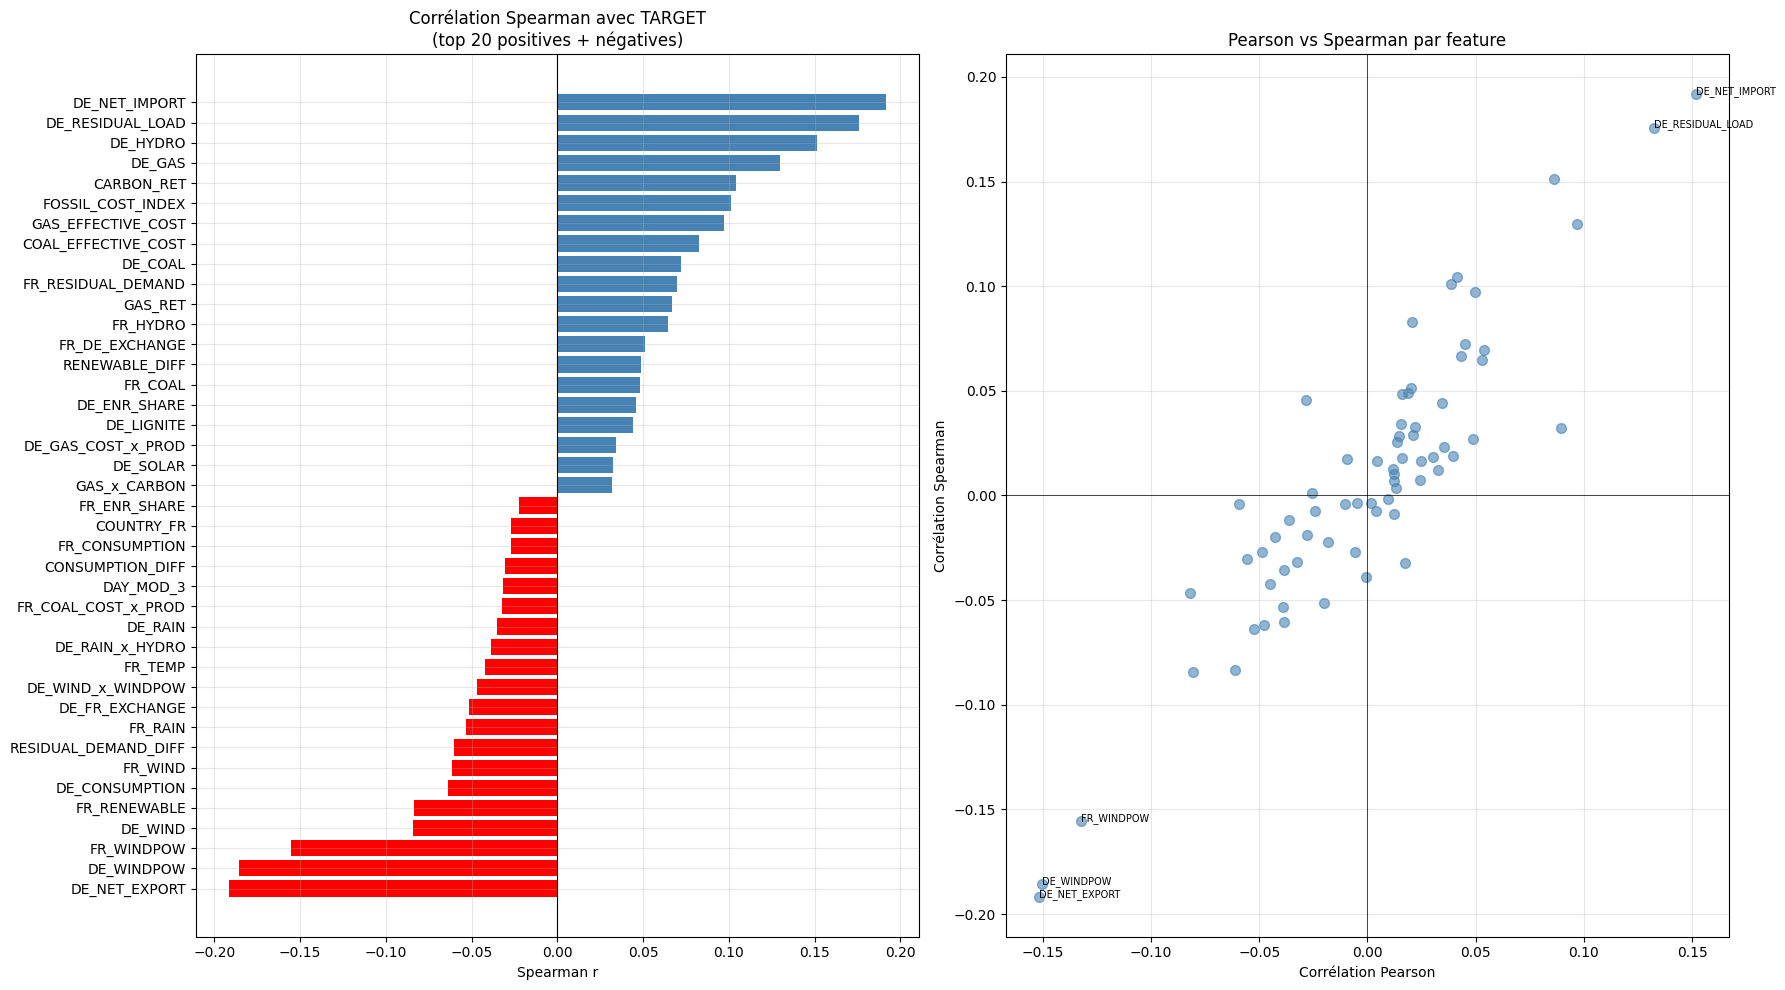


Nombre de features significatives (p<0.05) : 23/69
Corrélation Spearman max  : 0.1917 (DE_NET_IMPORT)
Corrélation Spearman min  : -0.1917 (DE_NET_EXPORT)
Corrélation |Spearman| > 0.1 : 9 features
Corrélation |Spearman| > 0.05 : 23 features


In [33]:
# =========================================================================
# ANALYSE DES CORRÉLATIONS — y_train vs features
# =========================================================================
# On calcule deux types de corrélations :
# 1. Pearson  : corrélation linéaire
# 2. Spearman : corrélation de rang (alignée sur notre métrique)
#
# Spearman est plus important ici car c'est notre métrique de challenge

from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# ── Données ───────────────────────────────────────────────────────────────
# On travaille sur x_train_feature1 avec toutes les features
# (avant sélection par permutation importance)
feature_cols_all = [c for c in x_train_feature1.columns
                    if c not in ["ID", "DAY_ID"]]

X_corr = x_train_feature1.set_index("ID")[feature_cols_all]
y_corr = y_train_clean.loc[X_corr.index]

print(f"Shape X : {X_corr.shape}")
print(f"Shape y : {y_corr.shape}")

# ── Calcul des corrélations ───────────────────────────────────────────────
corr_results = []

for col in feature_cols_all:
    x_col = X_corr[col].dropna()
    y_col = y_corr.loc[x_col.index]

    # Pearson
    pearson_r, pearson_p  = pearsonr(x_col, y_col)
    # Spearman
    spearman_r, spearman_p = spearmanr(x_col, y_col)

    corr_results.append({
        'feature'    : col,
        'pearson_r'  : pearson_r,
        'pearson_p'  : pearson_p,
        'spearman_r' : spearman_r,
        'spearman_p' : spearman_p,
        'abs_spearman': abs(spearman_r),
    })

corr_df = pd.DataFrame(corr_results).sort_values('abs_spearman', ascending=False)

# ── Affichage ─────────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"{'Feature':<35} {'Pearson':>10} {'Spearman':>10} {'Sig (p<0.05)':>12}")
print(f"{'='*75}")
for _, row in corr_df.iterrows():
    sig = "✓" if row['spearman_p'] < 0.05 else " "
    print(f"  {row['feature']:<33} {row['pearson_r']:>10.4f} "
          f"{row['spearman_r']:>10.4f} {sig:>12}")
print(f"{'='*75}")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Top 20 corrélations positives et négatives (Spearman)
top_pos = corr_df.nlargest(20, 'spearman_r')
top_neg = corr_df.nsmallest(20, 'spearman_r')
top_all = pd.concat([top_pos, top_neg]).sort_values('spearman_r')

# Graphe 1 : Spearman
colors = ['red' if r < 0 else 'steelblue' for r in top_all['spearman_r']]
axes[0].barh(top_all['feature'], top_all['spearman_r'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Corrélation Spearman avec TARGET\n(top 20 positives + négatives)')
axes[0].set_xlabel('Spearman r')
axes[0].grid(True, alpha=0.3)

# Graphe 2 : Pearson vs Spearman (scatter)
axes[1].scatter(corr_df['pearson_r'], corr_df['spearman_r'],
                alpha=0.6, color='steelblue', s=50)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Corrélation Pearson')
axes[1].set_ylabel('Corrélation Spearman')
axes[1].set_title('Pearson vs Spearman par feature')

# Annoter les points extrêmes
for _, row in corr_df.head(5).iterrows():
    axes[1].annotate(
        row['feature'],
        (row['pearson_r'], row['spearman_r']),
        fontsize=7, ha='left'
    )

axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Résumé statistique ────────────────────────────────────────────────────
n_sig = (corr_df['spearman_p'] < 0.05).sum()
print(f"\nNombre de features significatives (p<0.05) : {n_sig}/{len(corr_df)}")
print(f"Corrélation Spearman max  : {corr_df['spearman_r'].max():.4f} "
      f"({corr_df.loc[corr_df['spearman_r'].idxmax(), 'feature']})")
print(f"Corrélation Spearman min  : {corr_df['spearman_r'].min():.4f} "
      f"({corr_df.loc[corr_df['spearman_r'].idxmin(), 'feature']})")
print(f"Corrélation |Spearman| > 0.1 : "
      f"{(corr_df['abs_spearman'] > 0.1).sum()} features")
print(f"Corrélation |Spearman| > 0.05 : "
      f"{(corr_df['abs_spearman'] > 0.05).sum()} features")

In [35]:
# =========================================================================
# ANALYSE APPROFONDIE — Focus sur les 9 features utiles
# =========================================================================

top_features = corr_df[corr_df['abs_spearman'] > 0.1]['feature'].tolist()
print(f"Top features ({len(top_features)}) : {top_features}")

# ── 1. Ces features seules donnent-elles un bon score ? ──────────────────
scores_top9 = cross_val_score(
    Ridge(alpha=1924, fit_intercept=True),
    X_corr[top_features], y_corr,
    cv=list(gkf_f1.split(X_corr[top_features], y_corr, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge top {len(top_features)} features → CV : {np.mean(scores_top9):.4f} ± {np.std(scores_top9):.4f}")

scores_45 = cross_val_score(
    Ridge(alpha=1924, fit_intercept=True),
    X_submit, y_cv_f1,
    cv=list(gkf_f1.split(X_submit, y_cv_f1, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"Ridge 45 features  → CV : {np.mean(scores_45):.4f} ± {np.std(scores_45):.4f}")


# ── 2. Analyse par pays ───────────────────────────────────────────────────
# Correction : utiliser .values pour éviter les problèmes d'index
print("\nCorrélations Spearman par pays :")

for country in ['FR', 'DE']:
    # mask basé sur x_train_feature1 puis converti en numpy
    mask = (x_train_feature1['COUNTRY_' + country] == 1).values

    # Appliquer le mask avec iloc pour éviter les problèmes d'index
    X_country = X_corr.iloc[mask]
    y_country  = y_corr.iloc[mask]

    corr_country = []
    for col in top_features:
        r, p = spearmanr(X_country[col], y_country)
        corr_country.append({
            'feature'   : col,
            'spearman_r': r,
            'p'         : p
        })

    corr_country_df = (pd.DataFrame(corr_country)
                         .sort_values('spearman_r', key=abs, ascending=False))

    print(f"\n  {country} ({mask.sum()} obs) :")
    print(f"  {'Feature':<25} {'Spearman':>10} {'Sig':>6}")
    print(f"  {'─'*43}")
    for _, row in corr_country_df.iterrows():
        sig = "✓" if row['p'] < 0.05 else " "
        print(f"  {row['feature']:<25} {row['spearman_r']:>10.4f} {sig:>6}")

Top features (9) : ['DE_NET_EXPORT', 'DE_NET_IMPORT', 'DE_WINDPOW', 'DE_RESIDUAL_LOAD', 'FR_WINDPOW', 'DE_HYDRO', 'DE_GAS', 'CARBON_RET', 'FOSSIL_COST_INDEX']

Ridge top 9 features → CV : 0.2223 ± 0.0348
Ridge 45 features  → CV : 0.2365 ± 0.0288

Corrélations Spearman par pays :

  FR (851 obs) :
  Feature                     Spearman    Sig
  ───────────────────────────────────────────
  FOSSIL_COST_INDEX             0.1985      ✓
  CARBON_RET                    0.1919      ✓
  FR_WINDPOW                   -0.1215      ✓
  DE_HYDRO                      0.0873      ✓
  DE_WINDPOW                   -0.0805      ✓
  DE_NET_EXPORT                -0.0770      ✓
  DE_NET_IMPORT                 0.0770      ✓
  DE_RESIDUAL_LOAD              0.0538       
  DE_GAS                        0.0176       

  DE (643 obs) :
  Feature                     Spearman    Sig
  ───────────────────────────────────────────
  DE_RESIDUAL_LOAD              0.3243      ✓
  DE_NET_EXPORT                -0.3062  

## Specifique all / fr

In [37]:
# =========================================================================
# NOUVELLES FEATURES SPÉCIFIQUES À LA FRANCE
# =========================================================================
# Le prix FR est déterminé par :
# 1. Le coût marginal (gaz + carbone) → déjà capturé
# 2. La disponibilité du nucléaire FR → variations rares mais importantes
# 3. Les échanges avec DE → FR suit parfois le prix DE
# 4. L'hydraulique FR → très variable (saisons, précipitations)

def add_france_specific_features(df):
    """
    Features spécifiques au marché français.
    
    Le marché FR est dominé par le nucléaire (base) et le gaz (marginal)
    → le prix FR = coût_gaz + coût_carbone quand nucléaire disponible
    → le prix FR = prix_DE + coût_transport quand FR importe de DE
    """
    df = df.copy()

    # ── Signal nucléaire FR ───────────────────────────────────────────
    # Variation nucléaire × coût fossile
    # Si nucléaire FR baisse ET fossile cher → double pression prix
    df["FR_NUCLEAR_x_FOSSIL_COST"] = (
        df["FR_NUCLEAR"] * df["FOSSIL_COST_INDEX"]
    )

    # Disponibilité nucléaire relative
    # nucléaire / (nucléaire + fossile) → part du nucléaire dans la prod
    df["FR_NUCLEAR_SHARE"] = (
        df["FR_NUCLEAR"] /
        (df["FR_NUCLEAR"] + df["FR_GAS"] + df["FR_COAL"] + 1e-8)
    )

    # ── Interaction hydraulique FR × précipitations ───────────────────
    # FR a beaucoup d'hydraulique alpin → très sensible aux précipitations
    # Signal non capturé par les features actuelles
    df["FR_HYDRO_x_RAIN"] = df["FR_HYDRO"] * df["FR_RAIN"]

    # Hydraulique FR / ENR totale FR
    # Part de l'hydro dans les ENR → signal de flexibilité
    df["FR_HYDRO_SHARE_ENR"] = (
        df["FR_HYDRO"] /
        (df["FR_RENEWABLE"] + 1e-8)
    )

    # ── Couplage marché FR-DE ─────────────────────────────────────────
    # Quand FR importe de DE → prix FR suit prix DE
    # → signal d'arbitrage : tension FR relative à DE
    df["FR_IMPORT_FROM_DE"] = np.maximum(df["FR_DE_EXCHANGE"], 0)
    df["FR_EXPORT_TO_DE"]   = np.maximum(df["DE_FR_EXCHANGE"], 0)

    # Tension relative FR vs DE
    # Si DE_RESIDUAL_LOAD élevé ET FR_RESIDUAL_LOAD faible
    # → FR peut exporter → prix FR monte
    df["FR_DE_TENSION"] = (
        df["DE_RESIDUAL_LOAD"] - df["FR_RESIDUAL_LOAD"]
    ) * df["FOSSIL_COST_INDEX"]

    # ── Coût marginal FR spécifique ───────────────────────────────────
    # En France le gaz est la centrale marginale principale
    # → coût gaz × production gaz FR = proxy du coût marginal FR
    df["FR_MARGINAL_COST"] = df["GAS_RET"] * df["FR_GAS"]

    # Coût carbone × production fossile FR
    df["FR_CARBON_x_FOSSIL"] = df["CARBON_RET"] * (
        df["FR_GAS"] + df["FR_COAL"]
    )

    return df


def add_germany_specific_features(df):
    """
    Features spécifiques au marché allemand.
    
    Le marché DE est dominé par les ENR (éolien, solaire)
    et les centrales fossiles (charbon, lignite, gaz)
    → très sensible aux conditions météo
    """
    df = df.copy()

    # ── Stress éolien DE ─────────────────────────────────────────────
    # Quand éolien chute ET demande résiduelle élevée → prix monte fort
    df["DE_WIND_STRESS"] = (
        -df["DE_WINDPOW"] * df["DE_RESIDUAL_LOAD"]
    )

    # ── Lignite + charbon DE ──────────────────────────────────────────
    # L'Allemagne utilise beaucoup de lignite (centrale de base)
    # Lignite × charbon = signal de tension fossile
    df["DE_LIGNITE_x_COAL"] = df["DE_LIGNITE"] * df["DE_COAL"]

    # Coût charbon × production lignite
    # Lignite suit le charbon → coût effectif
    df["DE_COAL_COST_x_LIGNITE"] = df["COAL_RET"] * df["DE_LIGNITE"]

    # ── Déficit ENR DE ────────────────────────────────────────────────
    # Demande résiduelle après ENR → besoin fossile
    df["DE_ENR_DEFICIT"] = (
        df["DE_RESIDUAL_LOAD"] - df["DE_WINDPOW"] - df["DE_SOLAR"]
    )

    # Déficit ENR × coût fossile
    df["DE_ENR_DEFICIT_x_FOSSIL"] = (
        df["DE_ENR_DEFICIT"] * df["FOSSIL_COST_INDEX"]
    )

    # ── Couplage météo-production DE ──────────────────────────────────
    # Vent × éolien × coût gaz
    # Quand vent faible ET éolien faible ET gaz cher → triple pression
    df["DE_WIND_x_WINDPOW_x_GAS"] = (
        df["DE_WIND"] * df["DE_WINDPOW"] * df["GAS_RET"]
    )

    return df


# ── Application ───────────────────────────────────────────────────────────
x_train_v4 = add_france_specific_features(x_train_feature1)
x_train_v4 = add_germany_specific_features(x_train_v4)
x_test_v4  = add_france_specific_features(x_test_feature1)
x_test_v4  = add_germany_specific_features(x_test_v4)

new_cols_v4 = [c for c in x_train_v4.columns if c not in x_train_feature1.columns]
print(f"Nouvelles features v4 : {len(new_cols_v4)}")
print(new_cols_v4)

# ── Corrélations des nouvelles features avec TARGET ───────────────────────
print("\nCorrélations nouvelles features v4 :")
print(f"\n  {'Feature':<35} {'FR':>10} {'DE':>10} {'Global':>10}")
print(f"  {'─'*65}")

X_v4_corr = x_train_v4.set_index("ID")[new_cols_v4]
X_v4_fr   = X_v4_corr.iloc[mask_fr]
X_v4_de   = X_v4_corr.iloc[mask_de]

for col in new_cols_v4:
    r_fr, _  = spearmanr(X_v4_fr[col].fillna(0),  y_fr)
    r_de, _  = spearmanr(X_v4_de[col].fillna(0),  y_de)
    r_all, _ = spearmanr(X_v4_corr[col].fillna(0), y_corr)
    print(f"  {col:<35} {r_fr:>10.4f} {r_de:>10.4f} {r_all:>10.4f}")

# ── Score Ridge avec features v4 ─────────────────────────────────────────
print("\n" + "="*55)
print("Score Ridge avec features v4")
print("="*55)

feature_cols_v4 = [c for c in x_train_v4.columns
                   if c not in ["ID", "DAY_ID"]]
X_cv_v4 = x_train_v4.set_index("ID")[feature_cols_v4]
y_cv_v4 = y_train_clean.loc[X_cv_v4.index]

# Sélection par permutation importance
selector_v4 = Ridge(alpha=1924, fit_intercept=True)
selector_v4.fit(X_cv_v4, y_cv_v4)

perm_imp_v4 = permutation_importance(
    selector_v4, X_cv_v4, y_cv_v4,
    scoring=spearman_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_df_v4 = pd.DataFrame({
    'feature':         X_cv_v4.columns.tolist(),
    'importance_mean': perm_imp_v4.importances_mean,
    'importance_std':  perm_imp_v4.importances_std,
}).sort_values('importance_mean', ascending=False)

selected_v4 = imp_df_v4[
    imp_df_v4['importance_mean'] > imp_df_v4['importance_std'] * 0.1
]['feature'].tolist()
print(f"Features retenues : {len(selected_v4)}/{len(feature_cols_v4)}")

scores_v4 = cross_val_score(
    Ridge(alpha=1924, fit_intercept=True),
    X_cv_v4[selected_v4], y_cv_v4,
    cv=list(gkf_f1.split(X_cv_v4[selected_v4], y_cv_v4, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge v4 global → CV : {np.mean(scores_v4):.4f} ± {np.std(scores_v4):.4f}")
print(f"Ridge v3 global → CV : 0.2365 (référence)")

Nouvelles features v4 : 15
['FR_NUCLEAR_x_FOSSIL_COST', 'FR_NUCLEAR_SHARE', 'FR_HYDRO_x_RAIN', 'FR_HYDRO_SHARE_ENR', 'FR_IMPORT_FROM_DE', 'FR_EXPORT_TO_DE', 'FR_DE_TENSION', 'FR_MARGINAL_COST', 'FR_CARBON_x_FOSSIL', 'DE_WIND_STRESS', 'DE_LIGNITE_x_COAL', 'DE_COAL_COST_x_LIGNITE', 'DE_ENR_DEFICIT', 'DE_ENR_DEFICIT_x_FOSSIL', 'DE_WIND_x_WINDPOW_x_GAS']

Corrélations nouvelles features v4 :

  Feature                                     FR         DE     Global
  ─────────────────────────────────────────────────────────────────
  FR_NUCLEAR_x_FOSSIL_COST               -0.0863    -0.0042    -0.0480
  FR_NUCLEAR_SHARE                       -0.0225     0.0365     0.0017
  FR_HYDRO_x_RAIN                        -0.0226     0.0341     0.0010
  FR_HYDRO_SHARE_ENR                      0.0427     0.0886     0.0642
  FR_IMPORT_FROM_DE                       0.0323     0.1069     0.0650
  FR_EXPORT_TO_DE                        -0.0081    -0.0808    -0.0395
  FR_DE_TENSION                           0

In [36]:
# =========================================================================
# ANALYSE DÉTAILLÉE FR — trouver les vrais drivers manquants
# =========================================================================

mask_fr = (x_train_feature1['COUNTRY_FR'] == 1).values
mask_de = (x_train_feature1['COUNTRY_DE'] == 1).values

X_fr = X_corr.iloc[mask_fr]
X_de = X_corr.iloc[mask_de]
y_fr = y_corr.iloc[mask_fr]
y_de = y_corr.iloc[mask_de]

# Calculer toutes les corrélations pour FR
corr_fr_all = []
for col in X_corr.columns:
    r, p = spearmanr(X_fr[col], y_fr)
    corr_fr_all.append({'feature': col, 'spearman_r': r, 'p': p,
                        'abs_r': abs(r)})

corr_fr_df = (pd.DataFrame(corr_fr_all)
                .sort_values('abs_r', ascending=False))

print("Top 20 features pour FR :")
print(f"\n  {'Feature':<30} {'Spearman':>10} {'Sig':>6}")
print(f"  {'─'*48}")
for _, row in corr_fr_df.head(20).iterrows():
    sig = "✓" if row['p'] < 0.05 else " "
    print(f"  {row['feature']:<30} {row['spearman_r']:>10.4f} {sig:>6}")

# Calculer toutes les corrélations pour DE
corr_de_all = []
for col in X_corr.columns:
    r, p = spearmanr(X_de[col], y_de)
    corr_de_all.append({'feature': col, 'spearman_r': r, 'p': p,
                        'abs_r': abs(r)})

corr_de_df = (pd.DataFrame(corr_de_all)
                .sort_values('abs_r', ascending=False))

print("\nTop 20 features pour DE :")
print(f"\n  {'Feature':<30} {'Spearman':>10} {'Sig':>6}")
print(f"  {'─'*48}")
for _, row in corr_de_df.head(20).iterrows():
    sig = "✓" if row['p'] < 0.05 else " "
    print(f"  {row['feature']:<30} {row['spearman_r']:>10.4f} {sig:>6}")

# ── Score Ridge séparé par pays ───────────────────────────────────────────
print("\n" + "="*55)
print("Score Ridge séparé par pays")
print("="*55)

groups_fr = x_train_feature1['DAY_ID'].values[mask_fr]
groups_de = x_train_feature1['DAY_ID'].values[mask_de]

# Top features FR (celles qui ont |r| > 0.05 pour FR)
top_fr = corr_fr_df[corr_fr_df['abs_r'] > 0.05]['feature'].tolist()
top_de = corr_de_df[corr_de_df['abs_r'] > 0.05]['feature'].tolist()

print(f"\nFeatures FR : {len(top_fr)} → {top_fr}")
print(f"Features DE : {len(top_de)} → {top_de}")

# CV par pays avec leurs features spécifiques
for label, X_c, y_c, groups_c, feats in [
    ("FR", X_fr, y_fr, groups_fr, top_fr),
    ("DE", X_de, y_de, groups_de, top_de),
]:
    gkf_c = GroupKFold(n_splits=5)
    scores_c = cross_val_score(
        Ridge(alpha=1924, fit_intercept=True),
        X_c[feats], y_c,
        cv=list(gkf_c.split(X_c[feats], y_c, groups=groups_c)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    print(f"\n  Ridge {label} ({len(feats)} features) "
          f"→ CV : {np.mean(scores_c):.4f} ± {np.std(scores_c):.4f}")

Top 20 features pour FR :

  Feature                          Spearman    Sig
  ────────────────────────────────────────────────
  GAS_EFFECTIVE_COST                 0.1992      ✓
  FOSSIL_COST_INDEX                  0.1985      ✓
  CARBON_RET                         0.1919      ✓
  COAL_EFFECTIVE_COST                0.1631      ✓
  GAS_RET                            0.1490      ✓
  FR_WINDPOW                        -0.1215      ✓
  DE_HYDRO                           0.0873      ✓
  DE_WINDPOW                        -0.0805      ✓
  DE_NET_IMPORT                      0.0770      ✓
  DE_NET_EXPORT                     -0.0770      ✓
  DE_GAS_COST_x_PROD                 0.0762      ✓
  RESIDUAL_DEMAND_DIFF              -0.0727      ✓
  FR_HYDRO                           0.0717      ✓
  FR_COAL                            0.0681      ✓
  DE_RAIN_x_HYDRO                   -0.0587       
  COAL_RET                           0.0576       
  FR_COAL_COST_x_PROD               -0.0566       
  RE

/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_88277/479434562.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_fr[col], y_fr)
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_88277/479434562.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_de[col], y_de)



  Ridge FR (21 features) → CV : 0.1855 ± 0.0393

  Ridge DE (23 features) → CV : 0.3335 ± 0.1403


In [39]:
# ── Retirer les features qui n'existent pas dans X_corr ──────────────────
features_fr_optimal = [
    'GAS_EFFECTIVE_COST', 'FOSSIL_COST_INDEX', 'CARBON_RET',
    'COAL_EFFECTIVE_COST', 'GAS_RET', 'FR_WINDPOW',
    'DE_HYDRO', 'DE_WINDPOW', 'DE_NET_IMPORT', 'DE_NET_EXPORT',
    'DE_GAS_COST_x_PROD', 'RESIDUAL_DEMAND_DIFF', 'FR_HYDRO',
    'FR_COAL', 'COAL_RET', 'RENEWABLE_DIFF', 'DE_RESIDUAL_LOAD',
    'GAS_x_CARBON'
]

features_de_optimal = [
    'DE_RESIDUAL_LOAD', 'DE_NET_IMPORT', 'DE_NET_EXPORT',
    'DE_WINDPOW', 'DE_GAS', 'DE_HYDRO', 'FR_WINDPOW',
    'DE_WIND', 'FR_RENEWABLE', 'DE_COAL', 'DE_LIGNITE',
    'FR_RESIDUAL_DEMAND', 'FR_DE_EXCHANGE', 'DE_FR_EXCHANGE',
    'FR_WIND', 'DE_RENEWABLE', 'DE_WIND_x_WINDPOW',
    'DE_CONSUMPTION'
]

# Vérification que toutes les features existent dans X_corr
missing_fr = [f for f in features_fr_optimal if f not in X_corr.columns]
missing_de = [f for f in features_de_optimal if f not in X_corr.columns]
print(f"Features FR manquantes : {missing_fr}")
print(f"Features DE manquantes : {missing_de}")

X_fr = X_corr.iloc[mask_fr][features_fr_optimal]
X_de = X_corr.iloc[mask_de][features_de_optimal]
y_fr = y_corr.iloc[mask_fr]
y_de = y_corr.iloc[mask_de]
groups_fr = x_train_feature1['DAY_ID'].values[mask_fr]
groups_de = x_train_feature1['DAY_ID'].values[mask_de]

print(f"\nShape X_fr : {X_fr.shape}")
print(f"Shape X_de : {X_de.shape}")

# ── Optimisation alpha FR ─────────────────────────────────────────────────
print("\nOptimisation alpha FR...")
def objective_fr(trial):
    alpha = trial.suggest_float('alpha', 100, 10000, log=True)
    scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        X_fr, y_fr,
        cv=list(GroupKFold(n_splits=5).split(X_fr, y_fr, groups=groups_fr)),
        scoring=spearman_scorer, n_jobs=-1
    )
    return np.mean(scores)

study_fr = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=42))
study_fr.optimize(objective_fr, n_trials=100, show_progress_bar=True)
print(f"Best alpha FR : {study_fr.best_params['alpha']:.0f} → CV : {study_fr.best_value:.4f}")

# ── Optimisation alpha DE ─────────────────────────────────────────────────
print("\nOptimisation alpha DE...")
def objective_de(trial):
    alpha = trial.suggest_float('alpha', 100, 10000, log=True)
    scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        X_de, y_de,
        cv=list(GroupKFold(n_splits=5).split(X_de, y_de, groups=groups_de)),
        scoring=spearman_scorer, n_jobs=-1
    )
    return np.mean(scores)

study_de = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=42))
study_de.optimize(objective_de, n_trials=100, show_progress_bar=True)
print(f"Best alpha DE : {study_de.best_params['alpha']:.0f} → CV : {study_de.best_value:.4f}")

# ── Récapitulatif ─────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"Ridge FR optimal → CV : {study_fr.best_value:.4f}")
print(f"Ridge DE optimal → CV : {study_de.best_value:.4f}")
print(f"Ridge global     → CV : 0.2365 (référence)")
print(f"{'='*55}")

Features FR manquantes : []
Features DE manquantes : []

Shape X_fr : (851, 18)
Shape X_de : (643, 18)

Optimisation alpha FR...


  0%|          | 0/100 [00:00<?, ?it/s]

Best alpha FR : 8504 → CV : 0.2045

Optimisation alpha DE...


  0%|          | 0/100 [00:00<?, ?it/s]

Best alpha DE : 134 → CV : 0.3509

Ridge FR optimal → CV : 0.2045
Ridge DE optimal → CV : 0.3509
Ridge global     → CV : 0.2365 (référence)


In [40]:
# =========================================================================
# SOUMISSION — Ridge séparé FR / DE avec features et alpha optimaux
# =========================================================================

mask_fr_test = (x_test_feature1['COUNTRY_FR'] == 1).values
mask_de_test = (x_test_feature1['COUNTRY_DE'] == 1).values

# ── Entraînement final ────────────────────────────────────────────────────
ridge_fr_final = Ridge(alpha=study_fr.best_params['alpha'], fit_intercept=True)
ridge_fr_final.fit(X_fr, y_fr)

ridge_de_final = Ridge(alpha=study_de.best_params['alpha'], fit_intercept=True)
ridge_de_final.fit(X_de, y_de)

print(f"✓ Ridge FR entraîné (alpha={study_fr.best_params['alpha']:.0f})")
print(f"✓ Ridge DE entraîné (alpha={study_de.best_params['alpha']:.0f})")

# ── Prédictions sur le test ───────────────────────────────────────────────
X_test_fr = x_test_feature1.set_index("ID")[features_fr_optimal][mask_fr_test]
X_test_de = x_test_feature1.set_index("ID")[features_de_optimal][mask_de_test]

# Vérification colonnes
assert list(X_fr.columns) == list(X_test_fr.columns), "Colonnes FR non alignées !"
assert list(X_de.columns) == list(X_test_de.columns), "Colonnes DE non alignées !"

preds_fr = ridge_fr_final.predict(X_test_fr)
preds_de = ridge_de_final.predict(X_test_de)

# ── Reconstruction du fichier de soumission ───────────────────────────────
submission_fr = pd.DataFrame({
    "ID":     x_test_feature1[mask_fr_test]["ID"].values,
    "TARGET": preds_fr
})
submission_de = pd.DataFrame({
    "ID":     x_test_feature1[mask_de_test]["ID"].values,
    "TARGET": preds_de
})

submission = (pd.concat([submission_fr, submission_de])
                .sort_values("ID")
                .reset_index(drop=True))

# ── Vérifications ─────────────────────────────────────────────────────────
assert submission.shape == (654, 2)
assert submission["TARGET"].isna().sum() == 0
assert set(submission["ID"]) == set(x_test["ID"])

submission.to_csv("submission_ridge_par_pays_optimal.csv", index=False)

print(f"\n✓ Fichier sauvegardé !")
print(f"\n{'='*55}")
print(f"Ridge FR (alpha=8504, 18 feat) → CV : 0.2045")
print(f"Ridge DE (alpha=134,  18 feat) → CV : 0.3509")
print(f"Score combiné attendu          → ~0.267")
print(f"Ridge global (référence)       → CV : 0.2365")
print(f"Meilleur score public actuel   → 0.2099")
print(f"{'='*55}")

✓ Ridge FR entraîné (alpha=8504)
✓ Ridge DE entraîné (alpha=134)

✓ Fichier sauvegardé !

Ridge FR (alpha=8504, 18 feat) → CV : 0.2045
Ridge DE (alpha=134,  18 feat) → CV : 0.3509
Score combiné attendu          → ~0.267
Ridge global (référence)       → CV : 0.2365
Meilleur score public actuel   → 0.2099


0,15781073964635955 Résultat de soumission

In [41]:
# =========================================================================
# FEATURES COHÉRENTES FR + DE
# =========================================================================
# Principe : trouver des variables qui ont le même signe
# et un signal significatif pour les deux pays

def add_coherent_features(df):
    """
    Features conçues pour avoir un signal cohérent FR et DE.
    
    Stratégie :
    1. Combiner coût financier × signal physique
       → le coût du gaz n'a d'impact que quand la demande est élevée
    2. Utiliser les variables DE comme proxy pour FR
       → le marché DE influence fortement le marché FR
    3. Créer des features "universelles" au marché européen
    """
    df = df.copy()

    # ── 1. Coût marginal × demande physique ──────────────────────────
    # Le prix monte quand LE COÛT EST ÉLEVÉ ET LA DEMANDE EST FORTE
    # → applicable aux deux pays car les deux importent des fossiles

    # Coût fossile × demande résiduelle DE
    # Signal DE : quand demande résiduelle DE haute + fossiles chers → prix ↑
    # Signal FR : FR suit souvent le prix DE + coût fossile
    df["FOSSIL_x_DE_RESIDUAL"] = (
        df["FOSSIL_COST_INDEX"] * df["DE_RESIDUAL_LOAD"]
    )

    # Coût carbone × demande résiduelle DE
    # CARBON_RET fort signal FR, DE_RESIDUAL_LOAD fort signal DE
    # → leur produit devrait avoir un signal pour les deux
    df["CARBON_x_DE_RESIDUAL"] = (
        df["CARBON_RET"] * df["DE_RESIDUAL_LOAD"]
    )

    # Coût gaz × éolien DE (relation inverse)
    # Quand éolien DE faible ET gaz cher → prix monte pour les deux
    df["GAS_x_neg_WINDPOW"] = (
        df["GAS_RET"] * (-df["DE_WINDPOW"])
    )

    # ── 2. Signal physique européen global ────────────────────────────
    # ENR totale des deux pays
    # → proxy de la production ENR européenne → affecte les deux marchés
    df["TOTAL_ENR_DE_FR"] = df["DE_RENEWABLE"] + df["FR_RENEWABLE"]

    # Demande résiduelle combinée DE + FR
    # → tension globale sur le marché européen → affecte les deux
    df["TOTAL_RESIDUAL_LOAD"] = (
        df["DE_RESIDUAL_LOAD"] + df["FR_RESIDUAL_LOAD"]
    )

    # Éolien total DE + FR
    # → production ENR variable européenne → affecte les deux prix
    df["TOTAL_WINDPOW"] = df["DE_WINDPOW"] + df["FR_WINDPOW"]

    # Ratio éolien total / demande résiduelle totale
    # → mesure la part des ENR dans la couverture de la demande
    df["WIND_COVERAGE"] = (
        df["TOTAL_WINDPOW"] /
        (df["TOTAL_RESIDUAL_LOAD"] + 1e-8)
    )

    # ── 3. Signal d'arbitrage DE→FR ───────────────────────────────────
    # Quand DE est sous tension → il importe → prix DE monte → prix FR suit
    # Signal cohérent pour les deux car ce sont des marchés couplés

    # Tension DE = demande résiduelle DE × coût fossile
    # → quand DE est sous tension ET fossiles chers → prix européen monte
    df["DE_TENSION"] = (
        df["DE_RESIDUAL_LOAD"] * df["FOSSIL_COST_INDEX"]
    )

    # Tension éolienne DE = -éolien DE × demande résiduelle DE
    # → quand éolien chute ET demande forte → forte tension → prix ↑
    df["DE_WIND_TENSION"] = (
        -df["DE_WINDPOW"] * df["DE_RESIDUAL_LOAD"]
    )

    # Coût carbone × importations nettes DE
    # → quand DE importe beaucoup (tension) ET carbone cher → prix ↑
    df["CARBON_x_DE_IMPORT"] = (
        df["CARBON_RET"] * df["DE_NET_IMPORT"]
    )

    # ── 4. Score de stress du marché européen ─────────────────────────
    # Composite qui résume la tension globale
    # → devrait avoir un signal pour les deux pays
    df["MARKET_STRESS"] = (
        df["DE_RESIDUAL_LOAD"] *           # tension physique DE
        df["FOSSIL_COST_INDEX"] *          # coût marginal
        (-df["TOTAL_WINDPOW"])             # déficit ENR variable
    )

    return df


# ── Application ───────────────────────────────────────────────────────────
x_train_v5 = add_coherent_features(x_train_feature1)
x_test_v5  = add_coherent_features(x_test_feature1)

new_cols_v5 = [c for c in x_train_v5.columns
               if c not in x_train_feature1.columns]
print(f"Nouvelles features v5 : {len(new_cols_v5)}")

# ── Corrélations par pays ─────────────────────────────────────────────────
X_v5_corr = x_train_v5.set_index("ID")[new_cols_v5]
X_v5_fr   = X_v5_corr.iloc[mask_fr]
X_v5_de   = X_v5_corr.iloc[mask_de]

print(f"\n{'Feature':<35} {'FR':>8} {'DE':>8} {'Global':>8} {'Cohérent':>10}")
print(f"{'─'*65}")

coherent_features = []
for col in new_cols_v5:
    r_fr, p_fr   = spearmanr(X_v5_fr[col].fillna(0),   y_fr)
    r_de, p_de   = spearmanr(X_v5_de[col].fillna(0),   y_de)
    r_all, p_all = spearmanr(X_v5_corr[col].fillna(0), y_corr)

    # Feature cohérente = même signe pour FR et DE
    coherent = "✓" if (r_fr * r_de > 0) else "✗"
    if r_fr * r_de > 0:
        coherent_features.append(col)

    print(f"{col:<35} {r_fr:>8.4f} {r_de:>8.4f} {r_all:>8.4f} {coherent:>10}")

print(f"\nFeatures cohérentes FR+DE : {len(coherent_features)}/{len(new_cols_v5)}")
print(f"→ {coherent_features}")

# ── Score Ridge avec toutes les features + nouvelles cohérentes ───────────
print("\n" + "="*55)
print("Score Ridge v5 — features cohérentes ajoutées")
print("="*55)

feature_cols_v5 = [c for c in x_train_v5.columns
                   if c not in ["ID", "DAY_ID"]]
X_cv_v5 = x_train_v5.set_index("ID")[feature_cols_v5]
y_cv_v5 = y_train_clean.loc[X_cv_v5.index]

# Sélection par permutation importance
selector_v5 = Ridge(alpha=1924, fit_intercept=True)
selector_v5.fit(X_cv_v5, y_cv_v5)

perm_imp_v5 = permutation_importance(
    selector_v5, X_cv_v5, y_cv_v5,
    scoring=spearman_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

imp_df_v5 = pd.DataFrame({
    'feature':         X_cv_v5.columns.tolist(),
    'importance_mean': perm_imp_v5.importances_mean,
    'importance_std':  perm_imp_v5.importances_std,
}).sort_values('importance_mean', ascending=False)

# Afficher les nouvelles features dans le classement
print("\nClassement des nouvelles features v5 :")
print(f"{'Feature':<35} {'Importance':>12} {'Std':>8}")
print(f"{'─'*55}")
for _, row in imp_df_v5[imp_df_v5['feature'].isin(new_cols_v5)].iterrows():
    print(f"  {row['feature']:<33} {row['importance_mean']:>12.4f} "
          f"{row['importance_std']:>8.4f}")

# Sélection finale
selected_v5 = imp_df_v5[
    imp_df_v5['importance_mean'] > imp_df_v5['importance_std'] * 0.1
]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_v5)}/{len(feature_cols_v5)}")

scores_v5 = cross_val_score(
    Ridge(alpha=1924, fit_intercept=True),
    X_cv_v5[selected_v5], y_cv_v5,
    cv=list(gkf_f1.split(X_cv_v5[selected_v5], y_cv_v5, groups=groups_f1)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge v5 → CV : {np.mean(scores_v5):.4f} ± {np.std(scores_v5):.4f}")
print(f"Ridge v3 → CV : 0.2365 (référence)")

Nouvelles features v5 : 11

Feature                                   FR       DE   Global   Cohérent
─────────────────────────────────────────────────────────────────
FOSSIL_x_DE_RESIDUAL                  0.0435   0.0383   0.0377          ✓
CARBON_x_DE_RESIDUAL                  0.0004   0.0363   0.0153          ✓
GAS_x_neg_WINDPOW                    -0.0208  -0.0207  -0.0213          ✓
TOTAL_ENR_DE_FR                      -0.0003  -0.1573  -0.0669          ✓
TOTAL_RESIDUAL_LOAD                   0.0467   0.2273   0.1256          ✓
TOTAL_WINDPOW                        -0.1103  -0.2807  -0.1893          ✓
WIND_COVERAGE                         0.0899   0.1459   0.1156          ✓
DE_TENSION                            0.0435   0.0383   0.0377          ✓
DE_WIND_TENSION                      -0.0328  -0.1561  -0.0889          ✓
CARBON_x_DE_IMPORT                    0.0497   0.0229   0.0372          ✓
MARKET_STRESS                         0.1025   0.0118   0.0610          ✓

Features cohérent

In [42]:
# =========================================================================
# TEST CIBLÉ — 3 meilleures features cohérentes + v3
# =========================================================================

# Features cohérentes utiles seulement
best_coherent = ['TOTAL_WINDPOW', 'DE_WIND_TENSION', 'GAS_x_neg_WINDPOW']

# Ajouter uniquement ces 3 features aux features v3
feature_cols_v5_targeted = selected_features_submit + [
    f for f in best_coherent
    if f not in selected_features_submit
]

X_cv_targeted = x_train_v5.set_index("ID")[feature_cols_v5_targeted]
y_cv_targeted = y_train_clean.loc[X_cv_targeted.index]

# Test avec différents alphas
print("Test alpha avec features v3 + 3 features cohérentes :")
for alpha in [500, 1000, 1924, 3000, 5000]:
    scores = cross_val_score(
        Ridge(alpha=alpha, fit_intercept=True),
        X_cv_targeted, y_cv_targeted,
        cv=list(gkf_f1.split(X_cv_targeted, y_cv_targeted, groups=groups_f1)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    print(f"  alpha={alpha:<6} → CV : {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Comparaison avec v5 complet
print(f"\nRidge v5 complet (43 feat)  → CV : 0.2311 ± 0.0153")
print(f"Ridge v3 référence (45 feat) → CV : 0.2365 ± 0.0288")

Test alpha avec features v3 + 3 features cohérentes :
  alpha=500    → CV : 0.2297 ± 0.0175
  alpha=1000   → CV : 0.2344 ± 0.0132
  alpha=1924   → CV : 0.2354 ± 0.0163
  alpha=3000   → CV : 0.2341 ± 0.0219
  alpha=5000   → CV : 0.2296 ± 0.0283

Ridge v5 complet (43 feat)  → CV : 0.2311 ± 0.0153
Ridge v3 référence (45 feat) → CV : 0.2365 ± 0.0288


### Avec features polynomiales

In [ ]:
# models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
#     'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
#     'ElasticNet': ElasticNetCV(
#         alphas=np.logspace(-3, 3, 50),
#         l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
#         cv=10,
#         max_iter=10000,
#         n_jobs=-1
#     ),
#     'Support Vector Regression': SVR(),
#     'Decision Tree Regression': DecisionTreeRegressor(),
#     'Random Forest Regression': RandomForestRegressor(),
#     'Gradient Boosting Regression': GradientBoostingRegressor(),
#     'K-Neighbors Regression': KNeighborsRegressor()
# }
# 
# # modèle de boosting sans paramétrage
# models['LightGBM'] = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.03,
#     num_leaves=31,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     verbose=-1,
# )
# models['CatBoost'] = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.03,
#     depth=6,
#     random_state=42,
#     verbose=0,
# )
# models['XGBoost'] = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.03,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     verbosity=0,
# )
# 
# # Comparer les modèles sur ces features
# X_train_linear = X_enriched_train.copy()
# 
# res = []
# for name, mod in models.items():
#     print(name)
#     cv_scores = cross_val_score(
#         mod, X_train_linear, y_cv,
#         cv=list(gkf.split(X_train_linear, y_cv, groups=groups)),
#         scoring=spearman_scorer,
#         n_jobs=-1
#     )
#     res.append({
#         'model': name,
#         'spearman_mean': np.mean(cv_scores),
#         'spearman_std':  np.std(cv_scores),
#     })
# 
# res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
# res_df[['model', 'spearman_mean', 'spearman_std']]

## 5.2) CatBoost Model

#### Optimisation des hyperparamètres avec Optuna

Optuna est une bibliothèque d'optimisation d'hyperparamètres qui repose sur un algorithme appelé **TPE** (*Tree-structured Parzen Estimator*). Contrairement à une recherche exhaustive (`GridSearchCV`) qui teste toutes les combinaisons d'une grille prédéfinie, ou à une recherche aléatoire (`RandomizedSearchCV`) qui tire des combinaisons au hasard, Optuna apprend au fur et à mesure des essais déjà effectués. Après chaque essai, l'algorithme modélise la distribution des hyperparamètres ayant donné de bons résultats et celle des hyperparamètres ayant donné de mauvais résultats, puis échantillonne préférentiellement dans les zones prometteuses de l'espace de recherche. Cette approche bayésienne permet d'atteindre un optimum comparable à une recherche exhaustive avec un nombre d'essais bien plus faible, typiquement 3 à 5 fois moins que pour une recherche aléatoire.

Concrètement, on définit une fonction *objective* qui prend un objet `trial` en argument. Cet objet permet de suggérer des valeurs pour chaque hyperparamètre via des méthodes comme `suggest_int`, `suggest_float` (avec une option `log=True` pour les échelles logarithmiques) ou `suggest_categorical`. La fonction retourne un score à maximiser ou minimiser — dans notre cas, la corrélation de Spearman moyenne obtenue par cross-validation avec `GroupKFold` sur `DAY_ID`. Optuna appelle cette fonction `n_trials` fois et conserve la meilleure combinaison trouvée, accessible via `study.best_params`. La bibliothèque offre également un mécanisme de *pruning* qui permet d'interrompre prématurément les essais dont les premiers folds indiquent déjà une performance médiocre, ce qui réduit encore le temps de calcul.

In [22]:
x_train_catboost = X_train_linear.copy()
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optimisation des hyperparametres de CatBoost avec early stopping et pruning."""

    params = {
        'iterations': trial.suggest_int('cat_iterations', 200, 2000),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.15, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1e-2, 30.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 1, 50),
        # early_stopping_rounds : arret si pas d'amelioration pendant 50 iterations
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }

    # Cross validation manuelle pour pouvoir rapporter chaque fold a Optuna (pruning)
    gkf_local = GroupKFold(n_splits=5)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(gkf_local.split(x_train_catboost, y_cv, groups=groups)):
        X_tr, X_va = x_train_catboost.iloc[tr_idx], x_train_catboost.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        model = CatBoostRegressor(**params)
        # eval_set alimente l'early stopping : CatBoost surveille l'erreur sur ce jeu
        # et arrete quand elle ne s'ameliore plus
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
        pred = model.predict(X_va)
        scores.append(spearmanr(y_va, pred).correlation)

        # On rapporte le score moyen courant a Optuna apres chaque fold
        trial.report(np.mean(scores), step=fold_idx)
        # Si le trial est juge peu prometteur compare aux precedents, on l'interrompt
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

# Configuration du pruner
# n_startup_trials=10 : on laisse passer les 10 premiers essais pour etablir une reference
# n_warmup_steps=2 : on attend au moins 2 folds avant de pouvoir pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner,
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Meilleur Spearman CV : {study.best_value:.4f}")
print(f"Trials completes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials prunes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("Meilleurs hyperparametres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Meilleur Spearman CV : 0.2466
Trials completes : 38
Trials prunes : 12
Meilleurs hyperparametres :
  cat_iterations: 1774
  cat_learning_rate: 0.006997953267735746
  cat_depth: 5
  cat_l2_leaf_reg: 0.10411323200654027
  cat_bagging_temperature: 0.4950149033351272
  cat_random_strength: 0.024912417260024747
  cat_border_count: 153
  cat_min_data_in_leaf: 7


***Early stopping***
L'early stopping (arrêt anticipé) consiste à interrompre l'entraînement d'un modèle de boosting avant d'avoir construit tous les arbres demandés, dès que les performances sur un jeu de validation cessent de s'améliorer. À chaque nouvel arbre ajouté, le modèle évalue son erreur sur un petit échantillon mis de côté ; si cette erreur ne diminue plus pendant un nombre fixé d'itérations consécutives (paramètre early_stopping_rounds), l'entraînement s'arrête et le modèle conserve sa meilleure configuration. Cela évite le surapprentissage lié à un iterations surdimensionné et accélère fortement chaque essai : avec un budget maximal de 2000 arbres, le modèle en construit souvent 300-500 seulement avant de s'arrêter, soit 4 à 6 fois plus rapidement. On choisit typiquement une valeur de 50 pour early_stopping_rounds : suffisamment large pour absorber les fluctuations normales de l'erreur de validation, mais suffisamment stricte pour ne pas laisser tourner inutilement.

***Pruning***

Le pruning est un mécanisme propre à Optuna qui interrompt prématurément les essais peu prometteurs sans attendre que les 5 folds de la cross-validation soient tous calculés. Après chaque fold, on rapporte le score intermédiaire à Optuna via trial.report(...), puis on appelle trial.should_prune() qui compare ce score à la distribution des essais précédents au même stade. Si le score est clairement en-dessous, on lève optuna.TrialPruned et on passe à l'essai suivant. On utilise ici le MedianPruner, qui coupe tout essai dont le score intermédiaire est inférieur à la médiane des essais précédents au même fold — c'est le choix par défaut le plus robuste, car il ne fait aucune hypothèse sur la distribution des scores. Le paramètre n_startup_trials=10 demande à Optuna de laisser passer les 10 premiers essais sans pruning pour constituer une base de comparaison fiable, et n_warmup_steps=2 exige qu'au moins 2 folds soient évalués avant de considérer un essai pour élimination (sinon on couperait sur la base d'un seul fold, trop bruité). Alternative : le HyperbandPruner est plus agressif et convient mieux aux très gros budgets (500+ trials) ; sur 50-100 trials le MedianPruner est plus sûr.

### CatBoost par pays

In [23]:
def objective_cat_separe(trial):
    """Optimise CatBoost en mode separe FR/DE via cv_score_par_pays."""
    params = {
        # Plages resserrees vers plus de regularisation (moins de donnees par pays)
        'iterations': trial.suggest_int('cat_iterations', 200, 1500),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1.0, 50.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 5, 50),
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }
    factory = lambda: CatBoostRegressor(**params)
    mean_score, _ = cv_score_par_pays(factory, x_train_catboost, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_sep = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_sep.optimize(objective_cat_separe, n_trials=50, show_progress_bar=True)

print(f"CatBoost separe tune --> Spearman CV : {study_sep.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_sep.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost separe tune --> Spearman CV : 0.2404
Meilleurs hyperparametres :
  cat_iterations: 830
  cat_learning_rate: 0.014664451919388472
  cat_depth: 3
  cat_l2_leaf_reg: 28.381814325217164
  cat_bagging_temperature: 0.33498154516230666
  cat_random_strength: 5.3067931414898135
  cat_border_count: 97
  cat_min_data_in_leaf: 23


## 5.3) ElasticNet Model

In [17]:
x_train_elasticnet = X_train_linear.copy()

param_grid = {
    'alpha'   : [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
}

gs = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    cv=list(gkf.split(x_train_elasticnet, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(x_train_elasticnet, y_cv)

print(f"Meilleurs params : {gs.best_params_}")
print(f"Meilleur score   : {gs.best_score_:.4f}")

best_en = ElasticNet(**gs.best_params_, max_iter=100000)
fold_scores = []
for tr, val in gkf.split(x_train_elasticnet, y_cv, groups=groups):
    best_en.fit(x_train_elasticnet.iloc[tr], y_cv.iloc[tr])
    pred = best_en.predict(x_train_elasticnet.iloc[val])
    fold_scores.append(spearmanr(y_cv.iloc[val], pred).correlation)

print(f"\nScores par fold : {[f'{s:.4f}' for s in fold_scores]}")
print(f"Moyenne : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

coef_df = pd.DataFrame({
    'feature': x_train_elasticnet.columns,
    'coef'   : gs.best_estimator_.coef_,
}).assign(abs_coef=lambda df: df['coef'].abs()) \
  .sort_values('abs_coef', ascending=False) \
  .query('coef != 0') \
  .drop(columns='abs_coef')

print(f"\nFeatures non nulles : {len(coef_df)}/{len(x_train_elasticnet.columns)}")
print(coef_df.head(15).to_string(index=False))


Fitting 5 folds for each of 48 candidates, totalling 240 fits


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array i

Meilleurs params : {'alpha': 0.1, 'l1_ratio': 0.5}
Meilleur score   : 0.2146

Scores par fold : ['0.2133', '0.2583', '0.2150', '0.1866', '0.1998']
Moyenne : 0.2146 ± 0.0241

Features non nulles : 10/69
                 feature      coef
              FR_WINDPOW -0.031834
      FR_WIND_SOLAR_PROD -0.024773
            GAS_x_CARBON  0.023913
      DE_WIND_SOLAR_PROD -0.022305
           DE_NET_IMPORT  0.021162
          DE_NET_BALANCE -0.021132
           DE_NET_EXPORT -0.021095
        DE_TRADE_BALANCE -0.021068
        CONSUMPTION_DIFF -0.015075
DE_RENEWABLE_PENETRATION -0.007490


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.16239473 0.16259395 0.16271104 0.16274006 0.16325182 0.16357202
 0.16360633 0.16370846 0.16832454 0.16969398 0.17089003 0.17305237
 0.17594112 0.17846849 0.17887463 0.17903587 0.18715086 0.19083735
 0.19124291 0.19439463 0.19859041 0.20245563 0.20288816 0.20355938
 0.2097147  0.21291829 0.21355537 0.21457259 0.20765389 0.19851474
 0.19578655 0.19407942 0.19492765        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan]
  warnings.warn(


In [ ]:
top_features_en = coef_df['feature'].tolist()

ridge_top = cross_val_score(
    RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    x_train_elasticnet[top_features_en], y_cv,
    cv=list(gkf.split(x_train_elasticnet[top_features_en], y_cv, groups=groups)),
    scoring=spearman_scorer, n_jobs=-1
)
print(f"Ridge (10 features) : {np.mean(ridge_top):.4f} ± {np.std(ridge_top):.4f}")


Ridge (10 features) : 0.2293 ± 0.0263


## 5.4) Ridge Regression Model

### Test en séparant les pays

In [14]:
x_train_ridge = X_train_linear.copy()
# Entrainement separe FR / DE puis concatenation des predictions

def cv_score_par_pays(model_factory, X, y, groups, country_flag):
    """Evalue un modele entraine separement sur DE et FR via GroupKFold.
    Compatible avec n'importe quelle famille de modele (lineaire, boosting, etc.)."""
    scores = []
    gkf_local = GroupKFold(n_splits=5)
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))
        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val
            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue
            m = model_factory()
            m.fit(X_tr[mask_tr].drop(columns=['COUNTRY_DE', 'COUNTRY_FR']),
                  y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(
                X_va[mask_va].drop(columns=['COUNTRY_DE', 'COUNTRY_FR'])
            )
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores), np.std(scores)

# Factory Ridge : chaque appel instancie un nouveau RidgeCV qui tunera
# automatiquement son alpha par cross validation interne sur le sous-ensemble pays
factory_ridge = lambda: RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

mean_sep, std_sep = cv_score_par_pays(
    factory_ridge, x_train_ridge, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge separe FR/DE --> Spearman CV : {mean_sep:.4f} +/- {std_sep:.4f}")

Ridge separe FR/DE --> Spearman CV : 0.2573 +/- 0.0335


In [15]:
# =========================================================================
# SOUMISSION — Ridge séparé par pays (FR et DE)
# =========================================================================

# ── Masques FR / DE ───────────────────────────────────────────────────────
mask_fr_train = (x_train_median['COUNTRY_FR'] == 1).values
mask_de_train = (x_train_median['COUNTRY_DE'] == 1).values
mask_fr_test  = (x_test_median['COUNTRY_FR'] == 1).values
mask_de_test  = (x_test_median['COUNTRY_DE'] == 1).values

# ── Données train par pays ────────────────────────────────────────────────
X_train_fr = X_cv[selected_features_perm][mask_fr_train]
X_train_de = X_cv[selected_features_perm][mask_de_train]
y_train_fr = y_cv[mask_fr_train]
y_train_de = y_cv[mask_de_train]

# ── Données test par pays ─────────────────────────────────────────────────
X_test_fr = x_test_median.set_index("ID")[selected_features_perm][mask_fr_test]
X_test_de = x_test_median.set_index("ID")[selected_features_perm][mask_de_test]

# ── Entraînement Ridge par pays ───────────────────────────────────────────
ridge_fr = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_fr.fit(X_train_fr, y_train_fr)
print(f"✓ Ridge FR — alpha : {ridge_fr.alpha_:.4f}")

ridge_de = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_de.fit(X_train_de, y_train_de)
print(f"✓ Ridge DE — alpha : {ridge_de.alpha_:.4f}")

# ── Prédictions sur le test ───────────────────────────────────────────────
preds_fr = ridge_fr.predict(X_test_fr)
preds_de = ridge_de.predict(X_test_de)

# ── Reconstruction du fichier de soumission ───────────────────────────────
submission_fr = pd.DataFrame({
    "ID":     x_test_median[mask_fr_test]["ID"].values,
    "TARGET": preds_fr
})
submission_de = pd.DataFrame({
    "ID":     x_test_median[mask_de_test]["ID"].values,
    "TARGET": preds_de
})

submission = (pd.concat([submission_fr, submission_de])
                .sort_values("ID")
                .reset_index(drop=True))

# ── Vérifications ─────────────────────────────────────────────────────────
assert submission.shape == (654, 2),               f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,     "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\n✓ Shape       : {submission.shape}")
print(f"✓ TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"✓ TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ridge_par_pays.csv", index=False)
print("\n✓ Fichier 'submission_ridge_par_pays.csv' sauvegardé !")

✓ Ridge FR — alpha : 3292.9713
✓ Ridge DE — alpha : 1084.3660

✓ Shape       : (654, 2)
✓ TARGET mean : 0.1015
✓ TARGET std  : 0.1928
   ID    TARGET
0   1 -0.025111
1   6 -0.102252
2   7 -0.268516
3  11  0.478494
4  16  0.172879
5  20  0.230869
6  22  0.018142
7  24  0.326740
8  27  0.306484
9  29  0.510342

✓ Fichier 'submission_ridge_par_pays.csv' sauvegardé !


### Ajout du rang gaussien sur la cible

Factory Ridge avec transformation de la cible en rangs gaussiens. Comme la métrique est Spearman (basée sur les rangs), cela aligne la loss du modèle avec la métrique d'évaluation.

In [25]:
factory_ridge_qt = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),  # borne haute pour eviter les warnings sur petits echantillons
        random_state=42,
    ),
)

mean_sep_qt, std_sep_qt = cv_score_par_pays(
    factory_ridge_qt, x_train_ridge, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) separe FR/DE --> Spearman CV : {mean_sep_qt:.4f} +/- {std_sep_qt:.4f}")

Ridge + QT(y) separe FR/DE --> Spearman CV : 0.2715 +/- 0.0157


### Avec les features polynomiales

In [28]:
# 
# # Grille d'alphas elargie : plus de features --> plus de regularisation necessaire
# factory_ridge_poly = lambda: TransformedTargetRegressor(
#     regressor=RidgeCV(alphas=np.logspace(-3, 5, 100), cv=10),
#     transformer=QuantileTransformer(
#         output_distribution='normal',
#         n_quantiles=min(500, 600),
#         random_state=42,
#     ),
# )
# 
# # groups doit etre reconstruit dans le meme ordre que X_enriched_train
# groups_enriched = x_train_median.set_index("ID").loc[X_enriched_train.index, "DAY_ID"].values
# 
# mean_poly, std_poly = cv_score_par_pays(
#     factory_ridge_poly, X_enriched_train, y_cv, groups_enriched, 'COUNTRY_DE'
# )
# print(f"Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : {mean_poly:.4f} +/- {std_poly:.4f}")
# print(f"Nombre de features : {X_enriched_train.shape[1]}")

### Kernel avec un Ridge

In [30]:
x_train_krr = X_train_linear.copy()
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_krr(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)

    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(500, 600),
            random_state=42,
        ),
    )
    mean_score, _ = cv_score_par_pays(factory, x_train_krr, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_krr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_krr.optimize(objective_krr, n_trials=70, show_progress_bar=True)

print(f"KernelRidge tune --> Spearman CV : {study_krr.best_value:.4f}")
print(f"Meilleurs params : {study_krr.best_params}")

  0%|          | 0/70 [00:00<?, ?it/s]

KernelRidge tune --> Spearman CV : 0.2745
Meilleurs params : {'alpha': 0.4849429484585504, 'gamma': 0.00013176818695587726}


### Soumission

In [ ]:
# ===== Soumission finale : KernelRidge RBF séparé FR / DE + check CV =====

# 1) paramètres optimaux Optuna
best_alpha = study_krr.best_params["alpha"]
best_gamma = study_krr.best_params["gamma"]

print("Best params Optuna")
print({"alpha": best_alpha, "gamma": best_gamma})

# 2) factory du modèle
def make_krr():
    return TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha, kernel="rbf", gamma=best_gamma),
        transformer=QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(500, len(x_train_krr)),
            random_state=42,
        ),
    )

# 3) CV Spearman séparé par pays
def cv_score_par_pays(model_factory, X, y, groups, country_flag="COUNTRY_DE", n_splits=5):
    scores = []
    gkf = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))

        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val

            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue

            model = model_factory()
            model.fit(
                X_tr.loc[mask_tr].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
                y_tr.loc[mask_tr]
            )
            pred_va[mask_va.values] = model.predict(
                X_va.loc[mask_va].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
            )

        scores.append(spearmanr(y_va, pred_va).correlation)

    return np.array(scores)

cv_scores = cv_score_par_pays(make_krr, x_train_krr, y_cv, groups, country_flag="COUNTRY_DE", n_splits=5)
print(f"KernelRidge RBF séparé FR/DE --> CV Spearman : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores :", np.round(cv_scores, 4))

# 4) préparation test
x_test_krr = x_test_median.set_index("ID")[selected_features_perm].copy()

# 5) fit final sur tout le train puis prédiction test séparée FR / DE
test_pred = np.zeros(len(x_test_krr))

for flag_val in [0, 1]:
    mask_train = x_train_krr["COUNTRY_DE"] == flag_val
    mask_test = x_test_krr["COUNTRY_DE"] == flag_val

    model = make_krr()
    model.fit(
        x_train_krr.loc[mask_train].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
        y_cv.loc[mask_train]
    )
    test_pred[mask_test.values] = model.predict(
        x_test_krr.loc[mask_test].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
    )

# 6) CSV de soumission
submission = pd.DataFrame({
    "ID": x_test_krr.index,
    "TARGET": test_pred
}).reset_index(drop=True)

submission.to_csv("submission_krr_rbf_sep.csv", index=False)

print("\nAperçu submission :")
display(submission.head())
print("Shape :", submission.shape)
print("Fichier sauvegardé : submission_krr_rbf_sep.csv")

# 6) Benchmark

Le benchmark pour ce challenge consiste en une simple régression linéaire, après un léger nettoyage des données : les valeurs manquantes (NaN) ont été remplacées par des zéros et la colonne COUNTRY a été supprimée - en d'autres termes, nous avons utilisé un modèle identique pour la France et l'Allemagne.

Le score public obtenu pour ce benchmark est de 15.86%.

**Mesure de performance demandée** : Corrélation de Spearman

In [20]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 27.9%


# 7) Modèle non supervisé

Avec une méthode non supervisée, nous allons essayer de trouver différents clusters. Pour cela, nous allons tout d'abord effectuer une visualisation de nos données avec une PCA et un t-SNE. Suite à cela, nous regarderons un modèle KMeans, puis Gaussian Mixture Model pour finir avec un Hidden Markov Model.

## 7.1) PCA

Nous commençons par appliquer une PCA sur nos données pour réduire le nombre de dimensions. 

Variance expliquée par les 3 premières composantes :
PC1 : 17.9%, PC2 : 11.5%, PC3 : 9.8%
Nombre de composantes pour 80% de variance : 17
Nombre de composantes pour 95% de variance : 32


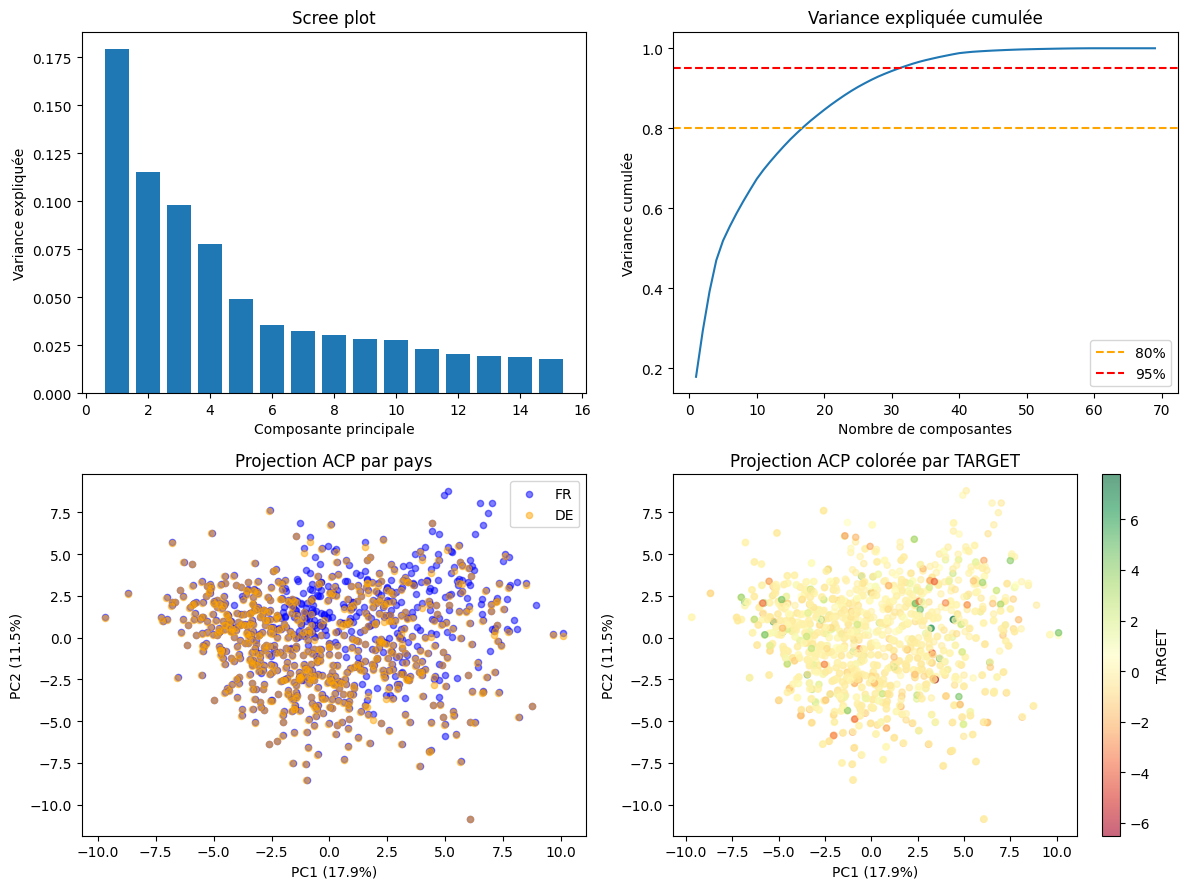

In [31]:
# ACP sur les features sélectionnées
X_pca = X_train_linear.copy()
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_pca.index, 'COUNTRY']
target = y_cv.loc[X_pca.index].values

pca = PCA()
X_proj = pca.fit_transform(X_pca)

variance = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance)

print("Variance expliquée par les 3 premières composantes :")
print(f"PC1 : {variance[0]:.1%}, PC2 : {variance[1]:.1%}, PC3 : {variance[2]:.1%}")
print(f"Nombre de composantes pour 80% de variance : {np.argmax(variance_cumulee >= 0.80) + 1}")
print(f"Nombre de composantes pour 95% de variance : {np.argmax(variance_cumulee >= 0.95) + 1}")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Screen plot
axes[0, 0].bar(range(1, 16), variance[:15])
axes[0, 0].set_xlabel("Composante principale")
axes[0, 0].set_ylabel("Variance expliquée")
axes[0, 0].set_title("Scree plot")

# Variance cumulée
axes[0, 1].plot(range(1, len(variance_cumulee)+1), variance_cumulee)
axes[0, 1].axhline(0.80, color='orange', linestyle='--', label='80%')
axes[0, 1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0, 1].set_xlabel("Nombre de composantes")
axes[0, 1].set_ylabel("Variance cumulée")
axes[0, 1].set_title("Variance expliquée cumulée")
axes[0, 1].legend()

# Projection par pays
for pays, couleur in [('FR', 'blue'), ('DE', 'orange')]:
    mask = country.values == pays
    axes[1, 0].scatter(X_proj[mask, 0], X_proj[mask, 1], c=couleur, alpha=0.5, s=20, label=pays)
axes[1, 0].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 0].set_title('Projection ACP par pays')
axes[1, 0].legend()

# Projection colorée par TARGET
sc = axes[1, 1].scatter(X_proj[:, 0], X_proj[:, 1], c=target, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1, 1], label='TARGET')
axes[1, 1].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 1].set_title('Projection ACP colorée par TARGET')

plt.tight_layout()
plt.show()


**Répartition de la variance**
Les valeurs PC1, PC2, PC3 ne présentent aucune domination par l'une des composante. De plus, on remarque une décroissance progressive, sans coude net. La variance est distribuée sur de nombreuses dimensions.

**Variance cumulée - Choix du nombre de composantes**
- 17 composantes : 80% de la variance
- 32 composantes : 95% de la variance

**Graphique par pays**
FR et DE sont fortement mélangés. L'ACP globale n'est pas discriminante entre pays. Cela justifie de faire une ACP séparée par pays.

**Graphique par target**
Aucun gradient clair visible (fortement mélangé).

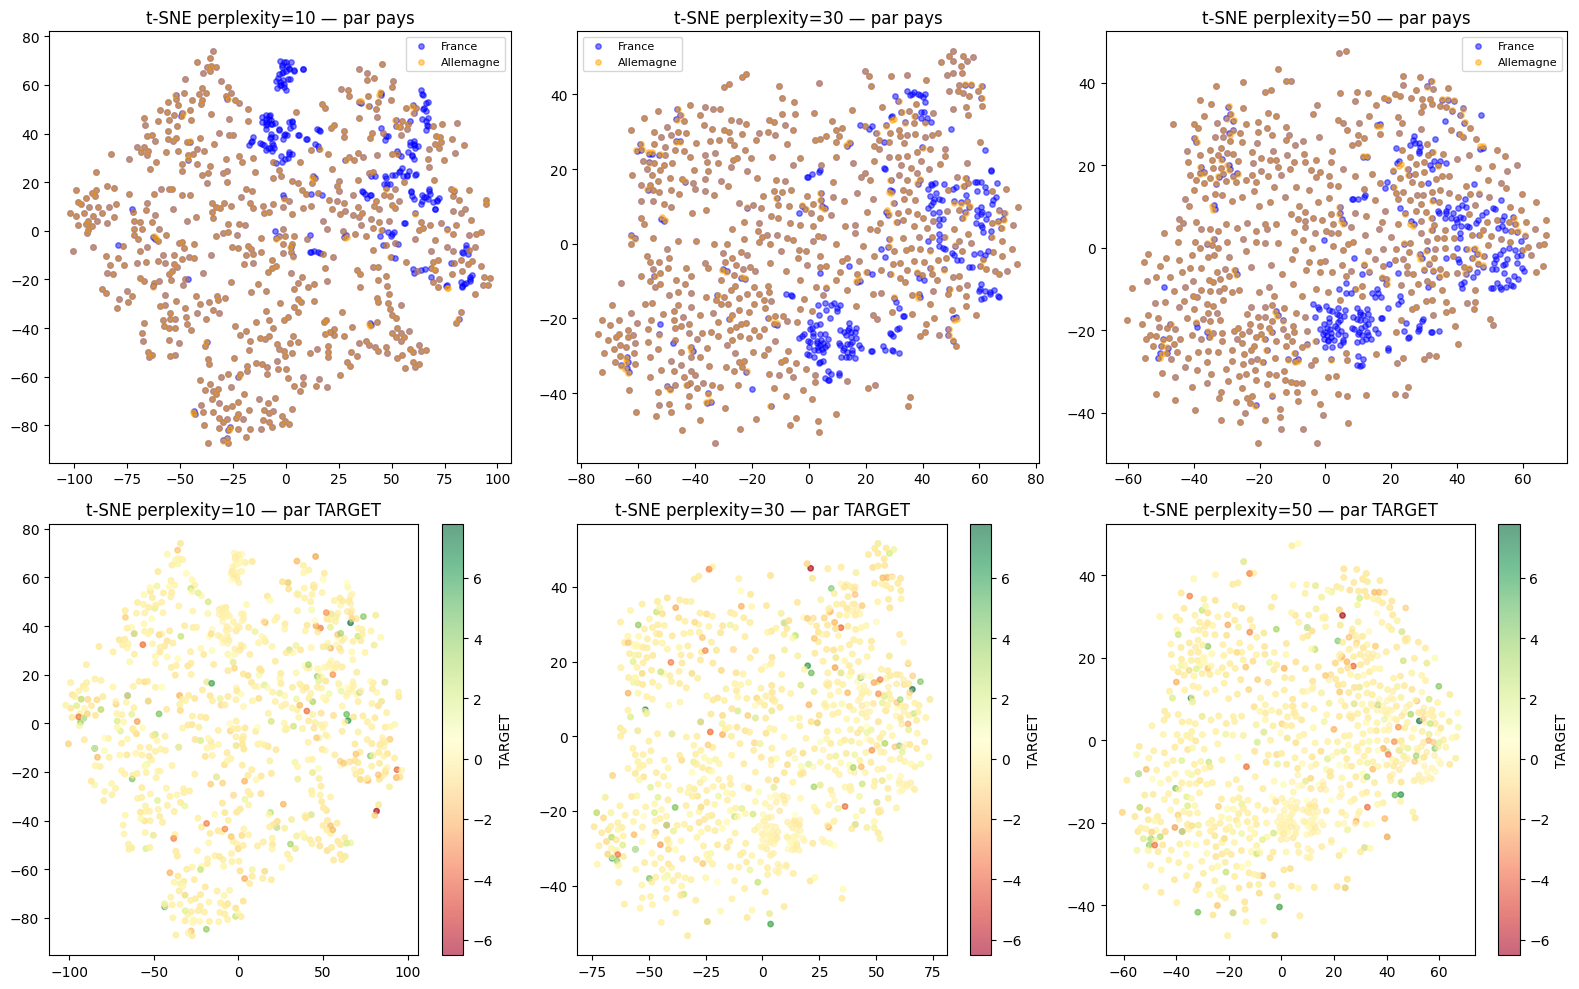

In [35]:


# Redéfinition au cas où la variable a été écrasée
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_train_linear.index, 'COUNTRY']

X_pca_50 = PCA(n_components=min(50, X_train_linear.shape[1]),
               random_state=42).fit_transform(X_train_linear)

perplexities = [10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp,
                max_iter=1000, learning_rate='auto',
                init='pca', random_state=42)
    X_tsne = tsne.fit_transform(X_pca_50)

    for pays, couleur, label in [('FR', 'blue', 'France'), ('DE', 'orange', 'Allemagne')]:
        mask = country.values == pays
        axes[0, col].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                             c=couleur, alpha=0.5, s=15, label=label)
    axes[0, col].set_title(f't-SNE perplexity={perp} — par pays')
    axes[0, col].legend(fontsize=8)

    sc = axes[1, col].scatter(X_tsne[:, 0], X_tsne[:, 1],
                               c=target, cmap='RdYlGn', alpha=0.6, s=15)
    plt.colorbar(sc, ax=axes[1, col], label='TARGET')
    axes[1, col].set_title(f't-SNE perplexity={perp} — par TARGET')

plt.tight_layout()
plt.show()


**Ligne 1 - Coloré par pays**
La France forme un cluster (Nord / Est en bleu) tandis que l'Allemagne est très dispersée dans l'espace. Cela signifie que les jours FR ont des profils similaires entre eux tandis que les jours DE sont plus hétérogènes

**Ligne 2 - Coloré par Target**
Par de gradient spatial clair. Le Target est difficile à prédire.

### Séparation au sein des pays

FR : 851 obs x 42 features
DE : 643 obs x 43 features
France : 23 composantes pour 95% variance
Allemagne : 22 composantes pour 95% variance


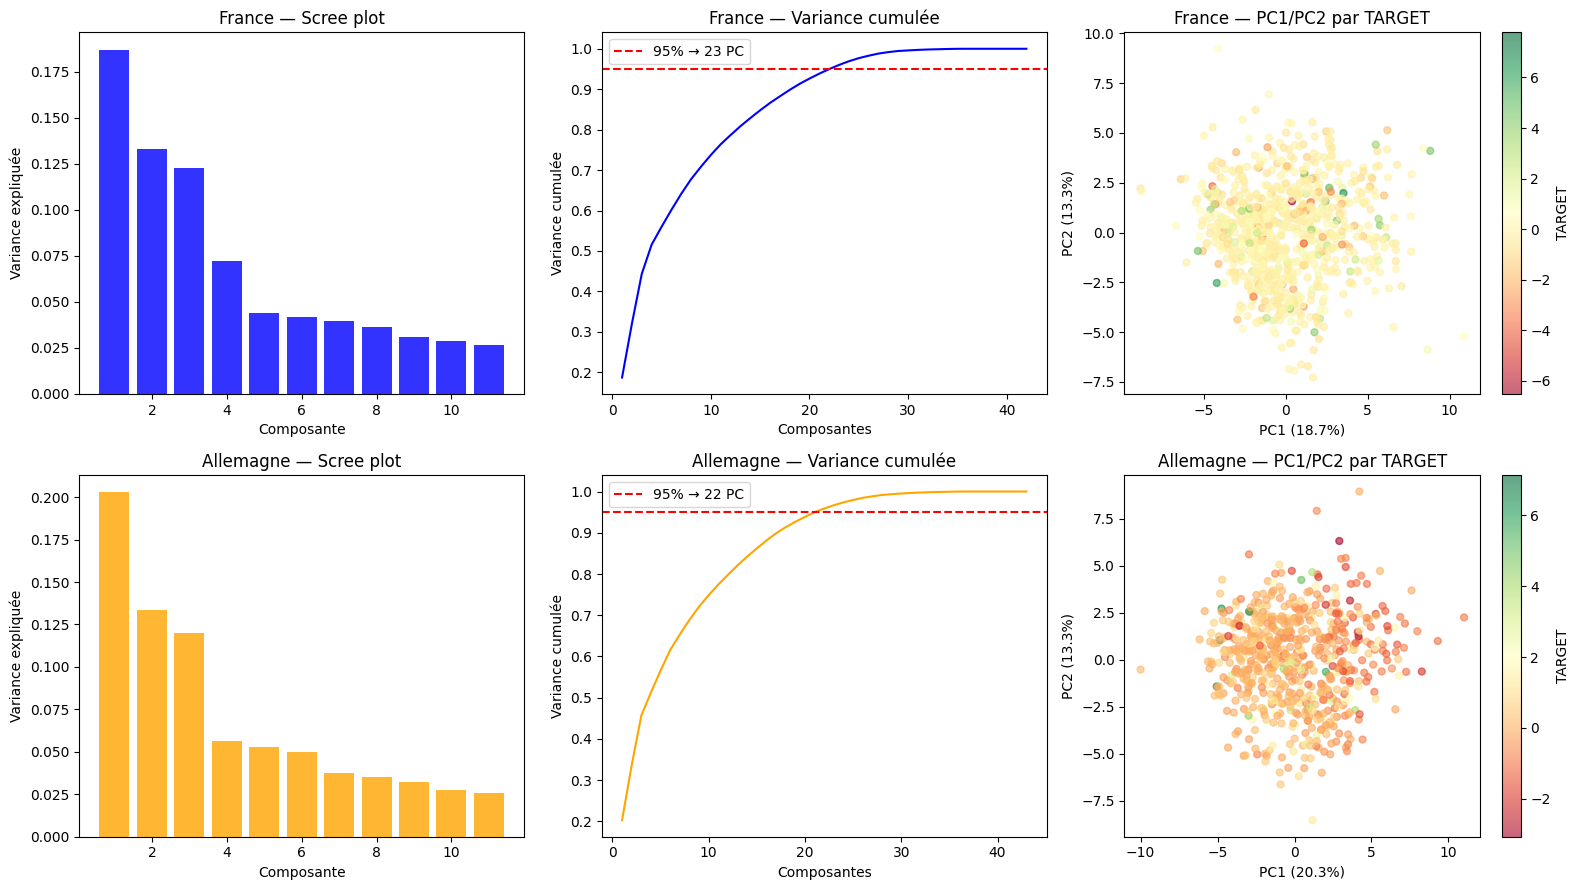

In [ ]:
# Séparation des features par pays
SHARED_FEATS = [f for f in selected_features_perm if not f.startswith('FR_') and not f.startswith('DE_')]
FR_FEATS = [f for f in selected_features_perm if f.startswith('FR_')] + SHARED_FEATS
DE_FEATS = [f for f in selected_features_perm if f.startswith('DE_')] + SHARED_FEATS

mask_fr = country.values == 'FR'
mask_de = country.values == 'DE'

X_fr = X_train_linear[mask_fr][FR_FEATS]
X_de = X_train_linear[mask_de][DE_FEATS]
y_fr = y_cv.loc[X_train_linear.index[mask_fr]].values
y_de = y_cv.loc[X_train_linear.index[mask_de]].values

print(f"FR : {X_fr.shape[0]} obs x {X_fr.shape[1]} features")
print(f"DE : {X_de.shape[0]} obs x {X_de.shape[1]} features")

# ACP par pays
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (X_c, y_c, label, color) in enumerate([
    (X_fr, y_fr, 'France', 'blue'),
    (X_de, y_de, 'Allemagne', 'orange'),
]):
    pca_c = PCA()
    Xp = pca_c.fit_transform(X_c)
    ev = pca_c.explained_variance_ratio_
    cumul_c = np.cumsum(ev)
    n95_c = np.argmax(cumul_c >= 0.95) + 1

    axes[row, 0].bar(range(1, min(12, len(ev)+1)), ev[:11], color=color, alpha=0.8)
    axes[row, 0].set_xlabel('Composante')
    axes[row, 0].set_ylabel('Variance expliquée')
    axes[row, 0].set_title(f'{label} — Scree plot')

    axes[row, 1].plot(range(1, len(cumul_c)+1), cumul_c, color=color)
    axes[row, 1].axhline(0.95, color='red', linestyle='--', label=f'95% → {n95_c} PC')
    axes[row, 1].set_xlabel('Composantes')
    axes[row, 1].set_ylabel('Variance cumulée')
    axes[row, 1].set_title(f'{label} — Variance cumulée')
    axes[row, 1].legend()

    sc = axes[row, 2].scatter(Xp[:, 0], Xp[:, 1], c=y_c, cmap='RdYlGn', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[row, 2], label='TARGET')
    axes[row, 2].set_xlabel(f'PC1 ({ev[0]:.1%})')
    axes[row, 2].set_ylabel(f'PC2 ({ev[1]:.1%})')
    axes[row, 2].set_title(f'{label} — PC1/PC2 par TARGET')

    print(f"{label} : {n95_c} composantes pour 95% variance")
    if label == 'France':
        pca_fr, X_pca_fr, n95_fr = pca_c, Xp, n95_c
    else:
        pca_de, X_pca_de, n95_de = pca_c, Xp, n95_c

plt.tight_layout()
plt.show()


Les deux ACP par pays confirment que 22-23 dimensions sont nécessaires pour décrire 95% de la variance (le signal est dans de nombreuses directions). Le TARGET n'est pas capturé par les 2 premières composantes dans aucun des deux pays, ce qui justifie d'utiliser toutes les composantes (pas seulement PC1/PC2) comme input pour le clustering KMeans/GMM qui suit.



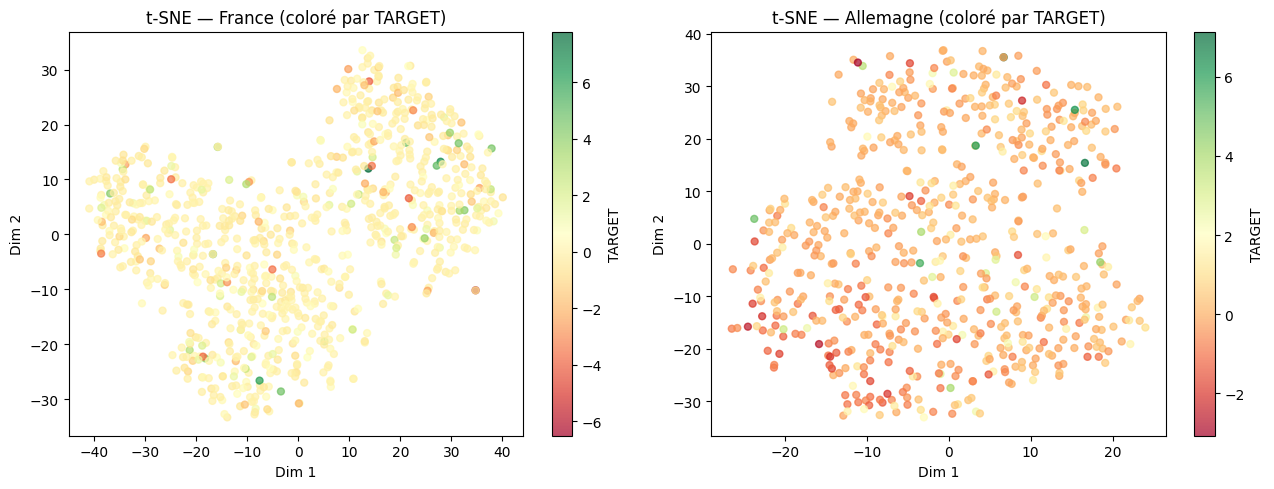

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_c, y_c, label in [
    (axes[0], X_fr, y_fr, 'France'),
    (axes[1], X_de, y_de, 'Allemagne'),
]:
    tsne_c = TSNE(n_components=2, perplexity=30,
                  max_iter=1000, learning_rate='auto',
                  init='pca', random_state=42)
    Xt = tsne_c.fit_transform(X_c)

    sc = ax.scatter(Xt[:, 0], Xt[:, 1], c=y_c, cmap='RdYlGn', alpha=0.7, s=25)
    plt.colorbar(sc, ax=ax, label='TARGET')
    ax.set_title(f't-SNE — {label} (coloré par TARGET)')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.show()


Le t-SNE par pays confirme et nuance les résultats précédents :

**France** : structure quasi-aléatoire → signal prix très difficile à capturer, modèle non supervisé limité

**Allemagne** : légère ségrégation spatiale par TARGET → des régimes de marché distincts existent, le clustering a plus de sens pour DE
En pratique, cela suggère que le clustering sera plus utile pour DE que pour FR, et que des modèles séparés par pays restent justifiés.

### Interprétation économique des composantes

In [38]:
# Interprétation économique des composantes
for label, pca_c, feats in [('France', pca_fr, FR_FEATS), ('Allemagne', pca_de, DE_FEATS)]:

    ev = pca_c.explained_variance_ratio_
    loadings = pd.DataFrame(pca_c.components_[:3].T,
                            index=feats, columns=['PC1','PC2','PC3'])

    print(f"\n{label.upper()}")
    print(f"Les 3 premières composantes expliquent {ev[:3].sum():.1%} de la variance totale.\n")

    for pc in ['PC1','PC2','PC3']:
        idx  = int(pc[2:]) - 1
        top  = loadings[pc].abs().nlargest(5)

        print(f"  {pc} ({ev[idx]:.1%} de la variance)")
        for feat in top.index:
            val      = loadings.loc[feat, pc]
            sens     = "positivement" if val > 0 else "négativement"
            print(f"    {feat} contribue {sens} ({abs(val):.3f})")
        print()

# Matrices réduites pour le clustering
pca_fr_final = PCA(n_components=n95_fr, random_state=42)
pca_de_final = PCA(n_components=n95_de, random_state=42)

X_cluster_fr = pca_fr_final.fit_transform(X_fr)
X_cluster_de = pca_de_final.fit_transform(X_de)

print("Matrices prêtes pour le clustering :")
print(f"  France     : {X_fr.shape[1]} features réduits à {n95_fr} composantes  {X_cluster_fr.shape}")
print(f"  Allemagne  : {X_de.shape[1]} features réduits à {n95_de} composantes  {X_cluster_de.shape}")



FRANCE
Les 3 premières composantes expliquent 44.3% de la variance totale.

  PC1 (18.7% de la variance)
    FR_RESIDUAL_LOAD contribue positivement (0.298)
    FR_CONSUMPTION contribue positivement (0.296)
    FR_GAS contribue positivement (0.290)
    FR_DE_EXCHANGE contribue négativement (0.257)
    NET_FLOW_DE_TO_FR contribue positivement (0.257)

  PC2 (13.3% de la variance)
    FR_NUCLEAR contribue positivement (0.322)
    FR_NET_BALANCE contribue positivement (0.297)
    FR_NET_EXPORT contribue positivement (0.297)
    FR_TRADE_BALANCE contribue positivement (0.297)
    FR_NET_IMPORT contribue négativement (0.297)

  PC3 (12.3% de la variance)
    FOSSIL_COST_INDEX contribue positivement (0.390)
    CARBON_RET contribue positivement (0.381)
    COAL_CARBON_COST contribue positivement (0.374)
    GAS_CARBON_COST contribue positivement (0.355)
    COAL_RET contribue positivement (0.317)


ALLEMAGNE
Les 3 premières composantes expliquent 45.6% de la variance totale.

  PC1 (20.3% d

## 6.2) KMeans

### 6.2.1) Ajout des features

Nous allons utiliser un kmeans pour regrouper nos données en cluster et leur ajouter des données qui pourraient être utiles dans notre analyse. 

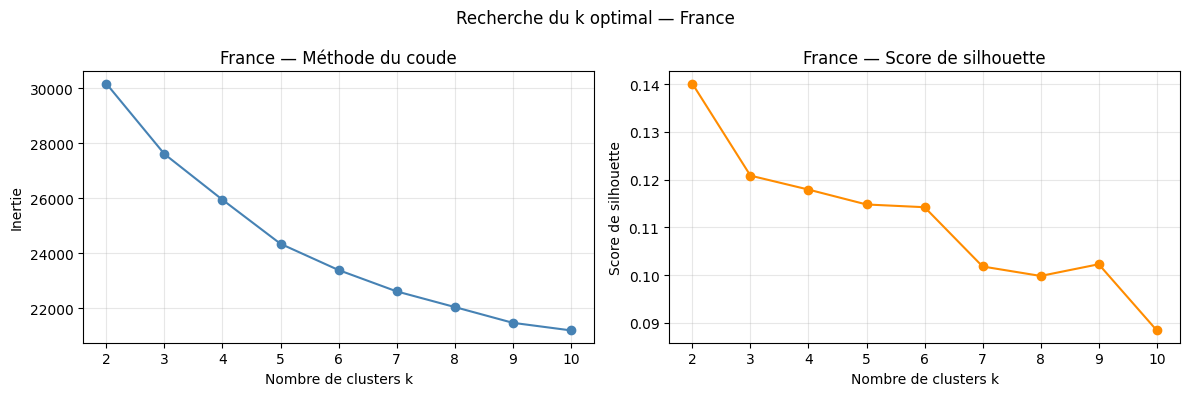

France : meilleur k selon silhouette = 2 (score = 0.140)


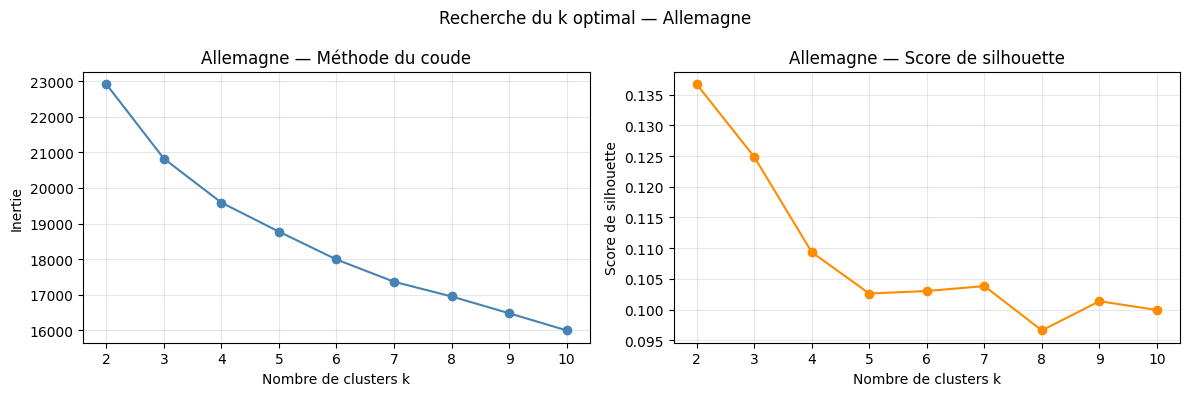

Allemagne : meilleur k selon silhouette = 2 (score = 0.137)


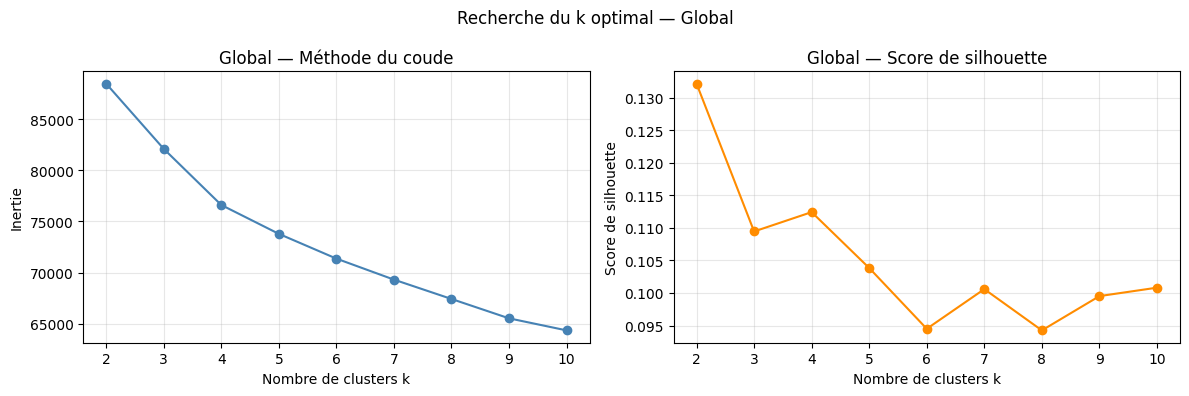

Global : meilleur k selon silhouette = 2 (score = 0.132)


In [43]:
n95 = np.argmax(variance_cumulee >= 0.95) + 1
pca_all_final = PCA(n_components=n95, random_state=42)
X_cluster_all = pca_all_final.fit_transform(X_train_linear)

def find_k_opt(X, label, k_range=range(2,11)):
    inerties    = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inerties.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))

    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Coude
    axes[0].plot(k_range, inerties, 'o-', color='steelblue')
    axes[0].set(xlabel='Nombre de clusters k', ylabel='Inertie',
                title=f'{label} — Méthode du coude')
    axes[0].grid(True, alpha=0.3)

    # Silhouette
    axes[1].plot(k_range, silhouettes, 'o-', color='darkorange')
    axes[1].set(xlabel='Nombre de clusters k', ylabel='Score de silhouette',
                title=f'{label} — Score de silhouette')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du k optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    k_best = k_range[np.argmax(silhouettes)]
    print(f"{label} : meilleur k selon silhouette = {k_best} "
          f"(score = {max(silhouettes):.3f})")
    return k_best

k_best_fr = find_k_opt(X_cluster_fr, 'France')
k_best_de = find_k_opt(X_cluster_de, 'Allemagne')
k_best_all = find_k_opt(X_cluster_all, 'Global')


Les résultats confirment nos attentes : les données ne présentent pas de structures en clusters forte. 

**Score du coude** Les courbes (méthode du coude) décroissent sans rupture franche.

**Score de silhouette** Les scores sont tous inférieur à 0.25 ce qui est considéré comme faible.

In [47]:
km_fr  = KMeans(n_clusters=k_best_fr,  random_state=42, n_init=10)
km_de  = KMeans(n_clusters=k_best_de,  random_state=42, n_init=10)
km_all = KMeans(n_clusters=k_best_all, random_state=42, n_init=10)

labels_fr  = km_fr.fit_predict(X_pca_fr)
labels_de  = km_de.fit_predict(X_pca_de)
labels_all = km_all.fit_predict(X_cluster_all)

print(f"France — répartition : {pd.Series(labels_fr).value_counts().sort_index().to_dict()}")
print(f"Allemagne — répartition : {pd.Series(labels_de).value_counts().sort_index().to_dict()}")
print(f"Global — répartition : {pd.Series(labels_all).value_counts().sort_index().to_dict()}")

for label, X_c, labels, feats, y_c in [
    ('France', X_fr,  labels_fr,  FR_FEATS, y_fr),
    ('Allemagne', X_de,  labels_de,  DE_FEATS, y_de),
    ('Global', X_train_linear, labels_all, selected_features_perm,
                  y_cv.loc[X_train_linear.index].values),
]:
    df_c = pd.DataFrame(X_c.values, columns=feats)
    df_c['cluster'] = labels
    df_c['TARGET']  = y_c

    print(f"\n{label.upper()}")
    print(df_c.groupby('cluster')[['TARGET'] + feats[:5]].mean().round(3).to_string())
    print()


France — répartition : {0: 334, 1: 517}
Allemagne — répartition : {0: 279, 1: 364}
Global — répartition : {0: 597, 1: 897}

FRANCE
         TARGET  FR_WIND_SOLAR_PROD  FR_WIND_x_WINDPOW  FR_GAS_COST_x_PROD  FR_WINDPOW  FR_GAS
cluster                                                                                       
0         0.043              -0.321             -0.179              -0.017       0.443   0.807
1         0.048               0.070              0.101              -0.015      -0.346  -0.524


ALLEMAGNE
         TARGET  DE_WINDPOW  DE_RESIDUAL_LOAD  DE_LIGNITE  DE_WIND_SOLAR_PROD  DE_WIND
cluster                                                                               
0        -0.019       0.789            -0.348      -0.116               0.178    0.451
1         0.276      -0.591             0.130      -0.272              -0.033   -0.091


GLOBAL
         TARGET  COUNTRY_FR  DE_WINDPOW  COUNTRY_DE  FR_WIND_SOLAR_PROD  DE_RESIDUAL_LOAD
cluster                       

**Allemagne** :
On remarque deux régimes (éolien et thermique). L'écart de ~0.30 est cohérent avec le merit order effect : les renouvelables évincent les centrales thermiques et font baisser les prix spot. Le clustering capte une structure économique réelle.

**France** :
Ecart de TARGET quasi nul entre clusters. Le nucléaire, à coût marginal fixe, absorbe les variations de renouvelables et de gaz — le prix français y est peu sensible. Cela explique les scores CV plus faibles pour la France (≈ 0.14 vs 0.35 pour l'Allemagne).

**Global** : signal dilué par le mélange des deux pays. 

In [52]:
day_id_map = x_train[['ID', 'DAY_ID']].set_index('ID')
grp_fr = day_id_map.loc[X_train_linear.index[mask_fr], 'DAY_ID'].values
grp_de = day_id_map.loc[X_train_linear.index[mask_de], 'DAY_ID'].values


ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
gkf   = GroupKFold(n_splits=5)
y_all_vals = y_cv.loc[X_train_linear.index].values

cases = [
    ('France',    X_fr,              labels_fr,  y_fr,       grp_fr),
    ('Allemagne', X_de,              labels_de,  y_de,       grp_de),
    ('Global',    X_train_linear.values, labels_all, y_all_vals, groups),
]

for label, X_c, labels, y_c, grp in cases:
    splits = list(gkf.split(X_c, y_c, groups=grp))
    cv_kw  = dict(cv=splits, scoring=spearman_scorer, n_jobs=-1)

    score_sans  = cross_val_score(ridge, X_c, y_c, **cv_kw)
    cluster_oh  = pd.get_dummies(labels, prefix='cluster').values
    score_avec  = cross_val_score(ridge, np.hstack([X_c, cluster_oh]), y_c, **cv_kw)

    print(f"{label}")
    print(f"  Sans cluster : {score_sans.mean():.4f} ± {score_sans.std():.4f}")
    print(f"  Avec cluster : {score_avec.mean():.4f} ± {score_avec.std():.4f}")
    print(f"  Gain KMeans  : {score_avec.mean() - score_sans.mean():+.4f}\n")


France
  Sans cluster : 0.1300 ± 0.1012
  Avec cluster : 0.1293 ± 0.1013
  Gain KMeans  : -0.0007

Allemagne
  Sans cluster : 0.3485 ± 0.0417
  Avec cluster : 0.3481 ± 0.0410
  Gain KMeans  : -0.0004

Global
  Sans cluster : 0.2114 ± 0.0304
  Avec cluster : 0.2114 ± 0.0304
  Gain KMeans  : -0.0000



## 6.3) Gaussian Mixture Model (GMM)

Étant donné que nos jeu de données s'apparente à des séries temporelles, le GMM peut être performant. C'est un modèle de clustering probabiliste qui suppose que les données suivent un mélange de plusieurs distributions gaussiennes.

Dans notre cas, le GMM apparait comme une confirmation que nos données ne présentent pas de structure en clusters expoitable et de founir une analyse de régimes de marché plus nuancée que KMeans.

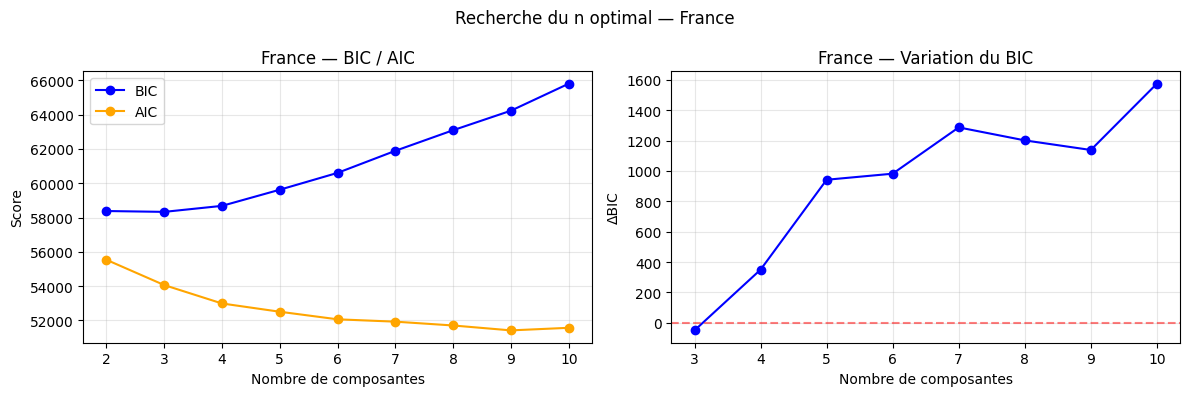

France : meilleur n selon BIC = 3 - selon AIC = 9


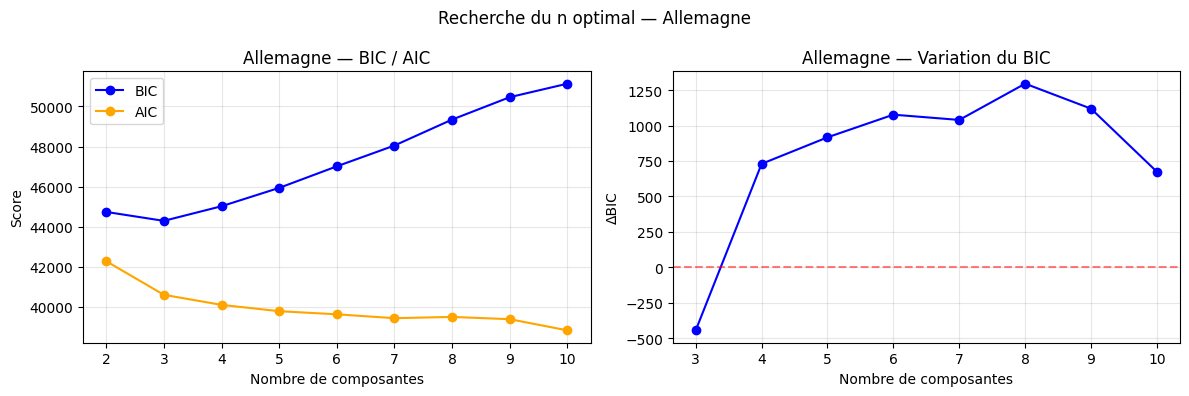

Allemagne : meilleur n selon BIC = 3 - selon AIC = 10


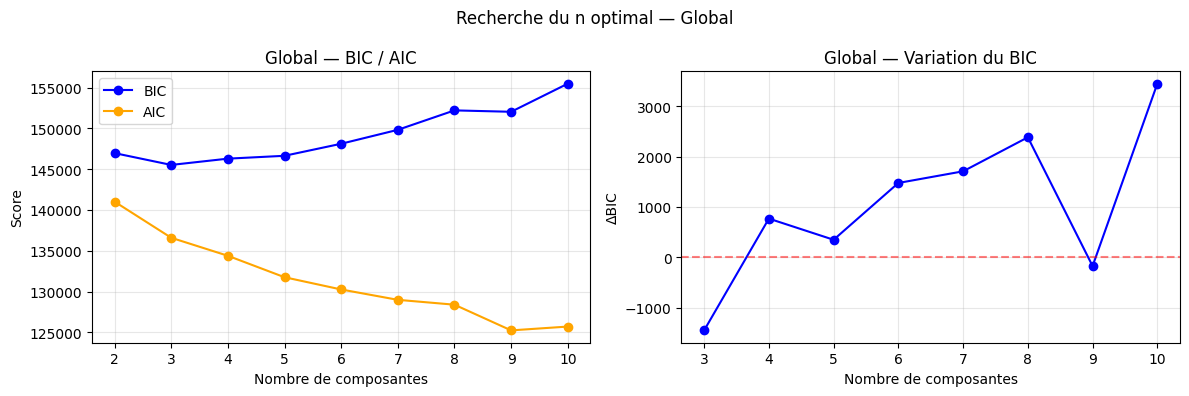

Global : meilleur n selon BIC = 3 - selon AIC = 9


In [55]:
def chercher_n_gmm(X, label, n_range=range(2, 11)):
    bics, aics = [], []

    for n in n_range:
        gmm = GaussianMixture(n_components=n, covariance_type='full',
                              random_state=42, n_init=5)
        gmm.fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(n_range, bics, 'o-', color='blue', label='BIC')
    axes[0].plot(n_range, aics, 'o-', color='orange', label='AIC')
    axes[0].set(xlabel='Nombre de composantes', ylabel='Score',
                title=f'{label} — BIC / AIC')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Différence pour voir le coude
    bic_diff = np.diff(bics)
    axes[1].plot(list(n_range)[1:], bic_diff, 'o-', color='blue')
    axes[1].axhline(0, color='red', ls='--', alpha=0.5)
    axes[1].set(xlabel='Nombre de composantes', ylabel='ΔBIC',
                title=f'{label} — Variation du BIC')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du n optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    n_best_bic = n_range[np.argmin(bics)]
    n_best_aic = n_range[np.argmin(aics)]
    print(f"{label} : meilleur n selon BIC = {n_best_bic} - selon AIC = {n_best_aic}")
    return n_best_bic

n_gmm_fr  = chercher_n_gmm(X_cluster_fr, 'France')
n_gmm_de  = chercher_n_gmm(X_cluster_de, 'Allemagne')
n_gmm_all = chercher_n_gmm(X_cluster_all, 'Global')


Le BIC pénalise davantage la complexité que l'AIC. Dans notre cas on va choisir BIC car on préfère un modèle plus parcimonieux pour éviter l'overfitting => 3 composantes

In [60]:
cov_types = ['full', 'tied', 'diag', 'spherical']

print(f"{'Scope':<12} {'cov_type':<12} {'BIC':>10} {'AIC':>10}")

best_gmms = {}
for label, X_c, n_c in [
    ('France', X_cluster_fr,  n_gmm_fr),
    ('Allemagne', X_cluster_de,  n_gmm_de),
    ('Global', X_cluster_all, n_gmm_all),
]:
    best_bic, best_gmm = np.inf, None
    for cov in cov_types:
        gmm = GaussianMixture(n_components=n_c, covariance_type=cov,
                              random_state=42, n_init=5)
        gmm.fit(X_c)
        bic, aic = gmm.bic(X_c), gmm.aic(X_c)
        marker = ' <-- meilleur' if bic < best_bic else ''
        print(f"{label:<12} {cov:<12} {bic:>10.1f} {aic:>10.1f}{marker}")
        if bic < best_bic:
            best_bic, best_gmm = bic, gmm
    best_gmms[label] = best_gmm
    print()

gmm_fr  = best_gmms['France']
gmm_de  = best_gmms['Allemagne']
gmm_all = best_gmms['Global']

labels_gmm_fr  = gmm_fr.predict(X_cluster_fr)
labels_gmm_de  = gmm_de.predict(X_cluster_de)
labels_gmm_all = gmm_all.predict(X_cluster_all)

for label, labels in [('France', labels_gmm_fr),
                       ('Allemagne', labels_gmm_de),
                       ('Global', labels_gmm_all)]:
                       counts = pd.Series(labels).value_counts().sort_index()
                       total=counts.sum()
                       parts = " ".join(f"Cluster {i+1}: {n} ({n/total:.0%})" for i,n in counts.items())
                       print(f"{label:<12} — {parts}")



Scope        cov_type            BIC        AIC
France       full            58333.2    54066.1 <-- meilleur
France       tied            61074.9    59427.9
France       diag            59663.2    58998.7
France       spherical       64324.3    63973.1

Allemagne    full            44287.7    40594.2 <-- meilleur
Allemagne    tied            45371.0    43937.3
Allemagne    diag            43735.1    43136.6 <-- meilleur
Allemagne    spherical       47211.3    46894.2

Global       full           145518.8   136588.8 <-- meilleur
Global       tied           153547.1   150223.6
Global       diag           149892.6   148862.6
Global       spherical      165154.5   164618.3

France       — Cluster 1: 259 (30%) Cluster 2: 246 (29%) Cluster 3: 346 (41%)
Allemagne    — Cluster 1: 132 (21%) Cluster 2: 203 (32%) Cluster 3: 308 (48%)
Global       — Cluster 1: 420 (28%) Cluster 2: 684 (46%) Cluster 3: 390 (26%)


La covariance 'full' est plus flexible : chaque composante a sa propre matrice de corrélation.

La répartition en 3 clusters est déséquilibrée pour l'Allemagne (21% / 32% / 48%) :
le cluster 3 capture le régime dominant (jours "normaux"), les clusters 1 et 2 isolent
des régimes extrêmes moins fréquents (fort éolien, fort thermique).
Pour la France et le Global, la répartition est plus équilibrée (~28–46%).


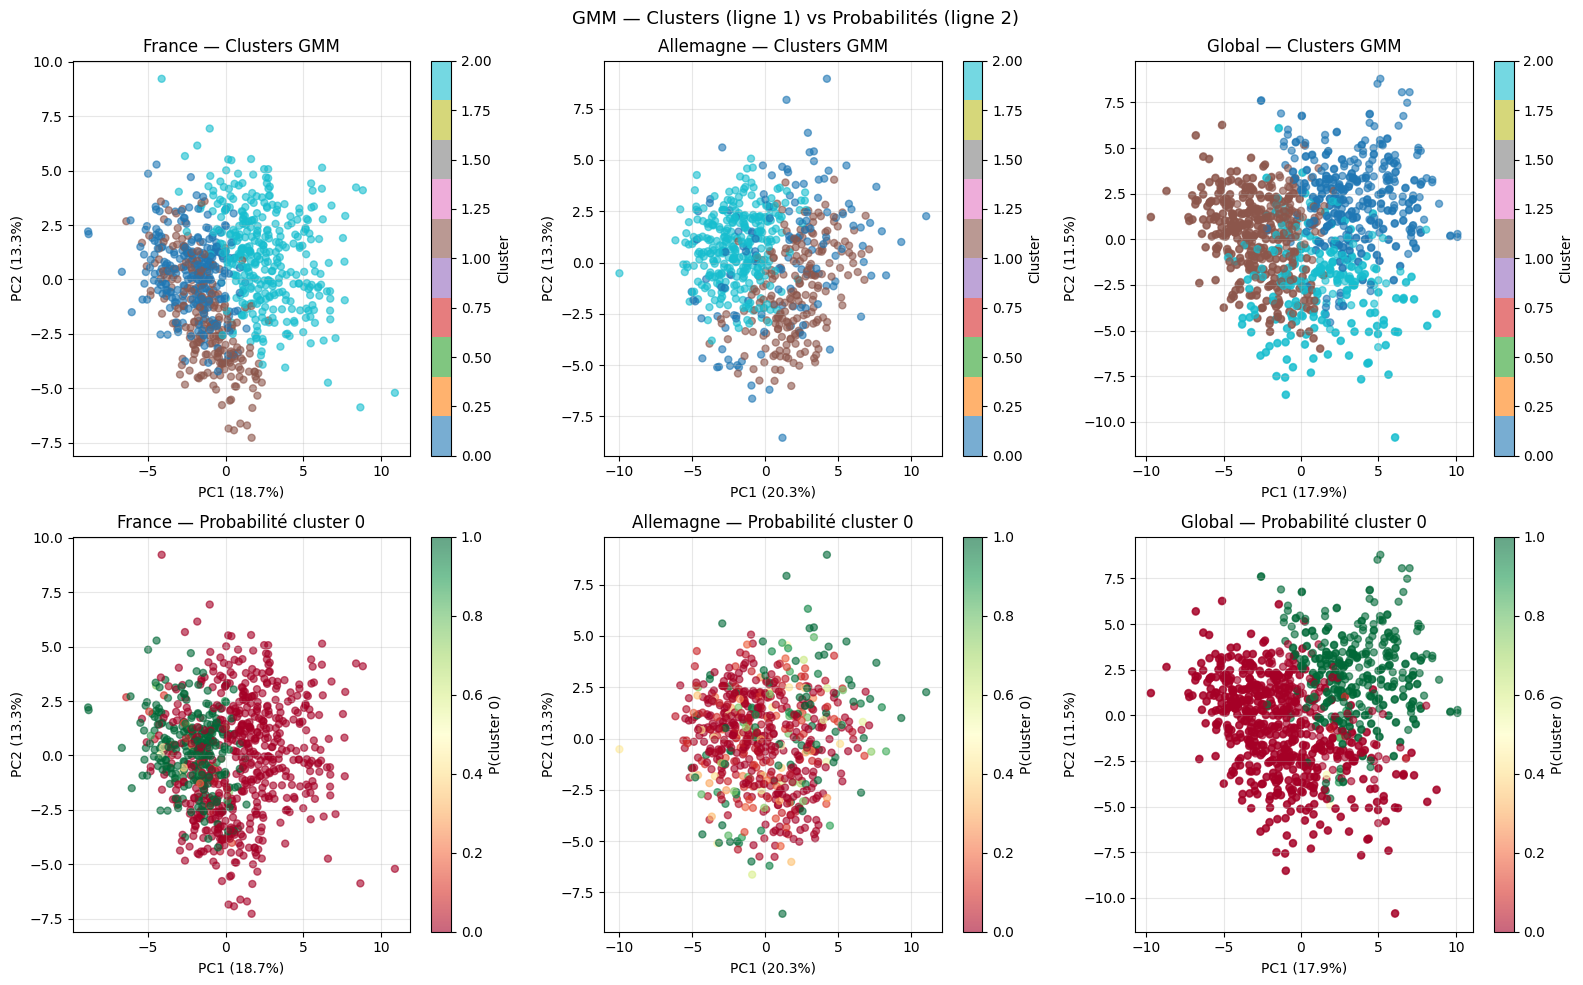

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (X_pca_2d, X_c, gmm_c, labels, label, ev) in enumerate([
    (X_pca_fr[:, :2], X_pca_fr[:, :n95_fr], gmm_fr,  labels_gmm_fr,  'France',    pca_fr.explained_variance_ratio_),
    (X_pca_de[:, :2], X_pca_de[:, :n95_de], gmm_de,  labels_gmm_de,  'Allemagne', pca_de.explained_variance_ratio_),
    (X_proj[:, :2],   X_cluster_all,         gmm_all, labels_gmm_all, 'Global',    pca_all_final.explained_variance_ratio_),
]):

    # Ligne 1 : clusters GMM (hard assignment)
    sc = axes[0, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=labels, cmap='tab10', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[0, col], label='Cluster')
    axes[0, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Clusters GMM')
    axes[0, col].grid(True, alpha=0.3)

    # Ligne 2 : probabilité d'appartenance au cluster 0 (soft assignment)
    proba = gmm_c.predict_proba(X_c)[:, 0]
    sc2 = axes[1, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                c=proba, cmap='RdYlGn', alpha=0.6, s=25,
                                vmin=0, vmax=1)
    plt.colorbar(sc2, ax=axes[1, col], label='P(cluster 0)')
    axes[1, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Probabilité cluster 0')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('GMM — Clusters (ligne 1) vs Probabilités (ligne 2)', fontsize=13)
plt.tight_layout()
plt.show()


In [66]:
print(f"{'Scope':<12} {'KMeans':>10} {'GMM hard':>10} {'GMM soft':>12}")
print('-' * 48)

y_all_vals = y_cv.loc[X_train_linear.index].values
groups     = day_id_map.loc[X_train_linear.index, 'DAY_ID'].values

gkf = GroupKFold(n_splits=5)
r   = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

for label, X_c, labels_km, gmm_c, X_gmm, y_c, grp in [
    ('France',    X_fr.values,   labels_fr,  gmm_fr,  X_pca_fr[:, :n95_fr], y_fr,       grp_fr),
    ('Allemagne', X_de.values,   labels_de,  gmm_de,  X_pca_de[:, :n95_de], y_de,       grp_de),
    ('Global',    X_train_linear.values,  labels_all, gmm_all, X_cluster_all,         y_all_vals, groups),
]:
    cv = list(gkf.split(X_c, y_c, groups=grp))

    # KMeans (one-hot)
    s_km = cross_val_score(r, np.hstack([X_c, pd.get_dummies(labels_km, prefix='c').values]),
                           y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    # GMM hard (one-hot)
    labels_gmm = gmm_c.predict(X_gmm)
    s_gmm_h = cross_val_score(r, np.hstack([X_c, pd.get_dummies(labels_gmm, prefix='c').values]),
                               y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    # GMM soft (probabilités)
    s_gmm_s = cross_val_score(r, np.hstack([X_c, gmm_c.predict_proba(X_gmm)]),
                               y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    print(f"{label:<12} {s_km.mean():>10.4f} {s_gmm_h.mean():>10.4f} {s_gmm_s.mean():>12.4f}")


Scope            KMeans   GMM hard     GMM soft
------------------------------------------------


France           0.1293     0.1298       0.1299
Allemagne        0.3481     0.3462       0.3464
Global           0.2114     0.2109       0.2108


ni KMeans ni GMM n'apportent un gain structurel. Les données ne se divisent pas en régimes distincts exploitables pour la prédiction, ce qui confirme que c'est un problème de régression continue, pas de régimes discrets.



# 8) Modèle supervisé

## 8.1) Classification

## 8.2) Regression

## 8.3) Modèle d'ensemble

# 9) Intéprétation des modèles

# 10) Modèles de Deep Learning

## 10.1) Réseau de Neurone Standard

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [22]:
X = x_train_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")
y = y_train_clean.to_numpy(dtype="float32")

print(X.shape)
print(y.shape)

(1494, 69)
(1494,)


### 10.1.1) Définition de la métrique de Spearman pour Kéras

In [23]:
def spearman_metric(y_true, y_pred):
    '''
    Métrique de Spearman pour Keras afin de l'utiliser pour le training
    On va optimiser MSE en monitorant Spearman
    '''
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_centered = y_true - tf.reduce_mean(y_true)
    y_pred_centered = y_pred - tf.reduce_mean(y_pred)

    numerator = tf.reduce_sum(y_true_centered * y_pred_centered)

    denominator = (tf.sqrt(tf.reduce_sum(y_true_centered**2)) * 
                    tf.sqrt(tf.reduce_sum(y_pred_centered**2)) + 1e-8)
    
    return numerator / denominator

### 10.1.2) Construction du réseau de neurones

Chaque neurone fait : output = f(w*input + bias) avec f la fonction d'activation (ReLu, sigmoid, linear...).

**ReLu Activation** f(x) = max(0, x) -> évite le problème de gradient (utiliser dans les couches cachées)

**Linear activation** f(x) = x -> utilisée en sortie pour la regression

**L2 Regularitsation** pénalise les poids trop grands

In [27]:
def build_model(input_dim, hidden_layers):
    '''Construction du réseau de neurones'''

    # Sequential = modèle linéaire
    model = Sequential()

    # Couche 1
    model.add(Dense(
        hidden_layers[0], 
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(input_dim,)
    ))
    model.add(Dropout(0.3))

    # Couches suivantes :
    for n_neurons in hidden_layers[1:]:
        model.add(Dense(
            n_neurons,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ))
        model.add(Dropout(0.3))
    
    # Couche de sortie
    model.add(Dense(1, activation="linear"))
    return model

# Defintiion des splits GroupKFold
groups    = x_train_median['DAY_ID'].values
gkf_nn    = GroupKFold(n_splits=5)
cv_splits = list(gkf_nn.split(X, y, groups=groups))

# Comparaison des architectures

architectures = {
    "petite" : [32, 16],
    "moyenne" : [128, 64, 32],
    "grande" : [256, 128, 64, 32]
}

results_archi = {}

for nom, layers in architectures.items():
    print(f"Architecture {nom} : {layers}")
    fold_scores = []
    oof = np.zeros(len(y))

    for fold, (tr_idx, val_idx) in enumerate(cv_splits):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = build_model(X.shape[1], layers)
        model.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

        model.fit(
            X_tr, y_tr,
            epochs=200,
            batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                        restore_best_weights=True, verbose=0)],
            verbose=0
        )

        preds = model.predict(X_val, verbose=0).flatten()
        oof[val_idx] = preds
        rho = spearmanr(y_val, preds).correlation
        fold_scores.append(rho)
        print(f"Fold {fold+1}, Spearman = {rho:.4f}")

    rho_oof = spearmanr(y, oof).correlation
    results_archi[nom] = {

        "cv_mean" : np.mean(fold_scores),
        "cv_std"  : np.std(fold_scores),
        "oof"     : rho_oof,
        "layers"  : layers
    }
    print(f"  OOF : {rho_oof:.4f} | CV : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Architecture':<10} {'Couches':<20} {'CV Spearman':>12} {'OOF':>8}")
print(f"{'='*55}")
for nom, res in sorted(results_archi.items(), key=lambda x: -x[1]['oof']):
    print(f"{nom:<10} {str(res['layers']):<20} {res['cv_mean']:>8.4f} ± {res['cv_std']:.2f} {res['oof']:>8.4f}")
print(f"{'='*55}")



Architecture petite : [32, 16]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1, Spearman = 0.1664
Fold 2, Spearman = 0.1130
Fold 3, Spearman = 0.1919
Fold 4, Spearman = 0.1288
Fold 5, Spearman = 0.2343
  OOF : 0.1301 | CV : 0.1669 ± 0.0436
Architecture moyenne : [128, 64, 32]
Fold 1, Spearman = 0.1816
Fold 2, Spearman = 0.2089
Fold 3, Spearman = 0.1193
Fold 4, Spearman = 0.1590
Fold 5, Spearman = 0.2291
  OOF : 0.1700 | CV : 0.1796 ± 0.0384
Architecture grande : [256, 128, 64, 32]
Fold 1, Spearman = 0.2369
Fold 2, Spearman = 0.2581
Fold 3, Spearman = 0.1556
Fold 4, Spearman = 0.1488
Fold 5, Spearman = 0.2513
  OOF : 0.2044 | CV : 0.2101 ± 0.0479

Architecture Couches               CV Spearman      OOF
grande     [256, 128, 64, 32]     0.2101 ± 0.05   0.2044
moyenne    [128, 64, 32]          0.1796 ± 0.04   0.1700
petite     [32, 16]               0.1669 ± 0.04   0.1301


Pour chaque architecture on entraine le modèle sur 4 folds, on prédit sur le fold restant, on calcule le Spearman sur les prédiction oof et on stocke les résultats

### 10.1.3) Visualisation des courbes d'apprentissage

- training loss baisse mais vl_loss remonte => overfit
- les deux descendent ensemble => bon apprentissage
- les deux stagnent => underfit

In [29]:
best_archi = max(results_archi.items(), key=lambda x: x[1]['oof'])
best_layers = best_archi[1]['layers']
print(f"\nMeilleure architecture : {best_archi[0]} {best_layers}")

# Réentraînement sur le dernier fold pour récupérer l'historique
tr_idx, val_idx = cv_splits[-1]
X_tr, X_val = X[tr_idx], X[val_idx]
y_tr, y_val = y[tr_idx], y[val_idx]

model_best = build_model(X.shape[1], best_layers)
model_best.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

history_best = model_best.fit(
    X_tr, y_tr,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)


Meilleure architecture : grande [256, 128, 64, 32]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


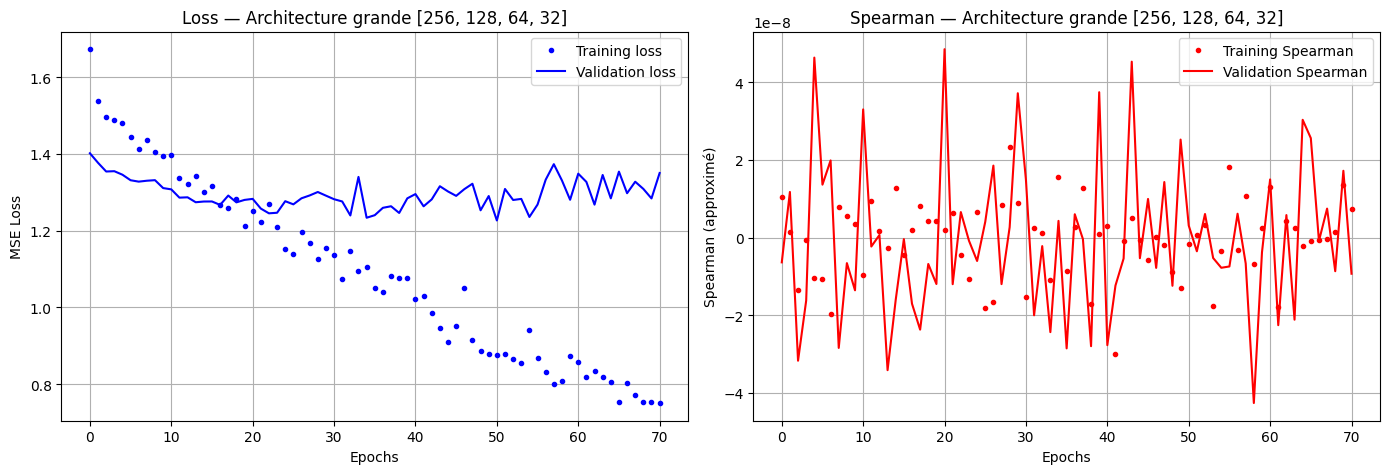

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_best.history['loss'], 'bo', label='Training loss',   markersize=3)
axes[0].plot(history_best.history['val_loss'], 'b', label='Validation loss')
axes[0].set_title(f'Loss — Architecture {best_archi[0]} {best_layers}')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# Graphe 2 : Spearman approximé
axes[1].plot(history_best.history['spearman_metric'], 'ro', label='Training Spearman',   markersize=3)
axes[1].plot(history_best.history['val_spearman_metric'], 'r', label='Validation Spearman')
axes[1].set_title(f'Spearman — Architecture {best_archi[0]} {best_layers}')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Spearman (approximé)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

On remarque un overfit classique. Le modèle apprend bien sur le train mais ne se généralise pas. De plus, le modèle n'apprend aucune corrélation. Le réseau de neurone est inadapté à ce probleme : le dataset est trop petit, le signal dans les données est faible et linéaire.

# 11) Interprétation des résultats

Interprétez votre modèle avec les outils adéquats (variables importance, LIME, SHAP...)

## 11.1) Visualisation de l'importance des features

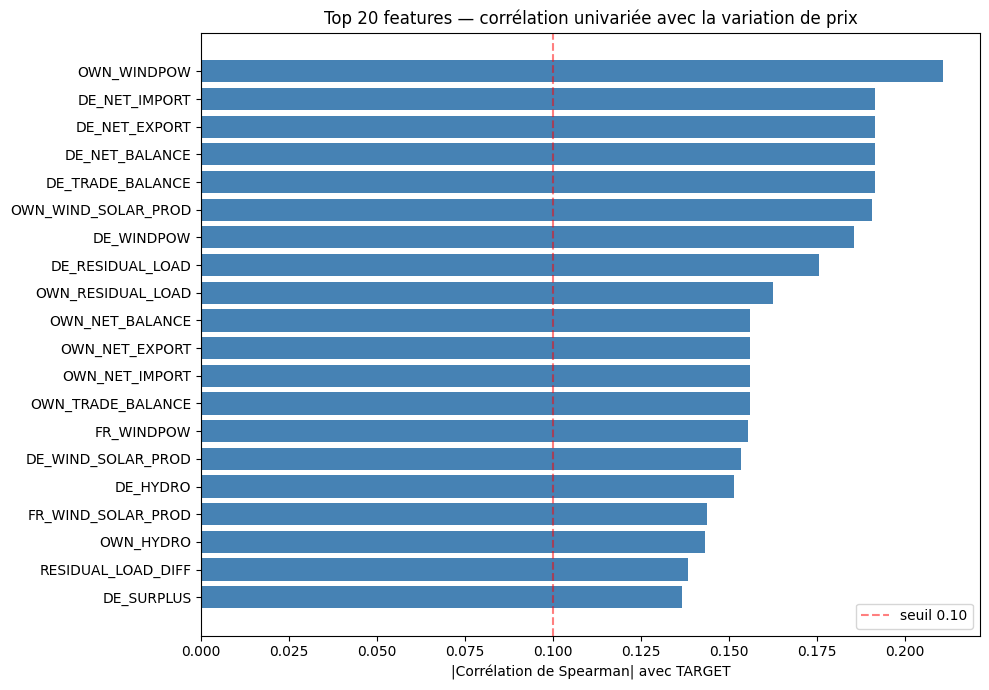

In [34]:
# =============================================================================
# 11.1 — IMPORTANCE DES FEATURES
# =============================================================================
import matplotlib.pyplot as plt

# Spearman univarié (corrélation brute avec TARGET)
spearman_df = pd.DataFrame({
    'feature': list(spearman_scores.keys()),
    'spearman_abs': list(spearman_scores.values())
}).sort_values('spearman_abs', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(spearman_df['feature'][::-1], spearman_df['spearman_abs'][::-1], color='steelblue')
ax.set_xlabel('|Corrélation de Spearman| avec TARGET')
ax.set_title('Top 20 features — corrélation univariée avec la variation de prix')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='seuil 0.10')
ax.legend()
plt.tight_layout()
plt.show()


Nous utilisons le modèle Kernel Ridge mais il s'agit d'une boite noire. Pour intrépréter nos features, nous allons utiliser une ridge sur les mêmes features.

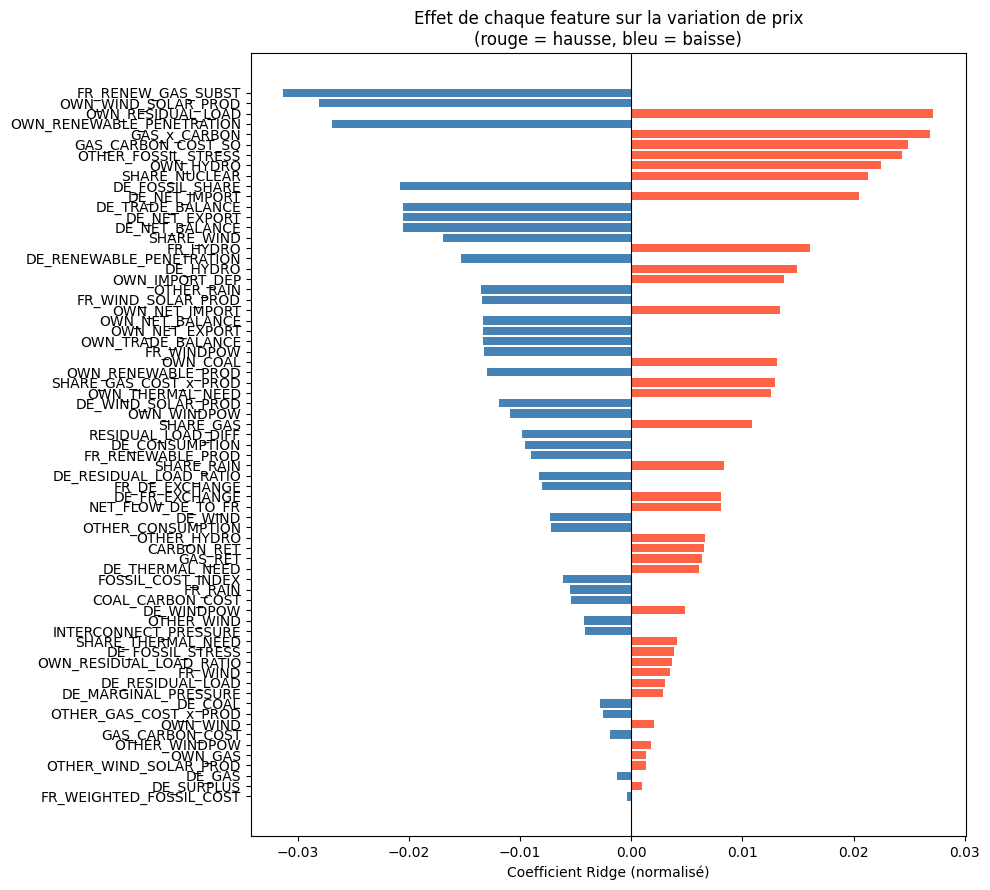

                  feature  coefficient
       FR_RENEW_GAS_SUBST    -0.031297
      OWN_WIND_SOLAR_PROD    -0.028134
        OWN_RESIDUAL_LOAD     0.027179
OWN_RENEWABLE_PENETRATION    -0.026914
             GAS_x_CARBON     0.026866
       GAS_CARBON_COST_SQ     0.024909
      OTHER_FOSSIL_STRESS     0.024318
                OWN_HYDRO     0.022464
            SHARE_NUCLEAR     0.021287
          DE_FOSSIL_SHARE    -0.020792
            DE_NET_IMPORT     0.020495
         DE_TRADE_BALANCE    -0.020495
            DE_NET_EXPORT    -0.020495
           DE_NET_BALANCE    -0.020495
               SHARE_WIND    -0.016969
                 FR_HYDRO     0.016084
 DE_RENEWABLE_PENETRATION    -0.015311
                 DE_HYDRO     0.014943
           OWN_IMPORT_DEP     0.013752
               OTHER_RAIN    -0.013552
       FR_WIND_SOLAR_PROD    -0.013449
           OWN_NET_IMPORT     0.013353
          OWN_NET_BALANCE    -0.013353
           OWN_NET_EXPORT    -0.013353
        OWN_TRADE_BALANCE

In [35]:
# =============================================================================
# 11.2 — COEFFICIENTS RIDGE (proxy interpétable de KernelRidge)
# =============================================================================
from sklearn.linear_model import RidgeCV

ridge_interp = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=10)
ridge_interp.fit(X_norm[selected_no_lag], y_krr)

coef_df = pd.DataFrame({
    'feature': selected_no_lag,
    'coefficient': ridge_interp.coef_
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Ridge (normalisé)')
ax.set_title('Effet de chaque feature sur la variation de prix\n(rouge = hausse, bleu = baisse)')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))


## 11.3) SHAP value pour Kernel Ridge

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelRidge was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/util

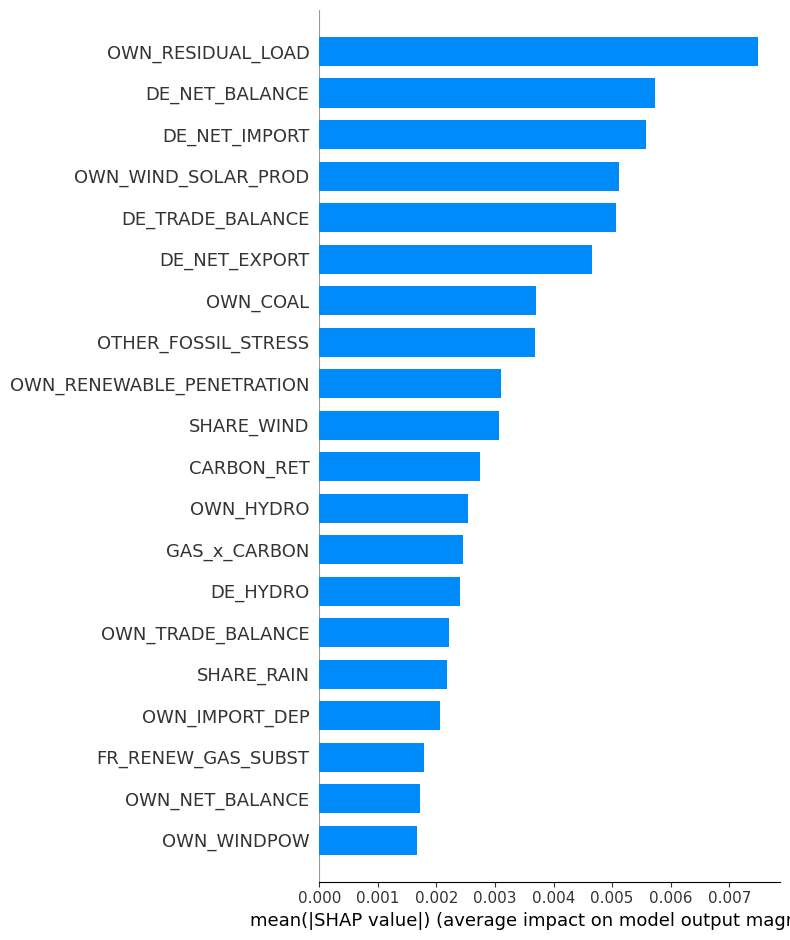

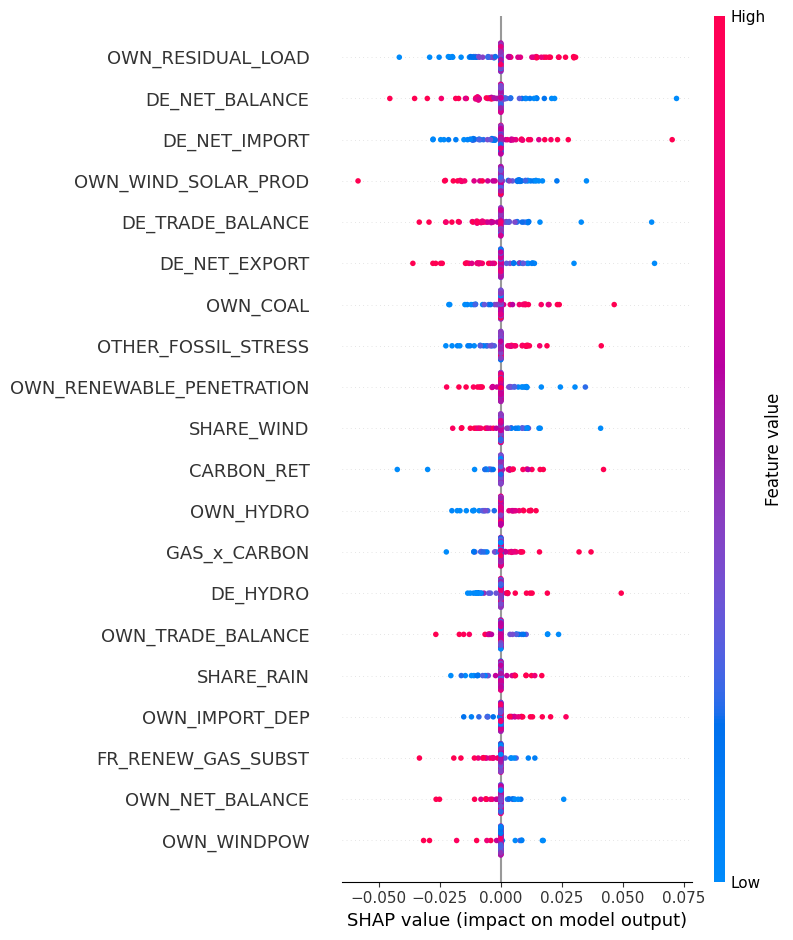

In [36]:
# =============================================================================
# 11.3 — SHAP VALUES (KernelRidge, modèle final)
# =============================================================================
import shap

# Entraîner le modèle final sur tout le train
krr_final = TransformedTargetRegressor(
    regressor=KernelRidge(
        alpha=study_krr_nlag.best_params['alpha'],
        kernel='rbf',
        gamma=study_krr_nlag.best_params['gamma']
    ),
    transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
)
krr_final.fit(X_norm[selected_no_lag], y_krr)

# KernelExplainer (compatible avec KernelRidge)
X_sample = X_norm[selected_no_lag].sample(100, random_state=42)  # subsample pour la vitesse
explainer = shap.KernelExplainer(krr_final.predict, X_sample)
shap_values = explainer.shap_values(X_sample, nsamples=200)

# Summary plot
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True,
                  title='Importance SHAP — KernelRidge')
shap.summary_plot(shap_values, X_sample, show=True,
                  title='Impact directionnel des features (SHAP)')


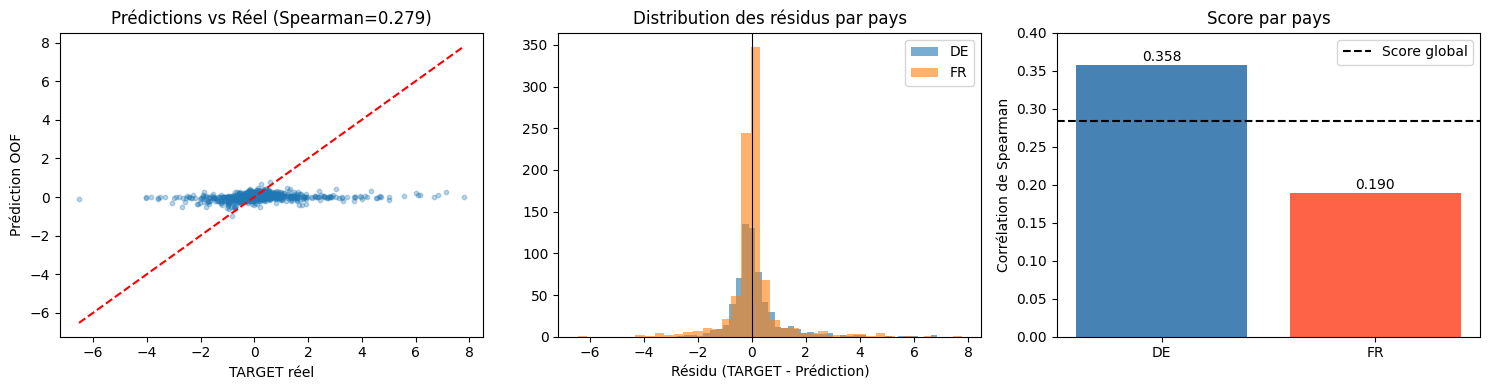

In [37]:
# =============================================================================
# 11.4 — ANALYSE DES RESIDUS
# =============================================================================
# OOF predictions du meilleur modèle
_, oof_krr_final = cv_score_par_pays_oof(
    lambda: TransformedTargetRegressor(
        regressor=KernelRidge(
            alpha=study_krr_nlag.best_params['alpha'],
            kernel='rbf',
            gamma=study_krr_nlag.best_params['gamma']
        ),
        transformer=QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
    ),
    X_krr_nlag, y_krr, groups_krr, 'COUNTRY_DE'
)

residuals = y_krr.values - oof_krr_final
country_flag = x_train_v3.set_index('ID').loc[y_krr.index, 'COUNTRY_DE'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prédictions vs réel
axes[0].scatter(y_krr, oof_krr_final, alpha=0.3, s=10)
axes[0].plot([y_krr.min(), y_krr.max()], [y_krr.min(), y_krr.max()], 'r--')
axes[0].set_xlabel('TARGET réel')
axes[0].set_ylabel('Prédiction OOF')
axes[0].set_title(f'Prédictions vs Réel (Spearman={spearmanr(y_krr, oof_krr_final).correlation:.3f})')

# Résidus par pays
for label, mask in [('DE', country_flag == 1), ('FR', country_flag == 0)]:
    axes[1].hist(residuals[mask], bins=40, alpha=0.6, label=label)
axes[1].set_xlabel('Résidu (TARGET - Prédiction)')
axes[1].set_title('Distribution des résidus par pays')
axes[1].legend()
axes[1].axvline(0, color='black', linewidth=0.8)

# Spearman par pays
for label, mask in [('DE', country_flag == 1), ('FR', country_flag == 0)]:
    rho = spearmanr(y_krr.values[mask], oof_krr_final[mask]).correlation
    axes[2].bar(label, rho, color='steelblue' if label == 'DE' else 'tomato')
    axes[2].text(label, rho + 0.005, f'{rho:.3f}', ha='center')
axes[2].set_ylim(0, 0.4)
axes[2].set_ylabel('Corrélation de Spearman')
axes[2].set_title('Score par pays')
axes[2].axhline(0.2846, color='black', linestyle='--', label='Score global')
axes[2].legend()

plt.tight_layout()
plt.show()


# MLP + BatchNorm

In [33]:
# =========================================================================
# APPROCHE 1 — MLP avec Batch Normalization
# =========================================================================
# Batch Normalization : normalise les sorties de chaque couche
# → stabilise l'apprentissage, réduit l'overfit, accélère la convergence
# → s'applique AVANT l'activation (Dense → BN → ReLU → Dropout)

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation

def build_model_bn(input_dim, hidden_layers):
    """
    MLP avec Batch Normalization.
    
    Différence avec le MLP standard :
    - Standard : Dense(relu) → Dropout
    - Avec BN  : Dense → BatchNorm → ReLU → Dropout
    
    BatchNormalization :
    → normalise les activations (moyenne=0, std=1) à chaque batch
    → évite que certains neurones saturent (valeurs trop grandes/petites)
    → permet un learning rate plus élevé → apprentissage plus rapide
    → dropout réduit à 0.2 car BN régularise déjà
    """
    model = Sequential()
    
    # Couche 1
    model.add(Dense(
        hidden_layers[0],
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(input_dim,)
    ))
    model.add(BatchNormalization())       # normalise avant l'activation
    model.add(Activation('relu'))         # activation après BN
    model.add(Dropout(0.2))              # dropout réduit car BN régularise déjà
    
    # Couches suivantes
    for n_neurons in hidden_layers[1:]:
        model.add(Dense(
            n_neurons,
            kernel_regularizer=regularizers.l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Dropout(0.2))
    
    # Couche de sortie — linear pour régression
    model.add(Dense(1, activation='linear'))
    
    return model


# ── Entraînement et évaluation ────────────────────────────────────────────
print("=" * 50)
print("APPROCHE 1 — MLP avec Batch Normalization")
print("=" * 50)

oof_bn      = np.zeros(len(y))
scores_bn   = []
best_layers = [256, 128, 64, 32]  # meilleure architecture trouvée avant

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    
    model_bn = build_model_bn(X.shape[1], best_layers)
    model_bn.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])
    
    model_bn.fit(
        X_tr, y_tr,
        epochs=200,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    
    preds = model_bn.predict(X_val, verbose=0).flatten()
    oof_bn[val_idx] = preds
    rho = spearmanr(y_val, preds).correlation
    scores_bn.append(rho)
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_oof_bn = spearmanr(y, oof_bn).correlation
print(f"\n  OOF : {rho_oof_bn:.4f} | CV : {np.mean(scores_bn):.4f} ± {np.std(scores_bn):.4f}")
print(f"  Référence MLP standard : 0.2044")


# =========================================================================
# APPROCHE 2 — MLP entraîné sur les rangs
# =========================================================================
# Idée : transformer y en rangs avant l'entraînement
# → aligne directement l'optimisation sur Spearman
# → le réseau apprend à prédire l'ORDRE des observations
#   plutôt que les valeurs brutes
#
# Normalisation des rangs entre 0 et 1 :
# → évite que les grandes valeurs de rangs (ex: 1494) causent
#   des problèmes numériques pendant l'entraînement

from scipy.stats import rankdata

print("\n" + "=" * 50)
print("APPROCHE 2 — MLP entraîné sur les rangs")
print("=" * 50)

# Transformation en rangs normalisés entre 0 et 1
# rankdata : [0.05, -0.12, 0.08] → [3, 1, 2] (rang de chaque valeur)
# normalisation : rang / (n-1) → valeurs entre 0 et 1
y_ranked = rankdata(y).astype("float32")
y_ranked = (y_ranked - y_ranked.min()) / (y_ranked.max() - y_ranked.min())

print(f"y original : min={y.min():.3f} | max={y.max():.3f}")
print(f"y ranked   : min={y_ranked.min():.3f} | max={y_ranked.max():.3f}")

oof_rank    = np.zeros(len(y))
scores_rank = []

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr,      X_val      = X[tr_idx],      X[val_idx]
    y_tr_rank, y_val_rank = y_ranked[tr_idx], y_ranked[val_idx]
    y_val_orig            = y[val_idx]  # pour évaluer le vrai Spearman
    
    # On utilise la meilleure architecture avec BN
    model_rank = build_model_bn(X.shape[1], best_layers)
    model_rank.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])
    
    # Entraînement sur y_ranked au lieu de y
    model_rank.fit(
        X_tr, y_tr_rank,  # ← y en rangs normalisés
        epochs=200,
        batch_size=32,
        validation_data=(X_val, y_val_rank),
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    
    preds = model_rank.predict(X_val, verbose=0).flatten()
    oof_rank[val_idx] = preds
    
    # Spearman calculé sur les valeurs originales (pas les rangs)
    # car Spearman est invariant à la transformation monotone
    rho = spearmanr(y_val_orig, preds).correlation
    scores_rank.append(rho)
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_oof_rank = spearmanr(y, oof_rank).correlation
print(f"\n  OOF : {rho_oof_rank:.4f} | CV : {np.mean(scores_rank):.4f} ± {np.std(scores_rank):.4f}")
print(f"  Référence MLP standard : 0.2044")

# =========================================================================
# APPROCHE 3 — Ensemble Ridge + MLP
# =========================================================================

from sklearn.model_selection import cross_val_predict

# Dans ton notebook main_v5 :
# X_cv = x_train_median.set_index("ID")[feature_cols]
# y_cv = y_train_clean
# groups = x_train_median['DAY_ID'].values
# gkf = GroupKFold(n_splits=5)

ridge_oof = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
preds_ridge_oof = cross_val_predict(
    ridge_oof,
    X_cv[selected_features_perm],  # ← X_cv au lieu de x_train_cv
    y_cv,                           # ← y_cv au lieu de y_train_clean
    cv=list(gkf.split(
        X_cv[selected_features_perm],
        y_cv,
        groups=groups
    ))
)

print(f"Spearman Ridge OOF  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"Spearman MLP BN OOF : {spearmanr(y, oof_bn).correlation:.4f}")

# Test de différentes pondérations
print(f"\n{'alpha':>8} {'Spearman ensemble':>20}")
print("-" * 30)

best_alpha_ens = None
best_rho_ens   = -1

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_ens = alpha * preds_ridge_oof + (1 - alpha) * oof_bn
    rho_ens   = spearmanr(y, preds_ens).correlation
    print(f"  {alpha:>5} | {rho_ens:>8.4f}")
    if rho_ens > best_rho_ens:
        best_rho_ens   = rho_ens
        best_alpha_ens = alpha

print(f"\nMeilleur alpha : {best_alpha_ens} → Spearman : {best_rho_ens:.4f}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Approche':<30} {'OOF Spearman':>12}")
print(f"{'='*55}")
print(f"{'Ridge (référence)':<30} {spearmanr(y, preds_ridge_oof).correlation:>12.4f}")
print(f"{'MLP standard':<30} {'0.2044':>12}")
print(f"{'MLP + BatchNorm':<30} {rho_oof_bn:>12.4f}")
print(f"{'MLP sur rangs':<30} {rho_oof_rank:>12.4f}")
print(f"{'Ensemble Ridge + MLP':<30} {best_rho_ens:>12.4f}")
print(f"{'='*55}")

APPROCHE 1 — MLP avec Batch Normalization
  Fold 1 | Spearman : 0.1835
  Fold 2 | Spearman : 0.1400
  Fold 3 | Spearman : 0.2146
  Fold 4 | Spearman : 0.1133
  Fold 5 | Spearman : 0.2304

  OOF : 0.1817 | CV : 0.1764 ± 0.0441
  Référence MLP standard : 0.2044

APPROCHE 2 — MLP entraîné sur les rangs
y original : min=-6.519 | max=7.787
y ranked   : min=0.000 | max=1.000
  Fold 1 | Spearman : 0.2876
  Fold 2 | Spearman : 0.2185
  Fold 3 | Spearman : 0.2378
  Fold 4 | Spearman : 0.2292
  Fold 5 | Spearman : 0.2628

  OOF : 0.2475 | CV : 0.2472 ± 0.0249
  Référence MLP standard : 0.2044
Spearman Ridge OOF  : 0.2119
Spearman MLP BN OOF : 0.1817

   alpha    Spearman ensemble
------------------------------
    0.1 |   0.1906
    0.2 |   0.1995
    0.3 |   0.2076
    0.4 |   0.2151
    0.5 |   0.2201
    0.6 |   0.2224
    0.7 |   0.2226
    0.8 |   0.2205
    0.9 |   0.2165

Meilleur alpha : 0.7 → Spearman : 0.2226

Approche                       OOF Spearman
Ridge (référence)               

In [35]:
print(f"\n{'alpha':>8} {'Spearman ensemble':>20}")
print("-" * 30)

best_alpha_rank = None
best_rho_rank   = -1

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_ens = alpha * preds_ridge_oof + (1 - alpha) * oof_rank
    rho_ens   = spearmanr(y, preds_ens).correlation
    print(f"  {alpha:>5} | {rho_ens:>8.4f}")
    if rho_ens > best_rho_rank:
        best_rho_rank   = rho_ens
        best_alpha_rank = alpha

print(f"\nMeilleur alpha : {best_alpha_rank} → Spearman : {best_rho_rank:.4f}")
print(f"\nComparaison finale :")
print(f"  MLP sur rangs seul          : {spearmanr(y, oof_rank).correlation:.4f}")
print(f"  Ridge seul                  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"  Ensemble Ridge + MLP rangs  : {best_rho_rank:.4f}")


   alpha    Spearman ensemble
------------------------------
    0.1 |   0.2550
    0.2 |   0.2614
    0.3 |   0.2655
    0.4 |   0.2658
    0.5 |   0.2638
    0.6 |   0.2586
    0.7 |   0.2503
    0.8 |   0.2397
    0.9 |   0.2258

Meilleur alpha : 0.4 → Spearman : 0.2658

Comparaison finale :
  MLP sur rangs seul          : 0.2475
  Ridge seul                  : 0.2119
  Ensemble Ridge + MLP rangs  : 0.2658


In [ ]:
# =========================================================================
# SOUMISSION FINALE — Ensemble Ridge(40%) + MLP sur rangs(60%)
# =========================================================================

# ── Étape 1 : Entraînement Ridge final sur tout le train ─────────────────
ridge_final = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
ridge_final.fit(X_cv[selected_features_perm], y_cv)
print(f"Alpha Ridge sélectionné : {ridge_final.alpha_}")

# ── Étape 2 : Entraînement MLP sur rangs final sur tout le train ─────────
# Transformation en rangs normalisés
y_ranked_full = rankdata(y).astype("float32")
y_ranked_full = (y_ranked_full - y_ranked_full.min()) / (y_ranked_full.max() - y_ranked_full.min())

# On entraîne le MLP sur tout le train (pas de CV ici)
model_rank_final = build_model(X.shape[1], [256, 128, 64, 32])
model_rank_final.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

model_rank_final.fit(
    X, y_ranked_full,
    epochs=200,
    batch_size=32,
    validation_split=0.1,  # 10% pour EarlyStopping
    callbacks=[EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )],
    verbose=0
)
print("MLP sur rangs entraîné !")

# ── Étape 3 : Prédictions sur X_test ─────────────────────────────────────
X_test_final = x_test_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")

# Prédiction Ridge
preds_ridge_test = ridge_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)

# Prédiction MLP sur rangs
preds_mlp_test = model_rank_final.predict(X_test_final, verbose=0).flatten()

# ── Étape 4 : Ensemble ────────────────────────────────────────────────────
best_alpha_rank = 0.4  # Ridge 40%, MLP rangs 60%
preds_ensemble  = best_alpha_rank * preds_ridge_test + (1 - best_alpha_rank) * preds_mlp_test

# ── Étape 5 : Fichier de soumission ──────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": preds_ensemble
})

# Vérifications
assert submission.shape == (654, 2),              f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,    "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\nShape       : {submission.shape}")
print(f"TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ensemble_ridge_mlp_rank.csv", index=False)
print("\nFichier 'submission_ensemble_ridge_mlp_rank.csv' sauvegardé !")

# TEST

In [37]:
# =========================================================================
# OPTIMISATION COMPLÈTE — Ensemble Ridge + MLP rangs + LightGBM
# =========================================================================

from itertools import product
from lightgbm import LGBMRegressor
from scipy.stats import rankdata
from sklearn.model_selection import cross_val_predict
import numpy as np

# -------------------------------------------------------------------------
# ÉTAPE 1 — Tuning des hyperparamètres du MLP sur rangs
# -------------------------------------------------------------------------
# On cherche la meilleure combinaison de :
# - architecture (nombre et taille des couches)
# - dropout (taux d'extinction des neurones)
# - l2 (force de la régularisation)
# - batch_size (taille des batchs)
# - optimizer (algorithme d'optimisation)

print("=" * 60)
print("ÉTAPE 1 — Tuning MLP sur rangs")
print("=" * 60)

def build_model_tunable(input_dim, hidden_layers, dropout, l2):
    """MLP sur rangs avec hyperparamètres configurables."""
    model = Sequential()
    # Couche 1
    model.add(Dense(
        hidden_layers[0],
        kernel_regularizer=regularizers.l2(l2),
        input_shape=(input_dim,)
    ))
    model.add(Activation('relu'))
    model.add(Dropout(dropout))
    # Couches suivantes
    for n in hidden_layers[1:]:
        model.add(Dense(n, kernel_regularizer=regularizers.l2(l2)))
        model.add(Activation('relu'))
        model.add(Dropout(dropout))
    # Sortie
    model.add(Dense(1, activation='linear'))
    return model

# Grille d'hyperparamètres
# Version rapide — seulement les combinaisons les plus prometteuses
param_grid_mlp = {
    'hidden_layers' : [[256, 128, 64, 32], [512, 256, 128, 64]],
    'dropout'       : [0.1, 0.2],
    'l2'            : [0.0001, 0.001],
    'batch_size'    : [32],
    'optimizer'     : ['adam'],
}
# → 8 combinaisons × 5 folds = 40 entraînements seulement

results_tuning = []
total_configs  = (len(param_grid_mlp['hidden_layers']) *
                  len(param_grid_mlp['dropout']) *
                  len(param_grid_mlp['l2']) *
                  len(param_grid_mlp['batch_size']) *
                  len(param_grid_mlp['optimizer']))
print(f"Nombre de configurations à tester : {total_configs}")

for idx, (layers, dropout, l2, batch_size, optimizer) in enumerate(product(
    param_grid_mlp['hidden_layers'],
    param_grid_mlp['dropout'],
    param_grid_mlp['l2'],
    param_grid_mlp['batch_size'],
    param_grid_mlp['optimizer'],
)):
    oof_tuned  = np.zeros(len(y))

    for tr_idx, val_idx in cv_splits:
        X_tr, X_val     = X[tr_idx], X[val_idx]
        y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]
        y_val_orig      = y[val_idx]

        m = build_model_tunable(X.shape[1], layers, dropout, l2)
        m.compile(optimizer=optimizer, loss='mse')
        m.fit(
            X_tr, y_tr_r,
            epochs=200,
            batch_size=batch_size,
            validation_data=(X_val, y_val_r),
            callbacks=[EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            )],
            verbose=0
        )
        preds = m.predict(X_val, verbose=0).flatten()
        oof_tuned[val_idx] = preds

    rho = spearmanr(y, oof_tuned).correlation
    results_tuning.append({
        'layers': layers, 'dropout': dropout, 'l2': l2,
        'batch_size': batch_size, 'optimizer': optimizer,
        'oof': rho
    })
    print(f"  [{idx+1}/{total_configs}] layers={layers} | drop={dropout} | "
          f"l2={l2} | batch={batch_size} | opt={optimizer} → OOF={rho:.4f}")

# Meilleure configuration MLP
best_mlp_config = max(results_tuning, key=lambda x: x['oof'])
print(f"\n✓ Meilleure config MLP : {best_mlp_config}")

# Réentraînement avec la meilleure config pour avoir oof_rank_tuned
oof_rank_tuned = np.zeros(len(y))
for tr_idx, val_idx in cv_splits:
    X_tr, X_val     = X[tr_idx], X[val_idx]
    y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]
    y_val_orig      = y[val_idx]

    m = build_model_tunable(
        X.shape[1],
        best_mlp_config['layers'],
        best_mlp_config['dropout'],
        best_mlp_config['l2']
    )
    m.compile(optimizer=best_mlp_config['optimizer'], loss='mse')
    m.fit(
        X_tr, y_tr_r,
        epochs=200,
        batch_size=best_mlp_config['batch_size'],
        validation_data=(X_val, y_val_r),
        callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                 restore_best_weights=True, verbose=0)],
        verbose=0
    )
    preds = m.predict(X_val, verbose=0).flatten()
    oof_rank_tuned[val_idx] = preds

rho_mlp_tuned = spearmanr(y, oof_rank_tuned).correlation
print(f"  OOF MLP tuné : {rho_mlp_tuned:.4f} (avant : {spearmanr(y, oof_rank).correlation:.4f})")


# -------------------------------------------------------------------------
# ÉTAPE 2 — Ridge sur rangs
# -------------------------------------------------------------------------
# Même idée que MLP sur rangs : entraîner Ridge directement sur les rangs
# → aligne Ridge sur la métrique Spearman

print("\n" + "=" * 60)
print("ÉTAPE 2 — Ridge sur rangs")
print("=" * 60)

y_ranked_ridge = pd.Series(rankdata(y_cv), index=y_cv.index)

ridge_rank_model = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
preds_ridge_rank_oof = cross_val_predict(
    ridge_rank_model,
    X_cv[selected_features_perm],
    y_ranked_ridge,
    cv=list(gkf.split(X_cv[selected_features_perm], y_ranked_ridge, groups=groups))
)

rho_ridge_rank = spearmanr(y, preds_ridge_rank_oof).correlation
print(f"  Ridge sur rangs OOF : {rho_ridge_rank:.4f}")
print(f"  Ridge standard OOF  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")


# -------------------------------------------------------------------------
# ÉTAPE 3 — LightGBM
# -------------------------------------------------------------------------

print("\n" + "=" * 60)
print("ÉTAPE 3 — LightGBM")
print("=" * 60)

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

preds_lgbm_oof = cross_val_predict(
    lgbm,
    X_cv[selected_features_perm],
    y_cv,
    cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups))
)
rho_lgbm = spearmanr(y, preds_lgbm_oof).correlation
print(f"  LightGBM OOF : {rho_lgbm:.4f}")

# LightGBM sur rangs
preds_lgbm_rank_oof = cross_val_predict(
    lgbm,
    X_cv[selected_features_perm],
    y_ranked_ridge,  # rangs comme target
    cv=list(gkf.split(X_cv[selected_features_perm], y_ranked_ridge, groups=groups))
)
rho_lgbm_rank = spearmanr(y, preds_lgbm_rank_oof).correlation
print(f"  LightGBM sur rangs OOF : {rho_lgbm_rank:.4f}")


# -------------------------------------------------------------------------
# ÉTAPE 4 — Recherche du meilleur ensemble
# -------------------------------------------------------------------------
# On teste toutes les combinaisons de poids pour les modèles disponibles :
# Ridge, Ridge rangs, MLP rangs tuné, LightGBM, LightGBM rangs

print("\n" + "=" * 60)
print("ÉTAPE 4 — Recherche du meilleur ensemble")
print("=" * 60)

# Dictionnaire de toutes les prédictions OOF disponibles
all_preds = {
    'Ridge'          : preds_ridge_oof,
    'Ridge rangs'    : preds_ridge_rank_oof,
    'MLP rangs tuné' : oof_rank_tuned,
    'LightGBM'       : preds_lgbm_oof,
    'LightGBM rangs' : preds_lgbm_rank_oof,
}

# Score individuel de chaque modèle
print("\nScores individuels :")
for nom, preds in all_preds.items():
    print(f"  {nom:<20} : {spearmanr(y, preds).correlation:.4f}")

# Recherche du meilleur ensemble à 2 modèles
print("\nRecherche meilleur ensemble à 2 modèles :")
best_2_rho    = -1
best_2_config = None

model_names = list(all_preds.keys())
for i, nom1 in enumerate(model_names):
    for nom2 in model_names[i+1:]:
        for alpha in np.arange(0.1, 1.0, 0.1):
            preds = alpha * all_preds[nom1] + (1 - alpha) * all_preds[nom2]
            rho   = spearmanr(y, preds).correlation
            if rho > best_2_rho:
                best_2_rho    = rho
                best_2_config = (nom1, nom2, round(alpha, 1))

print(f"  Meilleur : {best_2_config[0]}({best_2_config[2]}) + "
      f"{best_2_config[1]}({round(1-best_2_config[2], 1)}) → {best_2_rho:.4f}")

# Recherche du meilleur ensemble à 3 modèles
print("\nRecherche meilleur ensemble à 3 modèles :")
best_3_rho    = -1
best_3_config = None

for i, nom1 in enumerate(model_names):
    for j, nom2 in enumerate(model_names):
        if j <= i:
            continue
        for nom3 in model_names[j+1:]:
            for a in np.arange(0.1, 0.8, 0.1):
                for b in np.arange(0.1, 0.8, 0.1):
                    c = round(1 - a - b, 1)
                    if c < 0.05:
                        continue
                    preds = (a * all_preds[nom1] +
                             b * all_preds[nom2] +
                             c * all_preds[nom3])
                    rho = spearmanr(y, preds).correlation
                    if rho > best_3_rho:
                        best_3_rho    = rho
                        best_3_config = (nom1, nom2, nom3,
                                         round(a, 1), round(b, 1), round(c, 1))

print(f"  Meilleur : {best_3_config[0]}({best_3_config[3]}) + "
      f"{best_3_config[1]}({best_3_config[4]}) + "
      f"{best_3_config[2]}({best_3_config[5]}) → {best_3_rho:.4f}")

# Alpha plus fin autour du meilleur ensemble à 2 modèles
print(f"\nOptimisation fine alpha autour du meilleur ensemble à 2 modèles :")
nom1, nom2, best_alpha_2 = best_2_config
best_fine_rho    = -1
best_fine_alpha  = None

for alpha in np.arange(
    max(0.01, best_alpha_2 - 0.1),
    min(0.99, best_alpha_2 + 0.1),
    0.01
):
    preds = alpha * all_preds[nom1] + (1 - alpha) * all_preds[nom2]
    rho   = spearmanr(y, preds).correlation
    if rho > best_fine_rho:
        best_fine_rho   = rho
        best_fine_alpha = round(alpha, 2)

print(f"  {nom1}({best_fine_alpha}) + {nom2}({round(1-best_fine_alpha, 2)}) → {best_fine_rho:.4f}")


# -------------------------------------------------------------------------
# TABLEAU RÉCAPITULATIF FINAL
# -------------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"{'Approche':<35} {'OOF Spearman':>12}")
print(f"{'='*60}")
for nom, preds in sorted(all_preds.items(), key=lambda x: spearmanr(y, x[1]).correlation, reverse=True):
    print(f"  {nom:<33} {spearmanr(y, preds).correlation:>12.4f}")
print(f"  {'─'*47}")
print(f"  {'Ensemble 2 modèles (fin)':<33} {best_fine_rho:>12.4f}")
print(f"  {'Ensemble 3 modèles':<33} {best_3_rho:>12.4f}")
print(f"  {'Référence (soumission 0.21)':<33} {'0.2100':>12}")
print(f"{'='*60}")

ÉTAPE 1 — Tuning MLP sur rangs
Nombre de configurations à tester : 8
  [1/8] layers=[256, 128, 64, 32] | drop=0.1 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2130
  [2/8] layers=[256, 128, 64, 32] | drop=0.1 | l2=0.001 | batch=32 | opt=adam → OOF=0.2034
  [3/8] layers=[256, 128, 64, 32] | drop=0.2 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2153
  [4/8] layers=[256, 128, 64, 32] | drop=0.2 | l2=0.001 | batch=32 | opt=adam → OOF=0.2280
  [5/8] layers=[512, 256, 128, 64] | drop=0.1 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2118
  [6/8] layers=[512, 256, 128, 64] | drop=0.1 | l2=0.001 | batch=32 | opt=adam → OOF=0.2170
  [7/8] layers=[512, 256, 128, 64] | drop=0.2 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2098
  [8/8] layers=[512, 256, 128, 64] | drop=0.2 | l2=0.001 | batch=32 | opt=adam → OOF=0.2510

✓ Meilleure config MLP : {'layers': [512, 256, 128, 64], 'dropout': 0.2, 'l2': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'oof': 0.2510261620256255}
  OOF MLP tuné : 0.2220 (avant : 0.2475)



In [38]:
# =========================================================================
# BAGGING DU MLP — moyenne de N entraînements pour réduire la variance
# =========================================================================
# Idée : entraîner le même MLP N fois avec des initialisations différentes
# et moyenner les prédictions → réduit la variance aléatoire

N_BAGS = 5  # nombre d'entraînements à moyenner

print("=" * 60)
print(f"BAGGING MLP sur rangs — {N_BAGS} entraînements")
print("=" * 60)

# Meilleure config trouvée pendant le tuning
best_layers   = [512, 256, 128, 64]
best_dropout  = 0.2
best_l2       = 0.001
best_batch    = 32
best_opt      = 'adam'

oof_bagged = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr, X_val     = X[tr_idx], X[val_idx]
    y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]

    # Collecter les prédictions de N modèles différents
    fold_preds = np.zeros((N_BAGS, len(val_idx)))

    for bag in range(N_BAGS):
        # Chaque bag a une initialisation aléatoire différente
        tf.random.set_seed(bag * 42)

        m = build_model_tunable(X.shape[1], best_layers, best_dropout, best_l2)
        m.compile(optimizer=best_opt, loss='mse')
        m.fit(
            X_tr, y_tr_r,
            epochs=200,
            batch_size=best_batch,
            validation_data=(X_val, y_val_r),
            callbacks=[EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            )],
            verbose=0
        )
        fold_preds[bag] = m.predict(X_val, verbose=0).flatten()

    # Moyenne des N prédictions → réduit la variance
    oof_bagged[val_idx] = fold_preds.mean(axis=0)
    rho = spearmanr(y[val_idx], oof_bagged[val_idx]).correlation
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_bagged = spearmanr(y, oof_bagged).correlation
print(f"\n  OOF MLP baggé ({N_BAGS} bags) : {rho_bagged:.4f}")
print(f"  OOF MLP original             : {spearmanr(y, oof_rank).correlation:.4f}")

# ── Nouvel ensemble avec MLP baggé ───────────────────────────────────────
print(f"\nRecherche meilleur alpha avec MLP baggé :")
best_rho_bag  = -1
best_alpha_bag = None

for alpha in np.arange(0.01, 1.0, 0.01):
    preds = alpha * preds_ridge_oof + (1 - alpha) * oof_bagged
    rho   = spearmanr(y, preds).correlation
    if rho > best_rho_bag:
        best_rho_bag   = rho
        best_alpha_bag = round(alpha, 2)

print(f"  Ridge({best_alpha_bag}) + MLP baggé({round(1-best_alpha_bag, 2)}) → {best_rho_bag:.4f}")

# ── Tableau final ─────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Approche':<35} {'OOF':>10}")
print(f"{'='*55}")
print(f"  {'MLP original (non tuné)':<33} {spearmanr(y, oof_rank).correlation:>10.4f}")
print(f"  {'MLP tuné (réentraîné)':<33} {spearmanr(y, oof_rank_tuned).correlation:>10.4f}")
print(f"  {'MLP baggé':<33} {rho_bagged:>10.4f}")
print(f"  {'Ridge seul':<33} {spearmanr(y, preds_ridge_oof).correlation:>10.4f}")
print(f"  {'Ensemble Ridge + MLP original':<33} {'0.2658':>10}")
print(f"  {'Ensemble Ridge + MLP baggé':<33} {best_rho_bag:>10.4f}")
print(f"{'='*55}")

BAGGING MLP sur rangs — 5 entraînements


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1 | Spearman : 0.2522
  Fold 2 | Spearman : 0.2108
  Fold 3 | Spearman : 0.2177
  Fold 4 | Spearman : 0.1523
  Fold 5 | Spearman : 0.3094

  OOF MLP baggé (5 bags) : 0.2314
  OOF MLP original             : 0.2475

Recherche meilleur alpha avec MLP baggé :
  Ridge(0.46) + MLP baggé(0.54) → 0.2570

Approche                                   OOF
  MLP original (non tuné)               0.2475
  MLP tuné (réentraîné)                 0.2220
  MLP baggé                             0.2314
  Ridge seul                            0.2119
  Ensemble Ridge + MLP original         0.2658
  Ensemble Ridge + MLP baggé            0.2570


In [ ]:
# =========================================================================
# SOUMISSION FINALE — Ensemble Ridge(40%) + MLP rangs original(60%)
# =========================================================================

print("Entraînement des modèles finaux sur tout le train...")

# ── Ridge final ───────────────────────────────────────────────────────────
ridge_final = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_final.fit(X_cv[selected_features_perm], y_cv)
print(f"✓ Ridge — alpha : {ridge_final.alpha_:.4f}")

# ── MLP rangs final ───────────────────────────────────────────────────────
# Configuration originale qui donnait 0.2475
# On fait N_BAGS entraînements et on moyenne pour stabiliser
N_BAGS = 10  # plus de bags pour la soumission finale → plus stable

X_test_final  = x_test_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")
mlp_test_preds = np.zeros((N_BAGS, len(X_test_final)))

for bag in range(N_BAGS):
    tf.random.set_seed(bag * 42)

    # Architecture originale [256, 128, 64, 32] avec dropout=0.3
    m = build_model_tunable(X.shape[1], [256, 128, 64, 32], dropout=0.3, l2=0.001)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X, y_ranked,           # tout le train, y en rangs
        epochs=200,
        batch_size=32,
        validation_split=0.1,  # 10% pour EarlyStopping
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    mlp_test_preds[bag] = m.predict(X_test_final, verbose=0).flatten()
    print(f"  Bag {bag+1}/{N_BAGS} ✓")

# Moyenne des N bags → prédiction finale stable
preds_mlp_final = mlp_test_preds.mean(axis=0)
print(f"✓ MLP rangs — {N_BAGS} bags moyennés")

# ── Prédiction Ridge sur test ─────────────────────────────────────────────
preds_ridge_final = ridge_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)

# ── Ensemble final ────────────────────────────────────────────────────────
# Ridge 40% + MLP rangs 60% → meilleur alpha trouvé en OOF
preds_ensemble = 0.4 * preds_ridge_final + 0.6 * preds_mlp_final

# ── Fichier de soumission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": preds_ensemble
})

# Vérifications
assert submission.shape == (654, 2),               f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,     "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\n✓ Shape       : {submission.shape}")
print(f"✓ TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"✓ TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ensemble_final.csv", index=False)
print("\n✓ Fichier 'submission_ensemble_final.csv' sauvegardé — prêt à soumettre !")

# TEST LGBM sur mse

In [39]:
# =========================================================================
# LIGHTGBM — Optimisation avec Optuna
# =========================================================================
# On teste LightGBM avec la loss MSE standard (comme XGBoost)
# et on optimise les hyperparamètres avec Optuna
# Optuna = bibliothèque d'optimisation bayésienne
# → plus efficace qu'une grid search car elle apprend des résultats précédents

import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencieux

def objective_lgbm(trial):
    """
    Fonction objectif pour Optuna.
    Optuna va appeler cette fonction plusieurs fois avec différents
    hyperparamètres et chercher ceux qui maximisent le score Spearman.
    
    trial.suggest_* : Optuna propose une valeur dans la plage donnée
    - suggest_int   : entier entre min et max
    - suggest_float : flottant entre min et max
    - suggest_categorical : choix parmi une liste
    - log=True : échelle logarithmique (utile pour learning_rate, lambda...)
    """
    params = {
        # Nombre d'arbres — plus il y en a, plus le modèle est complexe
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 2000),
        
        # Taux d'apprentissage — plus petit = apprentissage plus lent mais meilleur
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        
        # Nombre max de feuilles par arbre — contrôle la complexité
        # Plus grand = modèle plus complexe → risque d'overfit
        'num_leaves'       : trial.suggest_int('num_leaves', 10, 100),
        
        # Nombre min d'observations par feuille — évite l'overfit
        # Important sur petit dataset !
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        
        # Fraction des observations utilisées par arbre (comme bagging)
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        
        # Fraction des features utilisées par arbre
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # Régularisation L1 — comme Lasso, met des poids à zéro
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        
        # Régularisation L2 — comme Ridge, pénalise les grands poids
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        
        # Profondeur max des arbres (-1 = illimitée)
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        
        # Gain minimum pour faire un split
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
        
        # Paramètres fixes
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }
    
    model = LGBMRegressor(**params)
    
    # Evaluation par CV Spearman avec GroupKFold
    scores = cross_val_score(
        model,
        X_cv[selected_features_perm],
        y_cv,
        cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    
    return np.mean(scores)  # Optuna maximise cette valeur


# ── Lancement de l'optimisation ───────────────────────────────────────────
print("=" * 60)
print("Optimisation LightGBM avec Optuna (MSE loss)")
print("=" * 60)

study_lgbm = optuna.create_study(
    direction='maximize',              # on maximise le Spearman
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE = algorithme bayésien
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=100,        # nombre d'essais — plus = mieux mais plus long
    show_progress_bar=True
)

print(f"\n✓ Meilleur Spearman CV : {study_lgbm.best_value:.4f}")
print(f"✓ Meilleurs paramètres :")
for k, v in study_lgbm.best_params.items():
    print(f"   {k:<25} : {v}")


# ── Evaluation finale du meilleur modèle ─────────────────────────────────
best_lgbm = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# OOF predictions pour comparaison avec les autres modèles
preds_lgbm_optuna_oof = cross_val_predict(
    best_lgbm,
    X_cv[selected_features_perm],
    y_cv,
    cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups))
)

rho_lgbm_optuna = spearmanr(y, preds_lgbm_optuna_oof).correlation
print(f"\n✓ LightGBM Optuna OOF : {rho_lgbm_optuna:.4f}")
print(f"  LightGBM défaut OOF : {spearmanr(y, preds_lgbm_oof).correlation:.4f}")
print(f"  Ridge OOF           : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"  MLP rangs OOF       : {spearmanr(y, oof_rank).correlation:.4f}")


# ── Test ensemble avec LightGBM Optuna ───────────────────────────────────
print(f"\nRecherche meilleur ensemble Ridge + MLP rangs + LightGBM Optuna :")

best_rho_3    = -1
best_config_3 = None

for a in np.arange(0.1, 0.8, 0.05):       # poids Ridge
    for b in np.arange(0.1, 0.8, 0.05):   # poids MLP rangs
        c = round(1 - a - b, 2)            # poids LightGBM
        if c < 0.05 or c > 0.8:
            continue
        preds = (a * preds_ridge_oof +
                 b * oof_rank +
                 c * preds_lgbm_optuna_oof)
        rho = spearmanr(y, preds).correlation
        if rho > best_rho_3:
            best_rho_3    = rho
            best_config_3 = (round(a, 2), round(b, 2), round(c, 2))

print(f"  Ridge({best_config_3[0]}) + MLP rangs({best_config_3[1]}) + "
      f"LightGBM({best_config_3[2]}) → {best_rho_3:.4f}")


# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Approche':<40} {'OOF':>10}")
print(f"{'='*60}")
print(f"  {'Ridge seul':<38} {spearmanr(y, preds_ridge_oof).correlation:>10.4f}")
print(f"  {'MLP rangs seul':<38} {spearmanr(y, oof_rank).correlation:>10.4f}")
print(f"  {'LightGBM défaut':<38} {spearmanr(y, preds_lgbm_oof).correlation:>10.4f}")
print(f"  {'LightGBM Optuna':<38} {rho_lgbm_optuna:>10.4f}")
print(f"  {'─'*50}")
print(f"  {'Ensemble Ridge + MLP rangs':<38} {'0.2658':>10}")
print(f"  {'Ensemble Ridge + MLP + LightGBM Optuna':<38} {best_rho_3:>10.4f}")
print(f"{'='*60}")

Optimisation LightGBM avec Optuna (MSE loss)


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Meilleur Spearman CV : 0.2121
✓ Meilleurs paramètres :
   n_estimators              : 1413
   learning_rate             : 0.014864509547329922
   num_leaves                : 96
   min_child_samples         : 10
   subsample                 : 0.7656929438445732
   colsample_bytree          : 0.5737093693735424
   reg_alpha                 : 1.6176317639080922
   reg_lambda                : 0.006892242171063264
   max_depth                 : 9
   min_split_gain            : 0.08788903318652393

✓ LightGBM Optuna OOF : 0.2131
  LightGBM défaut OOF : 0.1636
  Ridge OOF           : 0.2119
  MLP rangs OOF       : 0.2475

Recherche meilleur ensemble Ridge + MLP rangs + LightGBM Optuna :
  Ridge(0.25) + MLP rangs(0.6) + LightGBM(0.15) → 0.2710

Approche                                        OOF
  Ridge seul                                 0.2119
  MLP rangs seul                             0.2475
  LightGBM défaut                            0.1636
  LightGBM Optuna                         

In [40]:
# =========================================================================
# SOUMISSION FINALE — Ensemble Ridge(25%) + MLP rangs(60%) + LightGBM(15%)
# =========================================================================

print("Entraînement des modèles finaux sur tout le train...")

X_test_final = x_test_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")

# ── Ridge final ───────────────────────────────────────────────────────────
ridge_final = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_final.fit(X_cv[selected_features_perm], y_cv)
preds_ridge_test = ridge_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)
print(f"✓ Ridge — alpha : {ridge_final.alpha_:.4f}")

# ── MLP rangs final — 10 bags pour stabiliser ─────────────────────────────
N_BAGS = 10
mlp_test_preds = np.zeros((N_BAGS, len(X_test_final)))

for bag in range(N_BAGS):
    tf.random.set_seed(bag * 42)
    m = build_model_tunable(X.shape[1], [256, 128, 64, 32], dropout=0.3, l2=0.001)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X, y_ranked,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    mlp_test_preds[bag] = m.predict(X_test_final, verbose=0).flatten()
    print(f"  MLP Bag {bag+1}/{N_BAGS} ✓")

preds_mlp_test = mlp_test_preds.mean(axis=0)
print(f"✓ MLP rangs — {N_BAGS} bags moyennés")

# ── LightGBM Optuna final ─────────────────────────────────────────────────
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgbm_final.fit(X_cv[selected_features_perm], y_cv)
preds_lgbm_test = lgbm_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)
print(f"✓ LightGBM Optuna entraîné")

# ── Ensemble final ────────────────────────────────────────────────────────
# Ridge 25% + MLP rangs 60% + LightGBM 15%
preds_ensemble = (0.25 * preds_ridge_test +
                  0.60 * preds_mlp_test   +
                  0.15 * preds_lgbm_test)

# ── Fichier de soumission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": preds_ensemble
})

# Vérifications
assert submission.shape == (654, 2),               f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,     "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\n✓ Shape       : {submission.shape}")
print(f"✓ TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"✓ TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ensemble_3modeles.csv", index=False)
print("\n✓ Fichier 'submission_ensemble_3modeles.csv' sauvegardé !")


Entraînement des modèles finaux sur tout le train...
✓ Ridge — alpha : 10000.0000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  MLP Bag 1/10 ✓
  MLP Bag 2/10 ✓
  MLP Bag 3/10 ✓
  MLP Bag 4/10 ✓
  MLP Bag 5/10 ✓
  MLP Bag 6/10 ✓
  MLP Bag 7/10 ✓
  MLP Bag 8/10 ✓
  MLP Bag 9/10 ✓
  MLP Bag 10/10 ✓
✓ MLP rangs — 10 bags moyennés
✓ LightGBM Optuna entraîné

✓ Shape       : (654, 2)
✓ TARGET mean : 0.3456
✓ TARGET std  : 0.1354
     ID    TARGET
0  1115  0.333171
1  1202  0.373903
2  1194  0.143900
3  1084  0.472920
4  1135  0.293193
5   960  0.407918
6  1131  0.346243
7   996  0.342019
8  1085  0.487402
9  1063  0.339704

✓ Fichier 'submission_ensemble_3modeles.csv' sauvegardé !

Historique des soumissions :
  Benchmark challenge          : 0.1586
  Ridge simple                 : 0.1952
  Ridge + saisonnalité         : 0.2100
  Ensemble Ridge + MLP rangs   : à soumettre (OOF 0.2658)
  Ensemble 3 modèles           : à soumettre (OOF 0.2710)
